# Mapping San Diego’s Housing Affordability Crisis

**MATH 189 Project**  
**Team:** Hannah Gonzalez, Uzair Gheewala, Terry Su, Dylan Craver, Chentao Gong

## Abstract

San Diego is widely viewed as an in-demand place to live because of its climate, coastline, vibrant communities, and strong labor market, but these amenities coincide with a severe housing affordability problem. Many households face rent levels that outpace income growth, and the resulting cost burden affects financial stability, mobility, and access to opportunity. At the same time, affordability is not determined by a single factor. It reflects the interaction between housing demand, the pace and location of new supply, the distribution of affordable housing inventory, the movement of projects through permitting pipelines, and the diversion of housing stock into other uses such as short-term rentals.

This project develops a neighborhood-level analysis of San Diego’s housing affordability crisis. Our central objective is to identify **affordability mismatch hotspots**: areas where affordability need is high while supply-side signals are weak, delayed, or diverted. To do this, we combine multiple public datasets that describe both housing need and housing supply, harmonize them to a common geographic unit, and construct an interpretable **Affordability–Pipeline Mismatch Index**. We then use exploratory spatial analysis, summary statistics, and interpretable regression models to study which neighborhoods appear most misaligned and which observable housing supply signals are most associated with affordability pressure.

## 1. Introduction and Research Motivation

### Conceptual Framework

Our analysis separates the housing affordability problem into two linked components:

**Need / affordability pressure**
- How much financial burden households face in the rental market
- How large the gap is between rent and income
- Which neighborhoods appear most stressed

**Supply / pipeline / diversion**
- Existing affordable housing stock
- Future supply signaled by development and permitting activity
- Affordable housing pipeline bottlenecks
- Incremental supply such as ADUs
- Diversion of housing stock into short-term rental use

The central idea of the project is that affordability is worst where need is high and supply-side relief is limited or delayed.

### Research Questions

1. Which neighborhoods in San Diego exhibit the highest affordability pressure?
2. How is affordable housing inventory distributed across neighborhoods?
3. Which supply-side indicators are strongest or weakest in areas of high need?
4. Where do affordability mismatch hotspots appear when we compare need and supply directly?
5. Which observable housing supply indicators are most associated with affordability burden?

In [121]:
# Imports
import os
import json
import math
import time
from typing import Dict, List, Optional, Tuple

from io import BytesIO
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import geopandas as gpd
from shapely.geometry import shape, Point
from shapely import wkt

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams["figure.figsize"] = (8, 8)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

## 2. Common Geography

### Why a Common Geography Is Needed

The datasets used in this project come in very different forms. Some are point-based spatial datasets, some are ZIP-level tables, some are tract-level Census tables, and some are dashboards or permit records that must be aggregated before analysis. In order to compare them meaningfully, we need a single shared geographic framework.

### Choice of Neighborhood Unit

We use **ZIP Code Tabulation Areas (ZCTAs)** as the primary neighborhood unit for the core analysis. ZCTAs are Census-defined polygon approximations of ZIP codes. They are not identical to USPS ZIP codes, but they are close enough for neighborhood-scale analysis and are especially useful because they come with public boundary files that can be merged with both Census data and ZIP-coded administrative data.

In [ ]:
ACS_YEAR = 2024

# TIGER URLs
COUNTY_URL = f"https://www2.census.gov/geo/tiger/TIGER{ACS_YEAR}/COUNTY/tl_{ACS_YEAR}_us_county.zip"
ZCTA_URL   = f"https://www2.census.gov/geo/tiger/TIGER{ACS_YEAR}/ZCTA520/tl_{ACS_YEAR}_us_zcta520.zip"
TRACT_URL  = f"https://www2.census.gov/geo/tiger/TIGER{ACS_YEAR}/TRACT/tl_{ACS_YEAR}_06_tract.zip"

# San Diego County FIPS
CA_STATEFP = "06"
SD_COUNTYFP = "073"

In [ ]:
def load_or_build_gdf(filepath, build_func):
    if os.path.exists(filepath):
        return gpd.read_file(filepath)
    else:
        gdf = build_func()
        gdf.to_file(filepath, driver="GeoJSON")
        return gdf

def build_sd_county_gdf():
    counties = gpd.read_file(COUNTY_URL).to_crs("EPSG:4326")

    sd_county_gdf = counties[
        (counties["STATEFP"] == CA_STATEFP) &
        (counties["COUNTYFP"] == SD_COUNTYFP)
    ].copy()

    sd_county_gdf = sd_county_gdf[["STATEFP", "COUNTYFP", "NAME", "GEOID", "geometry"]]
    sd_county_gdf = sd_county_gdf.rename(columns={"NAME": "county_name"})

    return sd_county_gdf

def build_sd_tract_gdf():
    tracts = gpd.read_file(TRACT_URL).to_crs("EPSG:4326")
    sd_tract_gdf = tracts[tracts["COUNTYFP"] == SD_COUNTYFP].copy()
    sd_tract_gdf["GEOID"] = sd_tract_gdf["GEOID"].astype("string")
    return sd_tract_gdf

def build_sd_zcta_gdf():
    zctas = gpd.read_file(ZCTA_URL).to_crs("EPSG:4326")

    county_gdf = load_or_build_gdf("data/sd_county_gdf.geojson", build_sd_county_gdf)

    # keep only ZIPs intersecting SD
    sd_zcta_gdf = gpd.overlay(zctas, county_gdf[["geometry"]], how="intersection")

    zip_id_col = [c for c in sd_zcta_gdf.columns if "ZCTA" in c.upper()][0]
    sd_zcta_gdf = sd_zcta_gdf[[zip_id_col, "geometry"]].copy()
    sd_zcta_gdf = sd_zcta_gdf.rename(columns={zip_id_col: "zip"})
    sd_zcta_gdf["zip"] = sd_zcta_gdf["zip"].astype("string")

    return sd_zcta_gdf

def build_city_community_gdf():
    COMMUNITY_PLAN_URL = (
        "https://webmaps.sandiego.gov/arcgis/rest/services/"
        "Planning/PLN_LongRangePlanning/MapServer/24/query"
    )
    community_plan_params = {
        "where": "1=1",
        "outFields": "plan_name,plan_desc,area_name,GP_LU_DESC",
        "returnGeometry": "true",
        "f": "geojson"
    }

    city_community_gdf = gpd.read_file(
        COMMUNITY_PLAN_URL + "?" + "&".join([f"{k}={v}" for k, v in community_plan_params.items()])
    ).to_crs("EPSG:4326")

    city_community_gdf.columns = [c.lower() for c in city_community_gdf.columns]

    name_col = "plan_name" if "plan_name" in city_community_gdf.columns else "area_name"

    city_community_gdf["geometry"] = city_community_gdf.geometry.make_valid().buffer(0)

    city_community_named_gdf = (
        city_community_gdf
        .dropna(subset=[name_col])
        .dissolve(by=name_col, as_index=False)
    )

    city_community_named_gdf = city_community_named_gdf.rename(columns={name_col: "community_name"})
    city_community_named_gdf["community_name"] = city_community_named_gdf["community_name"].astype("string")

    # Gen X/Y coordinates for labels for geojson
    repr_points = city_community_named_gdf.representative_point()
    city_community_named_gdf["label_x"] = repr_points.x
    city_community_named_gdf["label_y"] = repr_points.y

    return city_community_named_gdf

def build_sd_zcta_named_gdf():
    sd_zcta_gdf = load_or_build_gdf("data/sd_zcta_gdf.geojson", build_sd_zcta_gdf)
    community_polys = load_or_build_gdf("data/city_community_named_gdf.geojson", build_city_community_gdf)

    zip_community_overlay = gpd.overlay(
        sd_zcta_gdf[["zip", "geometry"]],
        community_polys[["community_name", "geometry"]],
        how="intersection"
    )

    zip_community_overlay = zip_community_overlay.to_crs("EPSG:3857")
    zip_community_overlay["overlap_area"] = zip_community_overlay.area

    # Dominant community per ZIP = largest overlap
    zip_to_community = (
        zip_community_overlay
        .sort_values(["zip", "overlap_area"], ascending=[True, False])
        .drop_duplicates(subset=["zip"])
        [["zip", "community_name", "overlap_area"]]
        .reset_index(drop=True)
    )

    sd_zcta_named_gdf = sd_zcta_gdf.merge(zip_to_community, on="zip", how="left")
    return sd_zcta_named_gdf

In [ ]:
sd_county_gdf = load_or_build_gdf("data/sd_county_gdf.geojson", build_sd_county_gdf)
sd_tract_gdf = load_or_build_gdf("data/sd_tract_gdf.geojson", build_sd_tract_gdf)
city_community_named_gdf = load_or_build_gdf("data/city_community_named_gdf.geojson", build_city_community_gdf)
sd_zcta_named_gdf = load_or_build_gdf("data/sd_zcta_named_gdf.geojson", build_sd_zcta_named_gdf)

print(f"\nLoaded {len(sd_zcta_named_gdf)} final ZCTA entries.")


Loaded 116 final ZCTA entries.


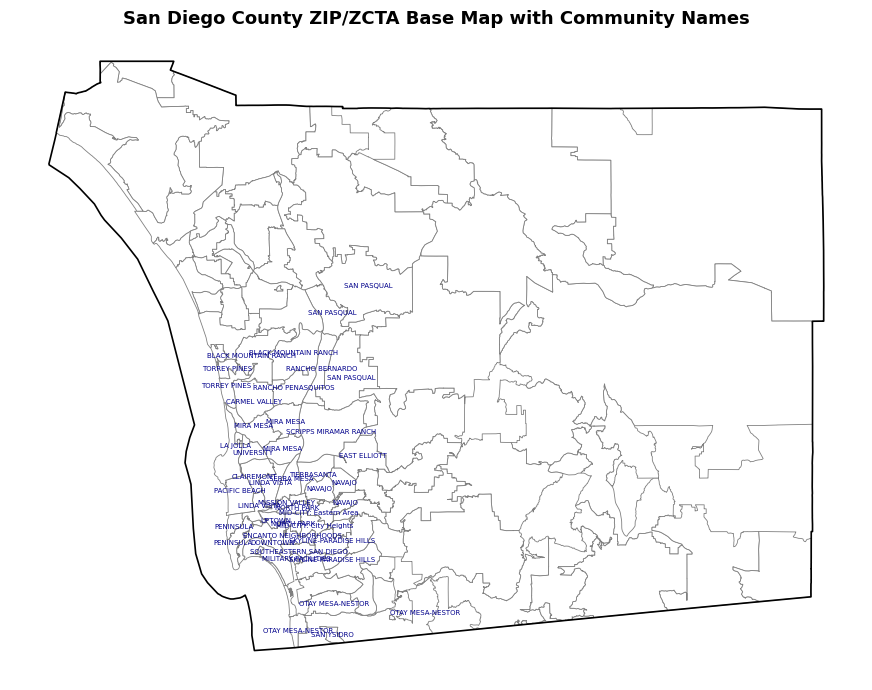

In [ ]:
fig, ax = plt.subplots(figsize=(11, 11))

sd_zcta_named_gdf.to_crs("EPSG:4326").plot(
    ax=ax,
    facecolor="white",
    edgecolor="gray",
    linewidth=0.6
)

sd_county_gdf.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2
)

# Overlay the community names
for _, row in sd_zcta_named_gdf.to_crs("EPSG:4326").iterrows():
    if pd.notna(row["community_name"]):
        pt = row.geometry.representative_point()
        ax.text(
            pt.x, pt.y,
            str(row["community_name"]),
            fontsize=5,
            ha="center",
            va="center",
            color="darkblue",
            wrap=True
        )

ax.set_title("San Diego County ZIP/ZCTA Base Map with Community Names")
ax.set_axis_off()
plt.show()

In [ ]:
def ensure_wgs84(points_gdf):
    return points_gdf.to_crs("EPSG:4326")

def standardize_zip_series(s):
    return s.astype("string").str.strip().str[:5]


def spatial_join_points_to_zip(points_gdf,
                               zip_gdf = None,
                               zip_col = "zip"):
    if zip_gdf is None:
        zip_gdf = sd_zcta_named_gdf

    points_gdf = ensure_wgs84(points_gdf)
    zip_gdf = ensure_wgs84(zip_gdf)

    joined = gpd.sjoin(
        points_gdf,
        zip_gdf[[zip_col, "community_name", "geometry"]],
        how="left",
        predicate="within"
    )
    return joined

def plot_zip_choropleth(gdf, column, title,
                        figsize=(9, 9), edgecolor="black", linewidth=0.3):

    ax = gdf.to_crs("EPSG:4326").plot(
        column=column,
        figsize=figsize,
        legend=True,
        edgecolor=edgecolor,
        linewidth=linewidth,
        missing_kwds={"color": "lightgrey"}
    )
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

## 3. Data Inventory

To keep the analysis organized, we divide data sources into two broad categories:

- **Supply-side datasets**: indicators of existing housing stock, future supply, project pipeline movement, and housing diversion
- **Demand / need datasets**: indicators of affordability pressure, rent burden, and household-level stress in the rental market


| Dataset | Category | Raw Form | Planned Geography | Role in Project |
|---|---|---|---|---|
| SDHC Affordable Housing Inventory | Supply baseline | Tabular property-level records | ZIP | Existing affordable housing supply |
| County-Funded Affordable Housing Inventory | Supply baseline | Point layer | ZIP via spatial join | County-backed affordable housing developments |
| Development Permits | Supply pipeline | Administrative records / spatial data | ZIP | General future housing supply |
| Affordable Housing Permitting Dashboard | Supply pipeline | Dashboard / project records | ZIP | Affordable housing pipeline bottlenecks |
| STRO Licenses | Diversion | Administrative records | ZIP | Housing stock diverted to short-term rental use |
| ADU Data | Incremental supply | Dashboard / tabular records | ZIP | Small-scale incremental housing supply |
| ACS B25070 / B25071 | Demand / need | Census tabular estimates | ZIP | Rent burden and rent-to-income affordability pressure |
| ACS demographic controls | Demand / controls | Census tabular estimates | ZIP | Income, renter share, housing context |

## 4. Supply-Side Data Management

### 4.1 Affordable Housing Inventory

#### 4.1.1 Dataset Description

The **County-Restricted Affordable Housing Inventory** is a hosted GIS feature layer that contains point locations of affordable housing developments that received County funding. The layer is a county-restricted inventory of affordable housing developments, updated on a quarterly basis, and reports 82 records in the 2024 release. Each record corresponds to a development rather than an individual housing unit.

The **SDHC affordable housing dashboard** provides a broader city-focused inventory of affordable housing properties. The dashboard includes property-specific information and a map searchable by ZIP Code for affordable housing throughout the City of San Diego.

#### 4.1.2 Prior Uses and Existing Analyses

The County-Restricted Affordable Housing Inventory is already distributed as a formal GIS product with documentation describing it as a point inventory of regional affordable housing developments that received County funding, along with field definitions and update cadence.

The broader San Diego Housing Commission affordable housing inventory is likewise used as a public-facing planning and housing-access tool.

#### 4.1.3 Data Collection

We load two affordable housing inventory sources:

1. **County-funded inventory**: downloaded from the official ArcGIS Feature Service as a GeoJSON point layer.
2. **SDHC inventory export**: manually exported from the public dashboard as a CSV file.

In [ ]:
FEATURESERVER_LAYER0 = "https://geo.sandag.org/server/rest/services/Hosted/Affordable_Housing_Inventory/FeatureServer/0"

def http_get_json(url, params):
    r = requests.get(url, params=params)
    r.raise_for_status()
    return r.json()

layer_meta = http_get_json(FEATURESERVER_LAYER0, params={"f": "pjson"})
layer_meta_keys = ["name", "geometryType", "objectIdField", "fields", "extent", "maxRecordCount"]
#print({k: layer_meta.get(k) for k in layer_meta_keys if k in layer_meta})

fields = pd.DataFrame(layer_meta["fields"])
#fields[["name", "type", "alias"]].head(30)

In [ ]:
QUERY_URL = FEATURESERVER_LAYER0 + "/query"

def fetch_all_features_geojson(where="1=1", out_fields="*", batch_size=2000):
    count_params = {
        "where": where,
        "returnCountOnly": "true",
        "f": "pjson"
    }
    count_resp = http_get_json(QUERY_URL, params=count_params)
    total = int(count_resp["count"])
    #print("Total features:", total)

    all_features = []
    for offset in range(0, total, batch_size):
        params = {
            "where": where,
            "outFields": out_fields,
            "returnGeometry": "true",
            "f": "geojson",
            "resultOffset": offset,
            "resultRecordCount": batch_size
        }
        gj = http_get_json(QUERY_URL, params=params)
        feats = gj.get("features", [])
        all_features.extend(feats)
        #print(f"Fetched {len(feats)} features (offset={offset})")
        time.sleep(0.1)

    return {
        "type": "FeatureCollection",
        "features": all_features
    }

inventory_gj = fetch_all_features_geojson()
#len(inventory_gj["features"])

In [ ]:
def geojson_to_gdf(gj, crs="EPSG:4326"):
    rows = []
    geoms = []
    for f in gj["features"]:
        rows.append(f.get("properties", {}))
        geoms.append(shape(f["geometry"]) if f.get("geometry") else None)
    df = pd.DataFrame(rows)
    gdf = gpd.GeoDataFrame(df, geometry=geoms, crs=crs)
    return gdf

inv_gdf = geojson_to_gdf(inventory_gj)

inv_gdf = inv_gdf[~inv_gdf.geometry.isna()].copy()
inv_gdf.columns = [c.strip().lower() for c in inv_gdf.columns]

#print(inv_gdf.shape, inv_gdf.columns)
#inv_gdf.head()
#inv_gdf.info()
# missing = inv_gdf.isna().mean().sort_values(ascending=False)
# missing.head(20)
#display(inv_gdf['status'].value_counts(dropna=False).head(20))

inv_gdf.to_file("affordable_housing_inventory.geojson", driver="GeoJSON")

county_funded_inventory_gdf = inv_gdf.copy()

In [ ]:
sdhc_raw = pd.read_csv("data/sdhc_affordable_inventory.csv")

sdhc_raw.columns = (
    sdhc_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(":", "")
)

print("County-funded inventory shape:", county_funded_inventory_gdf.shape)
print("SDHC raw export shape:", sdhc_raw.shape)

#sdhc_raw.isna().sum().sort_values(ascending=False)

display(county_funded_inventory_gdf.head())
display(sdhc_raw.head())

County-funded inventory shape: (82, 22)
SDHC raw export shape: (818, 12)


,zip,unit_types,ami_chart,website2_pbv,address,data_as_of,ces_text,city,website_text,occupants_served,...,name,phone_number,state,total_units,photo_url,pbv_text,community_website,objectid,status,geometry
0,92069,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,604 Richmar Ave,1730332800000,None,San Marcos,Webpage (non-County site),Individuals/families,...,Alora,760-273-1050,CA,100,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://www.affirmedhousing.com/completed/alora/,1,Existing,POINT (-117.17329 33.1466)
1,91901,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,1460-1464 Marshall Rd,1730332800000,None,Alpine,None,Individuals/families,...,Alpine Family Apartments,619-612-7550,CA,38,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,,2,Existing,POINT (-116.76661 32.83362)
2,92111,Studio - 3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,2645 Ulric St.,1730332800000,None,San Diego,Webpage (non-County site),"Individuals/families, Veterans, Transition Age...",...,Amanecer,619-816-2922,CA,96,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://chworks.org/property/amanecer/,3,Existing,POINT (-117.1721 32.79169)
3,92021,1-2 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,1012 N Anza St,1730332800000,None,El Cajon,None,Seniors 55+,...,Anza Terrace,619-440-5921,CA,26,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,,4,Existing,POINT (-116.94825 32.80892)
4,91911,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,748-760 Anita Street,1730332800000,Developments that include units for persons ex...,Chula Vista,Webpage (non-County site),"Individuals/families, Supportive Housing",...,Casa Anita,619-830-3820,CA,96,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://www.wakelandhdc.com/casa-anita.html,5,Existing,POINT (-117.08606 32.59883)


,address_postal_code,community_plan,district,inclusionary_count,most_restrictive_ami_range,number_of_affordable_units,property_name,sdhc_owned,sro,state_assembly_district,state_senate_district,count_of_data_export_summary_2.csv
0,NaN,DOWNTOWN,3.0,0,0%-0%,0,Paul Mirabile Center,no,no,78.0,39.0,1
1,NaN,NaN,NaN,0,35%-50%,10,Becky's House III,no,no,NaN,NaN,1
2,NaN,NAVAJO,7.0,1,30%-60%,79,Bluewater,no,no,79.0,39.0,1
3,NaN,OTAY MESA-NESTOR,8.0,0,80%-80%,1,1250 Twining Avenue,no,no,80.0,40.0,1
4,NaN,OTAY MESA-NESTOR,8.0,0,80%-80%,1,1506 Peterlynn Dr,no,no,80.0,40.0,1


#### 4.1.4 Cleaning and Preprocessing

Matching the dfs to the CRs for visualization on the maps, standardizing zip codes, column name renaming and standardization

In [ ]:
# ensure CRS
county_funded_inventory_gdf = county_funded_inventory_gdf.to_crs("EPSG:4326")

# standardize zip and numeric unit counts
county_funded_inventory_gdf["zip"] = standardize_zip_series(county_funded_inventory_gdf["zip"])
county_funded_inventory_gdf["total_units"] = pd.to_numeric(
    county_funded_inventory_gdf["total_units"], errors="coerce"
)

county_funded_inventory_gdf["status"] = county_funded_inventory_gdf["status"].astype("string").str.strip()

county_funded_inventory_gdf["source"] = "county_funded"

In [ ]:
sdhc_df = sdhc_raw.copy()

sdhc_df = sdhc_df.rename(columns={
    "address_postal_code": "zip",
    "community_plan": "community",
    "district": "council_district",
    "number_of_affordable_units": "affordable_units",
    "most_restrictive_ami_range": "ami_range"
})

sdhc_df["zip"] = standardize_zip_series(sdhc_df["zip"])

for col in ["affordable_units", "inclusionary_count", "council_district",
            "state_assembly_district", "state_senate_district"]:
    sdhc_df[col] = pd.to_numeric(sdhc_df[col], errors="coerce")

sdhc_df["community"] = sdhc_df["community"].astype("string").str.strip().str.upper()

for col in ["sdhc_owned", "sro", "property_name", "ami_range"]:
    if col in sdhc_df.columns:
        sdhc_df[col] = sdhc_df[col].astype("string").str.strip()

sdhc_df["source"] = "sdhc_dashboard"

In [ ]:
print("County-funded missing ZIPs:", county_funded_inventory_gdf["zip"].isna().sum())
print("SDHC missing ZIPs:", sdhc_df["zip"].isna().sum())

print("\nCounty-funded missing total_units:", county_funded_inventory_gdf["total_units"].isna().sum())
print("SDHC missing affordable_units:", sdhc_df["affordable_units"].isna().sum())

display(county_funded_inventory_gdf.head())
display(sdhc_df.head())

County-funded missing ZIPs: 0
SDHC missing ZIPs: 5

County-funded missing total_units: 0
SDHC missing affordable_units: 0


,zip,unit_types,ami_chart,website2_pbv,address,data_as_of,ces_text,city,website_text,occupants_served,...,phone_number,state,total_units,photo_url,pbv_text,community_website,objectid,status,geometry,source
0,92069,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,604 Richmar Ave,1730332800000,None,San Marcos,Webpage (non-County site),Individuals/families,...,760-273-1050,CA,100,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://www.affirmedhousing.com/completed/alora/,1,Existing,POINT (-117.17329 33.1466),county_funded
1,91901,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,1460-1464 Marshall Rd,1730332800000,None,Alpine,None,Individuals/families,...,619-612-7550,CA,38,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,,2,Existing,POINT (-116.76661 32.83362),county_funded
2,92111,Studio - 3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,2645 Ulric St.,1730332800000,None,San Diego,Webpage (non-County site),"Individuals/families, Veterans, Transition Age...",...,619-816-2922,CA,96,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://chworks.org/property/amanecer/,3,Existing,POINT (-117.1721 32.79169),county_funded
3,92021,1-2 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,1012 N Anza St,1730332800000,None,El Cajon,None,Seniors 55+,...,619-440-5921,CA,26,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,,4,Existing,POINT (-116.94825 32.80892),county_funded
4,91911,1-3 BR,https://sdcounty.maps.arcgis.com/sharing/rest/...,,748-760 Anita Street,1730332800000,Developments that include units for persons ex...,Chula Vista,Webpage (non-County site),"Individuals/families, Supportive Housing",...,619-830-3820,CA,96,https://sdcounty.maps.arcgis.com/sharing/rest/...,None,https://www.wakelandhdc.com/casa-anita.html,5,Existing,POINT (-117.08606 32.59883),county_funded


,zip,community,council_district,inclusionary_count,ami_range,affordable_units,property_name,sdhc_owned,sro,state_assembly_district,state_senate_district,count_of_data_export_summary_2.csv,source
0,<NA>,DOWNTOWN,3.0,0,0%-0%,0,Paul Mirabile Center,no,no,78.0,39.0,1,sdhc_dashboard
1,<NA>,<NA>,NaN,0,35%-50%,10,Becky's House III,no,no,NaN,NaN,1,sdhc_dashboard
2,<NA>,NAVAJO,7.0,1,30%-60%,79,Bluewater,no,no,79.0,39.0,1,sdhc_dashboard
3,<NA>,OTAY MESA-NESTOR,8.0,0,80%-80%,1,1250 Twining Avenue,no,no,80.0,40.0,1,sdhc_dashboard
4,<NA>,OTAY MESA-NESTOR,8.0,0,80%-80%,1,1506 Peterlynn Dr,no,no,80.0,40.0,1,sdhc_dashboard


#### 4.1.5 Neighborhood Aggregation

Our project’s main analysis geography is ZIP/ZCTA. We therefore aggregate both affordable housing inventories to the ZIP level.

For the county-funded inventory, we use the point geometry and assign each development to a ZIP polygon through a spatial join. For the SDHC inventory, we rely on the ZIP code field in the exported tabular data. These two ZIP-level summaries are then merged into a combined inventory table that preserves source-specific counts and unit totals.

In [ ]:
county_zip = spatial_join_points_to_zip(
    county_funded_inventory_gdf,
    zip_gdf=sd_zcta_named_gdf,
    zip_col="zip"
)

#county_zip.head()

In [ ]:
county_zip["zip"] = county_zip["zip_right"].astype("string")

county_zip["total_units"] = pd.to_numeric(county_zip["total_units"], errors="coerce")

county_zip_summary = (
    county_zip.dropna(subset=["zip"])
    .groupby("zip")
    .agg(
        county_projects=("name", "count"),
        county_units=("total_units", "sum")
    )
    .reset_index()
)

county_status = (
    county_zip.dropna(subset=["zip"])
    .pivot_table(
        index="zip",
        columns="status",
        values="name",
        aggfunc="count",
        fill_value=0
    )
    .reset_index()
)

county_status.columns = [
    "zip" if c == "zip" else f"county_status_{str(c).strip().lower().replace(' ', '_')}"
    for c in county_status.columns
]

county_zip_summary = county_zip_summary.merge(county_status, on="zip", how="left")

#county_zip_summary.head()

In [ ]:
sdhc_zip_summary = (
    sdhc_df.dropna(subset=["zip"])
    .groupby("zip")
    .agg(
        sdhc_properties=("property_name", "count"),
        sdhc_units=("affordable_units", "sum"),
        inclusionary_units=("inclusionary_count", "sum"),
        sdhc_owned_properties=("sdhc_owned", lambda x: (x.astype(str).str.lower() == "yes").sum()),
        sro_properties=("sro", lambda x: (x.astype(str).str.lower() == "yes").sum())
    )
    .reset_index()
)

#sdhc_zip_summary.head()

In [ ]:
inventory_zip = sdhc_zip_summary.merge(
    county_zip_summary,
    on="zip",
    how="outer"
)

# fill numeric columns only
num_cols = inventory_zip.select_dtypes(include=[np.number]).columns
inventory_zip[num_cols] = inventory_zip[num_cols].fillna(0)

inventory_zip["zip"] = inventory_zip["zip"].astype("string")

inventory_zip.head()

,zip,sdhc_properties,sdhc_units,inclusionary_units,sdhc_owned_properties,sro_properties,county_projects,county_units,county_status_existing,county_status_under_construction
0,0,4.0,25.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,91901,0.0,0.0,0.0,0.0,0.0,1.0,38.0,1.0,0.0
2,91911,0.0,0.0,0.0,0.0,0.0,1.0,96.0,1.0,0.0
3,91950,0.0,0.0,0.0,0.0,0.0,2.0,99.0,0.0,2.0
4,91977,0.0,0.0,0.0,0.0,0.0,6.0,516.0,6.0,0.0


In [ ]:
inventory_map_gdf = sd_zcta_named_gdf.merge(
    inventory_zip,
    on="zip",
    how="left"
)

num_cols = inventory_map_gdf.select_dtypes(include=[np.number]).columns
inventory_map_gdf[num_cols] = inventory_map_gdf[num_cols].fillna(0)
inventory_map_gdf.to_file("data/affordable_housing_inventory_agg_gdf.geojson", driver="GeoJSON")
inventory_map_gdf.head()

,zip,community_name,overlap_area,geometry,sdhc_properties,sdhc_units,inclusionary_units,sdhc_owned_properties,sro_properties,county_projects,county_units,county_status_existing,county_status_under_construction,combined_affordable_units_exploratory
0,92140,None,0.000000e+00,"POLYGON ((-117.2094 32.74251, -117.20925 32.74...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,92093,None,0.000000e+00,"POLYGON ((-117.24389 32.87956, -117.24388 32.8...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,92161,None,0.000000e+00,"POLYGON ((-117.23426 32.87331, -117.23423 32.8...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,92154,OTAY MESA-NESTOR,1.093848e+06,"POLYGON ((-117.11888 32.53954, -117.11886 32.5...",57.0,1795.0,6.0,35.0,0.0,2.0,116.0,2.0,0.0,1911.0
4,91942,NAVAJO,1.992777e+02,"POLYGON ((-117.05347 32.7572, -117.05344 32.75...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### 4.1.6 Exploratory Data Analysis


In [ ]:
inventory_scope_summary = pd.DataFrame({
    "dataset": [
        "County-funded affordable inventory",
        "SDHC affordable inventory export"
    ],
    "records": [
        len(county_funded_inventory_gdf),
        len(sdhc_df)
    ],
    "geographic scope": [
        "County-funded developments across San Diego County region",
        "Affordable housing properties in the City of San Diego"
    ],
    "raw unit": [
        "Development / point record",
        "Property / tabular record"
    ]
})

inventory_scope_summary

,dataset,records,geographic scope,raw unit
0,County-funded affordable inventory,82,County-funded developments across San Diego Co...,Development / point record
1,SDHC affordable inventory export,818,Affordable housing properties in the City of S...,Property / tabular record


In [ ]:
inventory_zip["combined_affordable_units_exploratory"] = (
    inventory_zip["sdhc_units"] + inventory_zip["county_units"]
)

inventory_zip.sort_values("combined_affordable_units_exploratory", ascending=False).head(15)

,zip,sdhc_properties,sdhc_units,inclusionary_units,sdhc_owned_properties,sro_properties,county_projects,county_units,county_status_existing,county_status_under_construction,combined_affordable_units_exploratory
22,92101,111.0,6202.0,16.0,1.0,41.0,2.0,390.0,1.0,1.0,6592.0
33,92113,46.0,2654.0,9.0,4.0,1.0,1.0,52.0,1.0,0.0,2706.0
26,92105,58.0,2397.0,6.0,23.0,3.0,3.0,203.0,2.0,1.0,2600.0
52,92173,31.0,2146.0,9.0,6.0,3.0,3.0,304.0,2.0,1.0,2450.0
51,92154,57.0,1795.0,6.0,35.0,0.0,2.0,116.0,2.0,0.0,1911.0
32,92111,36.0,1386.0,6.0,10.0,0.0,2.0,223.0,2.0,0.0,1609.0
45,92127,9.0,881.0,2.0,0.0,0.0,3.0,528.0,2.0,1.0,1409.0
35,92115,53.0,1361.0,6.0,13.0,0.0,1.0,41.0,0.0,1.0,1402.0
24,92103,63.0,1166.0,10.0,3.0,7.0,1.0,163.0,0.0,1.0,1329.0
48,92130,17.0,968.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,968.0


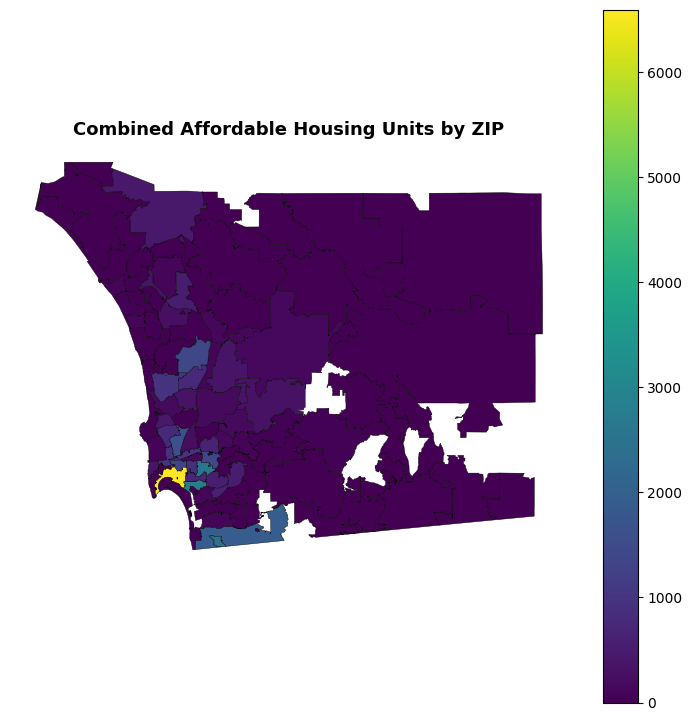

In [ ]:
inventory_map_gdf["combined_affordable_units_exploratory"] = (
    inventory_map_gdf["sdhc_units"] + inventory_map_gdf["county_units"]
)

plot_zip_choropleth(
    inventory_map_gdf,
    column="combined_affordable_units_exploratory",
    title="Combined Affordable Housing Units by ZIP"
)

#### 4.1.7 Dataset Takeaways

The county-funded inventory is much smaller and should be interpreted as a restricted subset of developments that received County support, while the SDHC inventory captures a broader set of affordable housing properties within the City of San Diego.

A key limitation is that the two sources are not perfectly comparable in geography or scope. The SDHC source is city-focused, while the county-funded inventory extends beyond the City of San Diego but covers only a subset of affordable developments. As a result, any exploratory combined measure should be treated cautiously and used primarily for descriptive visualization rather than as a final production estimate.

### 4.2 Development Permits Dataset


#### 4.2.1 Dataset Description

SOURCE: https://data.sandiego.gov/datasets/development-permits-set2/

This combined dataset contains development permits issued by the City of San
Diego's Development Services Department, sourced from the city's cloud-based
permitting system (records begin 2018; legacy data predates that). Each row
represents a single permit approval linked to a parent project, and covers
activities such as new construction, additions, remodeling, and electrical,
mechanical, or plumbing system work. The two source files distinguish active
(in-progress or recently issued) permits from closed (completed or expired)
ones, which were merged into a single dataframe with a 'permit_status_category'
label column. Key fields include spatial coordinates, approval dates, project
valuation, permit type, processing priority, and affordability-tier breakdowns
for new dwelling units (DU) and accessory dwelling units (ADU/JADU).

Column Descriptions

| Column | Description |
|--------|-------------|
| `PROJECT_ID` | Unique ID for the parent project (one project → one or more approvals) |
| `JOB_ID` | Internal job identifier (often null in active records) |
| `APPROVAL_ID` | Unique permit/approval ID (e.g. PMT-3248638) |
| `PROJECT_TITLE` | Short human-readable title for the project |
| `PROJECT_SCOPE` | General description of the project's scope of work |
| `APPROVAL_SCOPE` | Specific scope description for this individual approval |
| `APPROVAL_TYPE` | Type of approval (e.g. Building Permit, Electrical Pmt, ADU) |
| `PROJECT_PROCESSING_CODE` | Project-level priority: Standard, Expedite, or Express |
| `APPROVAL_PROCESSING_CODE` | Approval-level priority: Standard, Expedite, or Express |
| `APPROVAL_STATUS` | Current status: Created, Issued, Completed, Closed, Cancelled, etc. |
| `JOB_BC_CODE` | Building code classification code |
| `JOB_BC_CODE_DESCRIPTION` | Human-readable description of the building code classification |
| `APPROVAL_PERMIT_HOLDER` | Name of the individual or company the permit is issued to |
| `ADDRESS_JOB` | Street address of the job site |
| `JOB_APN` | Assessor's Parcel Number — unique ID for a land parcel |
| `LAT_JOB` | Latitude of the primary job site location |
| `LNG_JOB` | Longitude of the primary job site location |
| `DATE_PROJECT_CREATE` | Date the parent project was created in the tracking system |
| `DATE_PROJECT_COMPLETE` | Legal date when submittal requirements were deemed complete |
| `DATE_APPROVAL_CREATE` | Date this approval/permit was added to the system |
| `DATE_APPROVAL_ISSUE` | Date the city granted permission to proceed |
| `DATE_APPROVAL_CLOSE` | Date the permit was closed (final inspection or expiry). Null = still active |
| `DATE_APPROVAL_EXPIRE` | Scheduled expiry date of the permit |
| `APPROVAL_VALUATION` | Estimated dollar value of the permitted work |
| `APPROVAL_STORIES` | Number of stories in the structure (where applicable) |
| `APPROVAL_FLOOR_AREA` | Total floor area in square feet (where applicable) |
| `APPROVAL_DU_EXTREMELY_LOW` | New dwelling units for households at <30% Area Median Income (AMI) |
| `APPROVAL_DU_VERY_LOW` | New dwelling units for households at 30–50% AMI |
| `APPROVAL_DU_LOW` | New dwelling units for households at 50–80% AMI |
| `APPROVAL_DU_MODERATE` | New dwelling units for households at 80–120% AMI |
| `APPROVAL_DU_ABOVE_MODERATE` | New dwelling units for households at >120% AMI |
| `APPROVAL_DU_BONUS` | Bonus dwelling units (density bonus law) |
| `APPROVAL_DU_FUTURE_DEMO` | Dwelling units flagged for future demolition |
| `APPROVAL_ADU_EXTREMELY_LOW` | ADU units at <30% AMI |
| `APPROVAL_ADU_VERY_LOW` | ADU units at 30–50% AMI |
| `APPROVAL_ADU_LOW` | ADU units at 50–80% AMI |
| `APPROVAL_ADU_MODERATE` | ADU units at 80–120% AMI |
| `APPROVAL_ADU_ABOVE_MODERATE` | ADU units at >120% AMI |
| `APPROVAL_ADU_BONUS` | Bonus ADU units |
| `APPROVAL_ADU_TOTAL` | Total ADU units across all affordability tiers |
| `APPROVAL_JADU_EXTREMELY_LOW` | Junior ADU units at <30% AMI |
| `APPROVAL_JADU_VERY_LOW` | Junior ADU units at 30–50% AMI |
| `APPROVAL_JADU_LOW` | Junior ADU units at 50–80% AMI |
| `APPROVAL_JADU_MODERATE` | Junior ADU units at 80–120% AMI |
| `APPROVAL_JADU_ABOVE_MODERATE` | Junior ADU units at >120% AMI |
| `APPROVAL_JADU_BONUS` | Bonus Junior ADU units |
| `APPROVAL_JADU_TOTAL` | Total Junior ADU units across all affordability tiers |


#### 4.2.2 Prior Uses and Existing Analyses

The City of San Diego already uses its permit records in multiple public analytical products.

https://www.sandiego.gov/development-services/records/permit-activity-reports

The Permit Activity Reports page on the City’s Open Data Portal describes the data as approvals for permits, maps, agreements, and other applications processed by the Development Services Department.

https://www.sandiego.gov/development-services/permits-inspections/dashboard

The City also publishes a Permitting Center Dashboard, which provides an overview of Development Services permit data, inspections, and code enforcement.

#### 4.2.3 Data Collection

In [ ]:
# active development permits df
active_dev = pd.read_csv('https://seshat.datasd.org/development_permits_set2/permits_set2_active_datasd.csv')
#active_dev.head()

# closed development permits df
closed_dev = pd.read_csv('https://seshat.datasd.org/development_permits_set2/permits_set2_closed_datasd.csv')
#closed_dev.head()

# Inspection of Shape, DTypes, Missing Values
print("Shape:", active_dev.shape)
print("\nDtypes:\n", active_dev.dtypes)
print("\nMissing values (%):\n",
      (active_dev.isnull().mean() * 100).round(2).sort_values(ascending=False))

print("Shape:", closed_dev.shape)
print("\nDtypes:\n", closed_dev.dtypes)
print("\nMissing values (%):\n",
      (closed_dev.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (257692, 47)

Dtypes:
 PROJECT_ID                       object
JOB_ID                           object
APPROVAL_ID                      object
PROJECT_TITLE                    object
PROJECT_SCOPE                    object
APPROVAL_SCOPE                   object
APPROVAL_TYPE                    object
PROJECT_PROCESSING_CODE          object
APPROVAL_PROCESSING_CODE         object
APPROVAL_STATUS                  object
JOB_BC_CODE                     float64
JOB_BC_CODE_DESCRIPTION          object
APPROVAL_PERMIT_HOLDER           object
ADDRESS_JOB                      object
JOB_APN                          object
LAT_JOB                         float64
LNG_JOB                         float64
DATE_PROJECT_CREATE              object
DATE_PROJECT_COMPLETE            object
DATE_APPROVAL_CREATE             object
DATE_APPROVAL_ISSUE              object
DATE_APPROVAL_CLOSE             float64
DATE_APPROVAL_EXPIRE             object
APPROVAL_VALUATION              float64
APPROVAL_S

#### 4.2.4 Cleaning and Preprocessing




In [ ]:
# Merging to 1 Dataset

# Active / Closed Category
active_dev['permit_status_category'] = 'Active'
closed_dev['permit_status_category'] = 'Closed'

dev_df = pd.concat([active_dev, closed_dev], ignore_index=True)
print(f"\nCombined shape: {dev_df.shape[0]:,} rows × {dev_df.shape[1]} columns")


Combined shape: 390,242 rows × 48 columns


In [ ]:
# full data cleaning

#standardizing
dev_df.columns = dev_df.columns.str.strip().str.upper()

# date columns
date_cols = [
    'DATE_PROJECT_CREATE', 'DATE_PROJECT_COMPLETE',
    'DATE_APPROVAL_CREATE', 'DATE_APPROVAL_ISSUE',
    'DATE_APPROVAL_CLOSE',  'DATE_APPROVAL_EXPIRE',
]
for col in date_cols:
    if col in dev_df.columns:
        dev_df[col] = pd.to_datetime(dev_df[col], errors='coerce')

print("\nDate columns parsed:")
for col in date_cols:
    if col in dev_df.columns:
        nulls = dev_df[col].isna().sum()
        print(f"  {col:<30} nulls: {nulls:,}")

# getting useful date features
dev_df['issue_year']  = dev_df['DATE_APPROVAL_ISSUE'].dt.year
dev_df['issue_month'] = dev_df['DATE_APPROVAL_ISSUE'].dt.month
dev_df['issue_quarter'] = dev_df['DATE_APPROVAL_ISSUE'].dt.to_period('Q').astype(str)

# days from creation to issuance (approval lead time)
dev_df['days_to_issue'] = (
    dev_df['DATE_APPROVAL_ISSUE'] - dev_df['DATE_APPROVAL_CREATE']
).dt.days

# days permit was open (issue → close); NaN for still-active permits
dev_df['days_open'] = (
    dev_df['DATE_APPROVAL_CLOSE'] - dev_df['DATE_APPROVAL_ISSUE']
).dt.days

print("\nDerived columns added: issue_year, issue_month, issue_quarter, "
      "days_to_issue, days_open")

# cleaned numeric columns
numeric_cols = [
    'APPROVAL_VALUATION', 'APPROVAL_STORIES', 'APPROVAL_FLOOR_AREA',
    'APPROVAL_ADU_TOTAL', 'APPROVAL_JADU_TOTAL',
    'APPROVAL_DU_EXTREMELY_LOW', 'APPROVAL_DU_VERY_LOW',
    'APPROVAL_DU_LOW', 'APPROVAL_DU_MODERATE', 'APPROVAL_DU_ABOVE_MODERATE',
]
for col in numeric_cols:
    if col in dev_df.columns:
        dev_df[col] = pd.to_numeric(dev_df[col], errors='coerce')

# strip whitespace from string columns
for col in dev_df.select_dtypes('object').columns:
    dev_df[col] = dev_df[col].str.strip()

# standardize APPROVAL_STATUS casing
if 'APPROVAL_STATUS' in dev_df.columns:
    dev_df['APPROVAL_STATUS'] = dev_df['APPROVAL_STATUS'].str.title()

# extract ZIP code from address
if 'ADDRESS_JOB' in dev_df.columns:
    dev_df['zip_code'] = dev_df['ADDRESS_JOB'].str.extract(r'(\d{5})(?:-\d{4})?$')

# remove obvious geo outliers
# San Diego bounding box: lat 32.5–33.2, lng -117.4 – -116.7
if 'LAT_JOB' in dev_df.columns and 'LNG_JOB' in dev_df.columns:
    geo_mask = (
        dev_df['LAT_JOB'].between(32.5, 33.2) &
        dev_df['LNG_JOB'].between(-117.4, -116.7)
    )
    removed = (~geo_mask & dev_df['LAT_JOB'].notna()).sum()
    print(f"\nGeo outliers removed: {removed:,}")
    dev_df = dev_df[geo_mask | dev_df['LAT_JOB'].isna()].reset_index(drop=True)



Date columns parsed:
  DATE_PROJECT_CREATE            nulls: 219,666
  DATE_PROJECT_COMPLETE          nulls: 226,622
  DATE_APPROVAL_CREATE           nulls: 0
  DATE_APPROVAL_ISSUE            nulls: 66,929
  DATE_APPROVAL_CLOSE            nulls: 257,692
  DATE_APPROVAL_EXPIRE           nulls: 184,812

Derived columns added: issue_year, issue_month, issue_quarter, days_to_issue, days_open

Geo outliers removed: 18


In [ ]:
# missing values summary
print("\nMISSING VALUE SUMMARY (columns with any nulls)")
print("─" * 50)
missing = dev_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(dev_df) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
print(missing_df.to_string())

# summary descriptive stats
print("\n\nDESCRIPTIVE STATISTICS — Numeric Columns")
print("─" * 50)
print(dev_df[numeric_cols].describe().round(2).to_string())


MISSING VALUE SUMMARY (columns with any nulls)
──────────────────────────────────────────────────
                              Missing  Pct (%)
APPROVAL_DU_FUTURE_DEMO        386260     99.0
APPROVAL_FLOOR_AREA            376589     96.5
APPROVAL_STORIES               374526     96.0
APPROVAL_ADU_TOTAL             362477     92.9
APPROVAL_JADU_TOTAL            362477     92.9
APPROVAL_JADU_MODERATE         362457     92.9
APPROVAL_JADU_ABOVE_MODERATE   362457     92.9
APPROVAL_ADU_ABOVE_MODERATE    362457     92.9
APPROVAL_ADU_BONUS             362457     92.9
APPROVAL_ADU_LOW               362457     92.9
APPROVAL_ADU_VERY_LOW          362457     92.9
APPROVAL_ADU_EXTREMELY_LOW     362457     92.9
APPROVAL_ADU_MODERATE          362457     92.9
APPROVAL_JADU_EXTREMELY_LOW    362457     92.9
APPROVAL_JADU_VERY_LOW         362457     92.9
APPROVAL_JADU_LOW              362457     92.9
APPROVAL_JADU_BONUS            362457     92.9
APPROVAL_VALUATION             360833     92.5
APPROVAL

#### 4.2.5 Neighborhood Aggregation

In [ ]:
# 1. Volume features
permit_volume = (
    dev_df.dropna(subset=["zip_code"])
    .groupby("zip_code")
    .agg(
        permit_total_count        = ("APPROVAL_ID",            "count"),
        permit_active_count       = ("PERMIT_STATUS_CATEGORY", lambda x: (x == "Active").sum()),
        permit_closed_count       = ("PERMIT_STATUS_CATEGORY", lambda x: (x == "Closed").sum()),
        permit_avg_valuation      = ("APPROVAL_VALUATION",     "mean"),
        permit_median_valuation   = ("APPROVAL_VALUATION",     "median"),
        permit_total_valuation    = ("APPROVAL_VALUATION",     "sum"),
    )
    .reset_index()
)

# 2. Approval-type breakdown (pivot)
permit_type_pivot = (
    dev_df.dropna(subset=["zip_code"])
    .pivot_table(
        index   = "zip_code",
        columns = "APPROVAL_TYPE",
        values  = "APPROVAL_ID",
        aggfunc = "count",
        fill_value = 0
    )
    .reset_index()
)
permit_type_pivot.columns = [
    "zip_code" if c == "zip_code"
    else f"permit_type_{str(c).strip().lower().replace(' ', '_').replace('-', '_')}"
    for c in permit_type_pivot.columns
]

# 3. Approval length / processing speed features
permit_timing = (
    dev_df.dropna(subset=["zip_code"])
    .groupby("zip_code")
    .agg(
        avg_days_to_issue    = ("days_to_issue", "mean"),
        median_days_to_issue = ("days_to_issue", "median"),
        avg_days_open        = ("days_open",     "mean"),
        median_days_open     = ("days_open",     "median"),
        pct_expedited        = ("APPROVAL_PROCESSING_CODE",
                                lambda x: (x.str.lower().isin(["expedite","express"])).mean()),
    )
    .reset_index()
)

# 4. Affordable housing unit features
du_cols   = [c for c in dev_df.columns if c.startswith("APPROVAL_DU_")]
adu_cols  = [c for c in dev_df.columns if c.startswith("APPROVAL_ADU_")]
jadu_cols = [c for c in dev_df.columns if c.startswith("APPROVAL_JADU_")]

permit_housing = (
    dev_df.dropna(subset=["zip_code"])
    .groupby("zip_code")
    [[*du_cols, *adu_cols, *jadu_cols]]
    .sum()
    .reset_index()
)
permit_housing.columns = [
    "zip_code" if c == "zip_code"
    else c.lower()
    for c in permit_housing.columns
]

# 5. Merge all permit feature blocks together
permit_zip_summary = (
    permit_volume
    .merge(permit_timing,     on="zip_code", how="left")
    .merge(permit_housing,    on="zip_code", how="left")
    .merge(permit_type_pivot, on="zip_code", how="left")
)

# 6. Standardize zip key to string (matches your project convention)
permit_zip_summary["zip"] = permit_zip_summary["zip_code"].astype("string")
permit_zip_summary = permit_zip_summary.drop(columns=["zip_code"])

# Fill numeric NaNs
num_cols = permit_zip_summary.select_dtypes(include=[np.number]).columns
permit_zip_summary[num_cols] = permit_zip_summary[num_cols].fillna(0)

# 7. Drop low-variance permit type columns (>90% zeros across zips)
type_cols = [c for c in permit_zip_summary.columns if c.startswith("permit_type_")]
low_variance = [c for c in type_cols if (permit_zip_summary[c] == 0).mean() > 0.90]
permit_zip_summary = permit_zip_summary.drop(columns=low_variance)
print(f"Dropped {len(low_variance)} low-variance permit type columns")

# 8. Consolidate duplicate permit type columns caused by inconsistent raw naming
dupe_pairs = [
    ("permit_type_approval___construction___electrical_pmt___pv_combo",
     "permit_type_approval___construction___electrical_pmt_pv_combo"),
    ("permit_type_site__development_permit",
     "permit_type_site_development_permit"),
    ("permit_type_street__tree_permit",
     "permit_type_street_tree_permit"),
]

for col_a, col_b in dupe_pairs:
    if col_a in permit_zip_summary.columns and col_b in permit_zip_summary.columns:
        permit_zip_summary[col_b] = permit_zip_summary[col_a] + permit_zip_summary[col_b]
        permit_zip_summary = permit_zip_summary.drop(columns=[col_a])

print(f"Columns after deduplication: {permit_zip_summary.shape[1]}")

permit_zip_summary = permit_zip_summary.rename(columns={
    "permit_type_street__tree_permit": "permit_type_street_tree_permit"
})

# 9. Filter out known junk zip codes AND out-of-area zips
junk_zips = {"0", "12345"}
permit_zip_summary = permit_zip_summary[~permit_zip_summary["zip"].isin(junk_zips)]

sd_zcta_named_gdf = load_or_build_gdf("data/sd_zcta_named_gdf.geojson", build_sd_zcta_named_gdf)
valid_sd_zips = set(sd_zcta_named_gdf["zip"].unique())

# Sanity check
print(f"Zips remaining: {permit_zip_summary['zip'].nunique()}")
print(f"Columns remaining: {permit_zip_summary.shape[1]}")
print(permit_zip_summary.columns.tolist())

permit_map_gdf = sd_zcta_named_gdf.merge(permit_zip_summary, on="zip", how="left")
permit_map_gdf.to_file('data/dev_permits_summary.geojson', driver='GeoJSON')

permit_map_gdf.head()

Dropped 21 low-variance permit type columns
Columns after deduplication: 89
Zips remaining: 84
Columns remaining: 89
['permit_total_count', 'permit_active_count', 'permit_closed_count', 'permit_avg_valuation', 'permit_median_valuation', 'permit_total_valuation', 'avg_days_to_issue', 'median_days_to_issue', 'avg_days_open', 'median_days_open', 'pct_expedited', 'approval_du_extremely_low', 'approval_du_very_low', 'approval_du_low', 'approval_du_moderate', 'approval_du_above_moderate', 'approval_du_bonus', 'approval_du_future_demo', 'approval_adu_extremely_low', 'approval_adu_very_low', 'approval_adu_low', 'approval_adu_moderate', 'approval_adu_above_moderate', 'approval_adu_bonus', 'approval_adu_total', 'approval_jadu_extremely_low', 'approval_jadu_very_low', 'approval_jadu_low', 'approval_jadu_moderate', 'approval_jadu_above_moderate', 'approval_jadu_bonus', 'approval_jadu_total', 'permit_type_alternate_methods_and_materials', 'permit_type_approval___construction___demolition_pmt', 'per

,zip,community_name,overlap_area,geometry,permit_total_count,permit_active_count,permit_closed_count,permit_avg_valuation,permit_median_valuation,permit_total_valuation,...,permit_type_street_tree_permit,permit_type_street_address_change,permit_type_substantial_conformance_review,permit_type_temporary_use_pmt,permit_type_tentative___map,permit_type_traffic_control_permit,permit_type_traffic_control_plan_permit,permit_type_transportation_permit,permit_type_zone_history_letter,permit_type_zoning_use_certificate
0,92140,None,NaN,"POLYGON ((-117.2094 32.74251, -117.20925 32.74...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,92093,None,NaN,"POLYGON ((-117.24389 32.87956, -117.24388 32.8...",15.0,15.0,0.0,0.000000,0.00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,3.0,8.0,2.0,0.0,0.0
2,92161,None,NaN,"POLYGON ((-117.23426 32.87331, -117.23423 32.8...",NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,92154,OTAY MESA-NESTOR,1.093848e+06,"POLYGON ((-117.11888 32.53954, -117.11886 32.5...",9531.0,5904.0,3627.0,340538.476997,70659.42,1.133993e+08,...,1.0,1.0,6.0,1.0,1.0,745.0,26.0,31.0,12.0,20.0
4,91942,NAVAJO,1.992777e+02,"POLYGON ((-117.05347 32.7572, -117.05344 32.75...",2.0,1.0,1.0,0.000000,0.00,0.000000e+00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Core features that we should consider!
permit_zip_slim = permit_zip_summary[[
    "zip",
    "permit_total_count",
    "avg_days_to_issue",
    "permit_total_valuation",
]].copy()

# Log-transform skewed columns (log1p handles zeros safely)
permit_zip_slim["log_permit_total_count"]     = np.log1p(permit_zip_slim["permit_total_count"])
permit_zip_slim["log_permit_total_valuation"] = np.log1p(permit_zip_slim["permit_total_valuation"])

# Drop raw skewed columns, keep log versions
permit_zip_slim = permit_zip_slim.drop(columns=[
    "permit_total_count",
    "permit_total_valuation"
])

# Cap avg_days_to_issue at 180 to reduce outlier influence
permit_zip_slim["avg_days_to_issue"] = permit_zip_slim["avg_days_to_issue"].clip(upper=180)

# Flag low-activity zips (only 1 permit on record — low confidence)
permit_zip_slim["low_activity_zip"] = (permit_zip_slim["log_permit_total_count"] <= np.log1p(1)).astype(int)

# Drop log_permit_avg_valuation — highly correlated with log_permit_total_valuation (r=0.975)
permit_zip_slim = permit_zip_slim.drop(columns=["log_permit_avg_valuation"], errors="ignore")

print(permit_zip_slim.describe())
permit_zip_slim.head()

Context: This dataset aggregates City of San Diego development permit records into 5 zip-code-level features across 84 zip codes. It captures neighborhood construction activity (log_permit_total_count), investment magnitude (log_permit_avg_valuation, log_permit_total_valuation), and bureaucratic processing speed (avg_days_to_issue, capped at 180 days to reduce outlier influence). Valuation and count features were log-transformed to correct for heavy right skew in the raw data. A low_activity_zip flag was added to identify the ~26% of zip codes with minimal permit records, which may warrant lower confidence when interpreting model outputs for those areas.

#### 4.2.6 Exploratory Data Analysis

In [ ]:
## plot styling
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       '#e0e0e0',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

BLUE   = '#2563eb'
GRAY   = '#64748b'
AMBER  = '#f59e0b'
GREEN  = '#16a34a'
RED    = '#dc2626'

Permit Volume by Year

In [ ]:
# ── CHART 1 — Permit Volume by Year (Active vs Closed) + ADU trend
# Question: Is permit activity growing? Are ADUs accelerating?

fig, ax1 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'issue_year' in dev_df.columns:
    yr_status = (
        dev_df[dev_df['issue_year'].between(2018, 2025)]
        .groupby(['issue_year', 'PERMIT_STATUS_CATEGORY'])
        .size()
        .unstack(fill_value=0)
    )

    adu_col = 'APPROVAL_ADU_TOTAL' if 'APPROVAL_ADU_TOTAL' in dev_df.columns else None
    if adu_col:
        adu_by_year = (
            dev_df[dev_df['issue_year'].between(2018, 2025)]
            .groupby('issue_year')[adu_col]
            .sum()
        )

    x = yr_status.index
    width = 0.35
    x_pos = np.arange(len(x))

    if 'Closed' in yr_status.columns:
        ax1.bar(x_pos - width/2, yr_status['Closed'], width,
                label='Closed Permits', color=GRAY, alpha=0.85)
    if 'Active' in yr_status.columns:
        ax1.bar(x_pos + width/2, yr_status['Active'], width,
                label='Active Permits', color=BLUE, alpha=0.85)

    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(x, rotation=45)

    if adu_col:
        ax1_r = ax1.twinx()
        ax1_r.plot(x_pos, adu_by_year.values, color=AMBER,
                   marker='o', linewidth=2.2, label='ADU Units Permitted', zorder=5)
        ax1_r.set_ylabel('ADU Units Permitted', color=AMBER)
        ax1_r.tick_params(axis='y', labelcolor=AMBER)
        ax1_r.spines['right'].set_visible(True)
        ax1_r.spines['right'].set_color(AMBER)
        ax1.legend(loc='upper left', fontsize=9)
        ax1_r.legend(loc='upper center', fontsize=9)
    else:
        ax1.legend(fontsize=9)

ax1.set_title("Permit Volume by Year\n(Are we building more housing?)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Year of Approval Issue")
ax1.set_ylabel("Number of Permits")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

Interpretation:
The spike in active permits in 2025 most likely reflects a **data recency bias** —
permits issued recently have not yet had sufficient time to close, so they remain
in "active" status. This is expected and should not be read as a surge in new activity.

The ADU trend is more substantive: ADU permitting grew rapidly following California's
2019–2020 legislative reforms but has plateaued since 2022, suggesting that permitting
barriers have been largely addressed while structural constraints (cost, financing,
lot availability) now limit further growth — a key bottleneck in San Diego's broader
housing supply response.

Top Permits Types by Count

In [ ]:
# ── CHART 2 — Top Permit Types by Count (stacked Active vs Closed)
# Question: What types of permits dominate — are housing permits a priority?

fig, ax2 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'APPROVAL_TYPE' in dev_df.columns:
    top_types = dev_df['APPROVAL_TYPE'].value_counts().head(12).index
    type_status = (
        dev_df[dev_df['APPROVAL_TYPE'].isin(top_types)]
        .groupby(['APPROVAL_TYPE', 'PERMIT_STATUS_CATEGORY'])
        .size()
        .unstack(fill_value=0)
    )
    type_status['_total'] = type_status.sum(axis=1)
    type_status = type_status.sort_values('_total').drop('_total', axis=1)

    labels = [t[:40] for t in type_status.index]
    y_pos = np.arange(len(labels))

    COLOR_MAP = {
        'Active': BLUE,
        'Closed': GRAY,
    }

    left = np.zeros(len(labels))
    for col in type_status.columns:
        color = COLOR_MAP.get(col, '#cccccc')
        ax2.barh(y_pos, type_status[col], left=left,
                 color=color, alpha=0.85, label=col)
        left += type_status[col].values

    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(labels, fontsize=8)
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax2.legend(fontsize=9)

ax2.set_title("Top Permit Types\n(What is actually getting approved?)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Number of Permits")
plt.tight_layout()
plt.show()

Interpretation:
Among the top permit types, **construction permits dominate** in total volume, yet a
notable share remain active (i.e. not yet closed), suggesting a healthy and ongoing
pipeline of construction activity in San Diego.

However, the most concerning finding is for **Residential Building Permits** — despite
being one of the highest-volume permit types, roughly half appear to still be in active
status rather than closed/completed. This could indicate one of two things: either
residential projects take significantly longer to complete than other permit types, or
there is a growing backlog of residential permits that are being issued but not reaching
completion — both of which are troubling signals in the context of a housing shortage.

In contrast, permit types like **solar/photovoltaic and electrical permits** show a much
higher proportion of closed permits, meaning those projects move through the pipeline
faster and more predictably. The disparity between how efficiently simpler permits close
versus how slowly residential construction completes points to a **systemic bottleneck
in housing delivery** — permits are being granted, but the housing units are not
materializing at the same pace. For a city facing a severe housing crisis, the gap
between approval and completion is just as critical as the approval rate itself.

New Housing Units by Affordability Tier

In [ ]:
# ── CHART 3 — New Housing Units by Affordability Tier
# Question: Who is the new housing being built for?

fig, ax3 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

du_cols = {
    'Extremely Low\n(<30% AMI)':  'APPROVAL_DU_EXTREMELY_LOW',
    'Very Low\n(30–50% AMI)':     'APPROVAL_DU_VERY_LOW',
    'Low\n(50–80% AMI)':          'APPROVAL_DU_LOW',
    'Moderate\n(80–120% AMI)':    'APPROVAL_DU_MODERATE',
    'Above Moderate\n(>120% AMI)':'APPROVAL_DU_ABOVE_MODERATE',
}

present_du = {k: v for k, v in du_cols.items() if v in dev_df.columns}
du_totals = {label: dev_df[col].sum(skipna=True) for label, col in present_du.items()}

colors_affordability = [RED, '#f97316', AMBER, '#84cc16', GREEN]
labels_af = list(du_totals.keys())
values_af = list(du_totals.values())

bars = ax3.bar(range(len(labels_af)), values_af,
               color=colors_affordability[:len(labels_af)], alpha=0.88, width=0.6)
ax3.set_xticks(range(len(labels_af)))
ax3.set_xticklabels(labels_af, fontsize=9, ha='center')
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

total_units = sum(values_af)
for bar, val in zip(bars, values_af):
    if total_units > 0:
        pct = val / total_units * 100
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values_af)*0.01,
                 f'{int(val):,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8.5)

ax3.set_title("New Dwelling Units by Affordability Tier\n(Who is the housing pipeline serving?)", fontsize=13, fontweight='bold')
ax3.set_ylabel("Total Units Permitted")
plt.tight_layout()
plt.show()

Interpretation:
An overwhelming **~80% of all newly permitted dwelling units** fall into the
**Above Moderate income category (>120% AMI)**, meaning the vast majority of
new housing being built in San Diego is priced for higher-income households.
Units affordable to Extremely Low, Very Low, and Low income households together
represent only a fraction of the total pipeline. This is a stark reflection of
San Diego's housing affordability crisis — the city consistently ranks as one of
the least affordable markets in the U.S., yet the development pipeline is
overwhelmingly serving those who need help the least. This skew is largely
structural: developers respond to market incentives, and market-rate or luxury
housing generates far higher returns than affordable units, which typically require
public subsidies or inclusionary zoning mandates to be financially viable. Without
a deliberate policy shift, the gap between who San Diego is building for and who
actually needs housing will continue to widen.

Permit Approval Lead Time

In [ ]:
# ── CHART 4 — Permit Approval Lead Time: days from create → issue
# Question: How long does the permitting process take? Where are the bottlenecks?

fig, ax4 = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#f8f9fa')

if 'days_to_issue' in dev_df.columns and 'APPROVAL_TYPE' in dev_df.columns:
    housing_keywords = ['Residential', 'ADU', 'Addition', 'Construction',
                        'Building', 'Tenant', 'Photovoltaic', 'Solar']
    mask = dev_df['APPROVAL_TYPE'].str.contains('|'.join(housing_keywords), case=False, na=False)
    plot_df = dev_df[mask] if mask.sum() > 50 else dev_df

    median_lead = (
        plot_df[plot_df['days_to_issue'].between(0, 730)]
        .groupby('APPROVAL_TYPE')['days_to_issue']
        .median()
        .sort_values(ascending=True)
        .head(10)
    )

    colors_lead = [GREEN if v <= 30 else AMBER if v <= 90 else RED
                   for v in median_lead.values]
    bars4 = ax4.barh(range(len(median_lead)),
                     median_lead.values,
                     color=colors_lead, alpha=0.85, height=0.6)
    ax4.set_yticks(range(len(median_lead)))
    ax4.set_yticklabels([t[:42] for t in median_lead.index], fontsize=8)

    for bar, val in zip(bars4, median_lead.values):
        ax4.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{int(val)}d', va='center', fontsize=8.5)

    ax4.axvline(30, color=GREEN, linestyle='--', linewidth=1.2, alpha=0.7, label='30 days')
    ax4.axvline(90, color=RED,   linestyle='--', linewidth=1.2, alpha=0.7, label='90 days')
    ax4.legend(fontsize=8)
    ax4.set_xlabel("Median Days (Create → Issue)")

ax4.set_title("4. Permit Approval Lead Time by Type\n(Where are the bottlenecks?)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretation:
Construction-related permits — such as residential building, additions, and tenant
improvements — have the longest median approval lead times, ranging from roughly
**8 to 22 days** from creation to issuance, while simpler permit types like
solar/photovoltaic approvals resolve in near zero days. This gap reflects the
inherently greater complexity of construction permits, which require more thorough
plan review, inspections, and regulatory scrutiny before the city can grant approval.
While these lead times may appear short in isolation, they compound significantly
when combined with construction timelines, financing delays, and contractor
availability — all of which slow the delivery of new housing units. In the context
of San Diego's housing crisis, even modest bureaucratic delays in the permitting
pipeline can push project timelines out by months, discouraging smaller developers
and homeowners from pursuing new housing projects altogether.

Checking the Features Dataset

In [ ]:
permit_zip_slim.hist(figsize=(12, 6), bins=20)

In [ ]:
permit_zip_slim.drop(columns=["zip", "low_activity_zip"]).corr()

In [ ]:
permit_zip_slim[permit_zip_slim["low_activity_zip"] == 1]["zip"].tolist()

#### 4.2.7 Dataset Takeaways

San Diego's development permit pipeline reveals a system that is **approving housing
but not delivering it equitably or fast enough** to meet the city's affordability
crisis. The overwhelming majority (~80%) of new units are built for above-moderate
income households, leaving low- and extremely-low income residents with almost no
new housing supply. While ADU permits surged following California's 2019–2020
reforms, growth has plateaued — suggesting policy wins alone are no longer enough
and that cost and financing barriers now dominate. Residential construction permits
also show a significant backlog of active-but-unclosed permits, meaning approvals
are not reliably translating into completed housing units. Taken together, the data
makes clear that San Diego's housing crisis is not just a shortage of permits — it
is a shortage of **affordable, completed units** — and closing that gap will require
targeted subsidies, stronger inclusionary zoning, and faster pathways for residential
construction completion.

### 4.3 Active Licenses for Short-Term Residential Occupancy (STRO) — City of San Diego Dataset


#### 4.3.1 Dataset Description

SOURCE: https://data.sandiego.gov/datasets/stro-licenses/


This dataset contains all currently active licenses for Short-Term Residential Occupancy (STRO) issued by the City of San Diego, where hosts are legally required to obtain a license before renting a dwelling unit — or part of one — on a short-term basis. Each record represents a single licensed property, identified by a unique license ID and associated with a specific street address, neighborhood, and license tier. The tier system (1–4) captures meaningful variation in how intensively a unit is used for short-term rental: Tier 1 hosts rent infrequently (≤20 days/year), while Tiers 3 and 4 allow year-round commercial-style operation without an onsite residency requirement, with Tier 4 restricted exclusively to the Mission Beach Precise Planning Area. Because licenses are non-transferable and host-specific — with each host permitted to operate only one unit at a time — the dataset reflects the *active, regulated* supply of short-term rentals across San Diego's community planning areas at a given point in time. For our analysis of **mismatch hotspots**, this dataset serves as a critical signal of short-term rental pressure at the neighborhood level: a high concentration of Tier 3/4 licenses in a community planning area suggests that long-term housing units are being diverted toward short-term commercial use, potentially suppressing affordable housing supply in areas where it may already be constrained. Cross-referencing STRO license density and tier composition against affordability indicators will allow us to identify neighborhoods where housing pressure from short-term rentals compounds existing supply deficits.

---

### Column Descriptions

| Column | Description |
|---|---|
| `license_id` | Unique identifier for each STRO license (e.g., `STR-01553L`) |
| `address` | Full street address of the licensed dwelling unit |
| `street_number` | Numeric portion of the street address |
| `street_number_fraction` | Fractional component of the street number, if applicable |
| `street_direction` | Directional prefix of the street name (e.g., N, S, E, W) |
| `street_name` | Name of the street |
| `street_type` | Street suffix type (e.g., Dr, St, Ave) |
| `unit_type` | Type of unit designator (e.g., Apt, Suite), if applicable |
| `unit_number` | Unit or apartment number within a multi-unit building, if applicable |
| `city` | City name (San Diego) |
| `state` | State abbreviation (CA) |
| `zip` | ZIP code of the licensed property |
| `tier` | License tier (1–4), reflecting rental frequency, onsite host requirement, and geographic eligibility — see tier definitions below |
| `community_planning_area` | The official City of San Diego Community Planning Area in which the unit is located; serves as the primary neighborhood-level unit of analysis |
| `date_expiration` | Date on which the license expires |
| `rtax_no` | Rental Unit Business Tax account number associated with the license |
| `tot_no` | Transient Occupancy Tax (TOT) certificate number |
| `longitude` | Longitude coordinate of the licensed property |
| `latitude` | Latitude coordinate of the licensed property |
| `local_contact_contact_name` | Name of the designated local contact for the rental unit |
| `local_contact_phone` | Phone number of the local contact |
| `host_contact_name` | Name of the host (license holder) |
| `council_district` | San Diego City Council district in which the property is located |

---

### Tier Definitions

| Tier | Annual Rental Days | Host Must Reside Onsite ≥275 Days/Year | Eligible Areas |
|---|---|---|---|
| 1 | ≤ 20 days | No | All community planning areas |
| 2 | > 20 days | Yes | All community planning areas |
| 3 | ≥ 90 days | No | All areas *excluding* Mission Beach Precise Planning Area |
| 4 | ≥ 90 days | No | Mission Beach Precise Planning Area **only** |

#### 4.3.2 Prior Uses and Existing Analyses

https://webmaps.sandiego.gov/arcgis/rest/services/Treasurer/STRO_ACTIVE_LICENSES/MapServer

The City of San Diego maintains a corresponding mapped service layer for active STRO licenses. The ArcGIS service identifies dwelling units within the City of San Diego that have an active STRO license and is intended for public display and access.

#### 4.3.3 Data Collection

In [ ]:
stro_df = pd.read_csv('https://seshat.datasd.org/stro_licenses/stro_licenses_datasd.csv')
#stro_df.head()

print("Shape:", stro_df.shape)
print("\nDtypes:\n", stro_df.dtypes)
print("\nMissing values (%):\n",
      (stro_df.isnull().mean() * 100).round(2).sort_values(ascending=False))

Shape: (8297, 23)

Dtypes:
 license_id                     object
address                        object
street_number                   int64
street_number_fraction         object
street_direction               object
street_name                    object
street_type                    object
unit_type                      object
unit_number                    object
city                           object
state                          object
zip                             int64
tier                           object
community_planning_area        object
date_expiration                object
rtax_no                         int64
tot_no                          int64
longitude                     float64
latitude                      float64
local_contact_contact_name     object
local_contact_phone           float64
host_contact_name              object
council_district                int64
dtype: object

Missing values (%):
 street_number_fraction        99.19
unit_type                 

#### 4.3.4 Cleaning and Preprocessing

In [ ]:
# data cleaning and preprocessing

# Drop Columns with High Missingness or Low Analytical Value

DROP_COLS = [
    'street_number_fraction',   # ~99% missing
    'street_direction',         # sparse, redundant with address
    'unit_type',                # mostly null; fine-grained address detail
]
stro_df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
print("Remaining columns:", stro_df.columns.tolist())


# Standardize String Columns
STR_COLS = ['address', 'street_name', 'street_type',
            'city', 'state', 'community_planning_area',
            'local_contact_contact_name', 'host_contact_name']

for col in STR_COLS:
    if col in stro_df.columns:
        stro_df[col] = stro_df[col].str.strip().str.title()

stro_df['tier'] = stro_df['tier'].str.strip().str.title()

print("Unique tiers:", stro_df['tier'].unique())
print("Unique states:", stro_df['state'].unique())

# Parse & Engineer Date Features
stro_df['date_expiration'] = pd.to_datetime(stro_df['date_expiration'], errors='coerce')

today = pd.Timestamp.today().normalize()
stro_df['days_until_expiry'] = (stro_df['date_expiration'] - today).dt.days
stro_df['expiry_year']       = stro_df['date_expiration'].dt.year
stro_df['is_expiring_soon']  = stro_df['days_until_expiry'].between(0, 90)

print("Date parse failures:", stro_df['date_expiration'].isna().sum())
print("Licenses expiring within 90 days:", stro_df['is_expiring_soon'].sum())

# Fix council_district dtype & Handle Nulls
stro_df['council_district'] = (
    stro_df['council_district']
    .fillna(-1)
    .astype(int)
    .astype(str)
    .replace('-1', 'Unknown')
)

stro_df['unit_number'] = stro_df['unit_number'].fillna('').astype(str)

print("Null counts after cleaning:\n",
      stro_df.isnull().sum()[stro_df.isnull().sum() > 0])

Remaining columns: ['license_id', 'address', 'street_number', 'street_name', 'street_type', 'unit_number', 'city', 'state', 'zip', 'tier', 'community_planning_area', 'date_expiration', 'rtax_no', 'tot_no', 'longitude', 'latitude', 'local_contact_contact_name', 'local_contact_phone', 'host_contact_name', 'council_district']
Unique tiers: ['Tier 2' 'Tier 3' 'Tier 1' 'Tier 4']
Unique states: ['Ca']
Date parse failures: 0
Licenses expiring within 90 days: 274
Null counts after cleaning:
 street_type            323
local_contact_phone      3
dtype: int64


In [ ]:
# Validate & Clean Coordinates
LAT_MIN, LAT_MAX = 32.50, 33.20
LON_MIN, LON_MAX = -117.60, -116.90

coord_mask = (
    stro_df['latitude'].between(LAT_MIN, LAT_MAX) &
    stro_df['longitude'].between(LON_MIN, LON_MAX)
)
n_bad = (~coord_mask).sum()
print(f"Coordinates outside San Diego bbox: {n_bad} rows")
stro_df.loc[~coord_mask, ['latitude', 'longitude']] = np.nan


# Flag Proxy Hosts
stro_df['is_proxy_managed'] = (
    stro_df['host_contact_name'].str.lower().str.strip() !=
    stro_df['local_contact_contact_name'].str.lower().str.strip()
)
print("Proxy-managed listings:", stro_df['is_proxy_managed'].sum(),
      f"({stro_df['is_proxy_managed'].mean():.1%})")

# Derive Tier Intensity Score
TIER_INTENSITY = {'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3, 'Tier 4': 4}
stro_df['tier_intensity'] = stro_df['tier'].map(TIER_INTENSITY)

print("Tier intensity distribution:\n",
      stro_df['tier_intensity'].value_counts().sort_index())

Coordinates outside San Diego bbox: 0 rows
Proxy-managed listings: 4211 (50.8%)
Tier intensity distribution:
 tier_intensity
1     146
2    2362
3    4693
4    1096
Name: count, dtype: int64


#### 4.3.5 Neighborhood Aggregation

In [ ]:
# Neighborhood-Level Aggregate Table
nbhd = (
    stro_df
    .groupby('community_planning_area')
    .agg(
        total_licenses        = ('license_id',       'count'),
        tier1_count           = ('tier',             lambda x: (x == 'Tier 1').sum()),
        tier2_count           = ('tier',             lambda x: (x == 'Tier 2').sum()),
        tier3_count           = ('tier',             lambda x: (x == 'Tier 3').sum()),
        tier4_count           = ('tier',             lambda x: (x == 'Tier 4').sum()),
        pct_high_intensity    = ('tier_intensity',   lambda x: (x >= 3).mean()),
        pct_proxy_managed     = ('is_proxy_managed', 'mean'),
        avg_days_until_expiry = ('days_until_expiry','mean'),
        n_expiring_soon       = ('is_expiring_soon', 'sum'),
    )
    .reset_index()
    .sort_values('total_licenses', ascending=False)
)

print(f"Neighborhoods in dataset: {len(nbhd)}")
nbhd.head(10)

Neighborhoods in dataset: 49


,community_planning_area,total_licenses,tier1_count,tier2_count,tier3_count,tier4_count,pct_high_intensity,pct_proxy_managed,avg_days_until_expiry,n_expiring_soon
22,Mission Beach,1320,25,199,0,1096,0.830303,0.696212,421.996212,11
30,Pacific Beach,1177,15,222,940,0,0.798641,0.602379,414.122345,34
11,La Jolla,782,10,180,592,0,0.757033,0.658568,415.023018,31
47,Uptown,586,4,173,409,0,0.697952,0.464164,399.276451,22
26,Ocean Beach,565,3,91,471,0,0.833628,0.644248,413.403540,10
25,North Park,486,6,174,306,0,0.629630,0.380658,409.878601,16
3,Clairemont Mesa,450,11,202,237,0,0.526667,0.366667,415.511111,20
32,Peninsula,397,10,148,239,0,0.602015,0.440806,412.073048,16
7,Downtown,382,2,92,288,0,0.753927,0.534031,437.183246,13
41,Southeastern San Diego,251,4,68,179,0,0.713147,0.374502,405.091633,12


In [ ]:
# data cleaning and processing
DROP_COLS = [
    'street_number_fraction',   # ~99% missing
    'street_direction',         # sparse, redundant with address
    'unit_type',                # mostly null; fine-grained address detail
]
stro_df.drop(columns=DROP_COLS, inplace=True, errors='ignore')
print("Remaining columns:", stro_df.columns.tolist())

# standardizing strings
STR_COLS = ['address', 'street_name', 'street_type',
            'city', 'state', 'community_planning_area',
            'local_contact_contact_name', 'host_contact_name']

for col in STR_COLS:
    if col in stro_df.columns:
        stro_df[col] = stro_df[col].str.strip().str.title()

stro_df['tier'] = stro_df['tier'].str.strip().str.title()

print("Unique tiers:", stro_df['tier'].unique())
print("Unique states:", stro_df['state'].unique())

# data engineering
stro_df['date_expiration'] = pd.to_datetime(stro_df['date_expiration'], errors='coerce')

today = pd.Timestamp.today().normalize()
stro_df['days_until_expiry'] = (stro_df['date_expiration'] - today).dt.days
stro_df['expiry_year']       = stro_df['date_expiration'].dt.year
stro_df['is_expiring_soon']  = stro_df['days_until_expiry'].between(0, 90)

print("Date parse failures:", stro_df['date_expiration'].isna().sum())
print("Licenses expiring within 90 days:", stro_df['is_expiring_soon'].sum())

# council_district dtype and nulls
stro_df['council_district'] = (
    stro_df['council_district']
    .fillna(-1)
    .astype(int)
    .astype(str)
    .replace('-1', 'Unknown')
)

stro_df['unit_number'] = stro_df['unit_number'].fillna('').astype(str)

print("Null counts after cleaning:\n",
      stro_df.isnull().sum()[stro_df.isnull().sum() > 0])

# cleaning coords
LAT_MIN, LAT_MAX = 32.50, 33.20
LON_MIN, LON_MAX = -117.60, -116.90

coord_mask = (
    stro_df['latitude'].between(LAT_MIN, LAT_MAX) &
    stro_df['longitude'].between(LON_MIN, LON_MAX)
)
n_bad = (~coord_mask).sum()
print(f"Coordinates outside San Diego bbox: {n_bad} rows")
stro_df.loc[~coord_mask, ['latitude', 'longitude']] = np.nan

# flagging proxy hosts
stro_df['is_proxy_managed'] = (
    stro_df['host_contact_name'].str.lower().str.strip() !=
    stro_df['local_contact_contact_name'].str.lower().str.strip()
)
print("Proxy-managed listings:", stro_df['is_proxy_managed'].sum(),
      f"({stro_df['is_proxy_managed'].mean():.1%})")

# tier intensities
TIER_INTENSITY = {'Tier 1': 1, 'Tier 2': 2, 'Tier 3': 3, 'Tier 4': 4}
stro_df['tier_intensity'] = stro_df['tier'].map(TIER_INTENSITY)

print("Tier intensity distribution:\n",
      stro_df['tier_intensity'].value_counts().sort_index())

Remaining columns: ['license_id', 'address', 'street_number', 'street_name', 'street_type', 'unit_number', 'city', 'state', 'zip', 'tier', 'community_planning_area', 'date_expiration', 'rtax_no', 'tot_no', 'longitude', 'latitude', 'local_contact_contact_name', 'local_contact_phone', 'host_contact_name', 'council_district', 'days_until_expiry', 'expiry_year', 'is_expiring_soon', 'is_proxy_managed', 'tier_intensity']
Unique tiers: ['Tier 2' 'Tier 3' 'Tier 1' 'Tier 4']
Unique states: ['Ca']
Date parse failures: 0
Licenses expiring within 90 days: 274
Null counts after cleaning:
 street_type            323
local_contact_phone      3
dtype: int64
Coordinates outside San Diego bbox: 0 rows
Proxy-managed listings: 4211 (50.8%)
Tier intensity distribution:
 tier_intensity
1     146
2    2362
3    4693
4    1096
Name: count, dtype: int64


In [ ]:
nbhd = (
    stro_df
    .groupby('community_planning_area')
    .agg(
        total_licenses        = ('license_id',       'count'),
        tier1_count           = ('tier',             lambda x: (x == 'Tier 1').sum()),
        tier2_count           = ('tier',             lambda x: (x == 'Tier 2').sum()),
        tier3_count           = ('tier',             lambda x: (x == 'Tier 3').sum()),
        tier4_count           = ('tier',             lambda x: (x == 'Tier 4').sum()),
        pct_high_intensity    = ('tier_intensity',   lambda x: (x >= 3).mean()),
        pct_proxy_managed     = ('is_proxy_managed', 'mean'),
        avg_days_until_expiry = ('days_until_expiry','mean'),
        n_expiring_soon       = ('is_expiring_soon', 'sum'),
    )
    .reset_index()
    .sort_values('total_licenses', ascending=False)
)

print(f"Neighborhoods in dataset: {len(nbhd)}")
nbhd.head(10)

Neighborhoods in dataset: 49


,community_planning_area,total_licenses,tier1_count,tier2_count,tier3_count,tier4_count,pct_high_intensity,pct_proxy_managed,avg_days_until_expiry,n_expiring_soon
22,Mission Beach,1320,25,199,0,1096,0.830303,0.696212,421.996212,11
30,Pacific Beach,1177,15,222,940,0,0.798641,0.602379,414.122345,34
11,La Jolla,782,10,180,592,0,0.757033,0.658568,415.023018,31
47,Uptown,586,4,173,409,0,0.697952,0.464164,399.276451,22
26,Ocean Beach,565,3,91,471,0,0.833628,0.644248,413.403540,10
25,North Park,486,6,174,306,0,0.629630,0.380658,409.878601,16
3,Clairemont Mesa,450,11,202,237,0,0.526667,0.366667,415.511111,20
32,Peninsula,397,10,148,239,0,0.602015,0.440806,412.073048,16
7,Downtown,382,2,92,288,0,0.753927,0.534031,437.183246,13
41,Southeastern San Diego,251,4,68,179,0,0.713147,0.374502,405.091633,12


Feature Dataset based on Neighborhood Aggregation

In [ ]:
# STRO Zip-Level Feature Engineering

# 1. Aggregate to zip level (separate from nbhd which stays for EDA)
stro_zip = (
    stro_df.dropna(subset=["zip"])
    .groupby("zip")
    .agg(
        stro_total_licenses    = ("license_id",       "count"),
        stro_pct_high_intensity= ("tier_intensity",   lambda x: (x >= 3).mean()),
        stro_pct_proxy_managed = ("is_proxy_managed", "mean"),
        stro_avg_tier_intensity= ("tier_intensity",   "mean"),
    )
    .reset_index()
)

# 2. Log-transform license count (likely skewed)
stro_zip["log_stro_total_licenses"] = np.log1p(stro_zip["stro_total_licenses"])
stro_zip = stro_zip.drop(columns=["stro_total_licenses"])

# 3. Standardize zip to string
stro_zip["zip"] = stro_zip["zip"].astype("string")

# 4. Filter junk zips
junk_zips = {"0", "12345"}
stro_zip = stro_zip[~stro_zip["zip"].isin(junk_zips)]

# fill nulls
num_cols = stro_zip.select_dtypes(include=[np.number]).columns
stro_zip[num_cols] = stro_zip[num_cols].fillna(0)

print(stro_zip.describe())
print(f"\nZips: {stro_zip['zip'].nunique()}")

stro_map_gdf = sd_zcta_named_gdf.merge(stro_zip, on="zip", how="left")

total_map_zips = len(stro_map_gdf)
zips_with_data = stro_map_gdf['log_stro_total_licenses'].notna().sum()
zips_missing = stro_map_gdf['log_stro_total_licenses'].isna().sum()

print(f"Total ZIPs in San Diego map: {total_map_zips}")
print(f"ZIPs matching STRO records: {zips_with_data}")
print(f"ZIPs with NO STRO records (missing): {zips_missing}")

num_cols_map = stro_map_gdf.select_dtypes(include=[np.number]).columns
stro_map_gdf[num_cols_map] = stro_map_gdf[num_cols_map].fillna(0)

stro_map_gdf.to_file("data/stro_aggregated_gdf.geojson", driver="GeoJSON")

display(stro_map_gdf.head())

       stro_pct_high_intensity  stro_pct_proxy_managed  \
count                33.000000               33.000000   
mean                  0.559314                0.349960   
std                   0.128327                0.134741   
min                   0.250000                0.090909   
25%                   0.512987                0.263158   
50%                   0.550000                0.347826   
75%                   0.605769                0.424084   
max                   0.815200                0.652400   

       stro_avg_tier_intensity  log_stro_total_licenses  
count                33.000000                33.000000  
mean                  2.540268                 4.615928  
std                   0.179471                 1.429868  
min                   2.250000                 1.609438  
25%                   2.476190                 3.737670  
50%                   2.519231                 4.672829  
75%                   2.576087                 5.666427  
max          

,zip,community_name,overlap_area,geometry,stro_pct_high_intensity,stro_pct_proxy_managed,stro_avg_tier_intensity,log_stro_total_licenses
0,92140,None,0.000000e+00,"POLYGON ((-117.2094 32.74251, -117.20925 32.74...",0.000000,0.000000,0.000000,0.000000
1,92093,None,0.000000e+00,"POLYGON ((-117.24389 32.87956, -117.24388 32.8...",0.000000,0.000000,0.000000,0.000000
2,92161,None,0.000000e+00,"POLYGON ((-117.23426 32.87331, -117.23423 32.8...",0.000000,0.000000,0.000000,0.000000
3,92154,OTAY MESA-NESTOR,1.093848e+06,"POLYGON ((-117.11888 32.53954, -117.11886 32.5...",0.527273,0.272727,2.509091,4.025352
4,91942,NAVAJO,1.992777e+02,"POLYGON ((-117.05347 32.7572, -117.05344 32.75...",0.000000,0.000000,0.000000,0.000000


In [ ]:
stro_zip.drop(columns=["zip"]).corr()

,stro_pct_high_intensity,stro_pct_proxy_managed,stro_avg_tier_intensity,log_stro_total_licenses
stro_pct_high_intensity,1.000000,0.787855,0.886080,0.721945
stro_pct_proxy_managed,0.787855,1.000000,0.796694,0.725922
stro_avg_tier_intensity,0.886080,0.796694,1.000000,0.772888
log_stro_total_licenses,0.721945,0.725922,0.772888,1.000000


In [ ]:
stro_zip_slim = stro_zip[[
    "zip",
    "stro_pct_high_intensity",
    "log_stro_total_licenses"
]].copy()

# verify final correlation
print(stro_zip_slim.drop(columns=["zip"]).corr())
print(stro_zip_slim.describe())
stro_zip_slim.head()

# note that 33 zips vs 84 in permit_zip_slim. Not every SD zip has active STRO licenses, so use left join when merging to final df

                         stro_pct_high_intensity  log_stro_total_licenses
stro_pct_high_intensity                 1.000000                 0.721945
log_stro_total_licenses                 0.721945                 1.000000
       stro_pct_high_intensity  log_stro_total_licenses
count                33.000000                33.000000
mean                  0.559314                 4.615928
std                   0.128327                 1.429868
min                   0.250000                 1.609438
25%                   0.512987                 3.737670
50%                   0.550000                 4.672829
75%                   0.605769                 5.666427
max                   0.815200                 7.824446


,zip,stro_pct_high_intensity,log_stro_total_licenses
0,92014,0.544118,4.234107
1,92037,0.754717,6.679599
2,92101,0.781186,6.194405
3,92102,0.688482,5.948035
4,92103,0.668269,6.033086


Context: This dataset aggregates City of San Diego Short-Term Residential Occupancy (STRO) license records into 2 zip-code-level features across 33 zip codes. log_stro_total_licenses captures the overall density of active short-term rental licenses per zip (log-transformed to correct for skew), while stro_pct_high_intensity measures the share of Tier 3/4 licenses — commercial-style rentals that operate without an onsite host requirement and are most likely to divert long-term housing supply. All other candidate features (stro_avg_tier_intensity, stro_pct_proxy_managed) were dropped due to high multicollinearity (r > 0.78). Together these two features serve as a direct proxy for short-term rental pressure in a neighborhood, which is a key signal for identifying areas where STR activity may be compounding existing affordable housing deficits.

#### 4.3.6 Exploratory Data Analysis

In [ ]:
# setting graphs up
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10
})

COLORS = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
TIER_ORDER = ['Tier 1', 'Tier 2', 'Tier 3', 'Tier 4']

City-Wide Tier Distribution

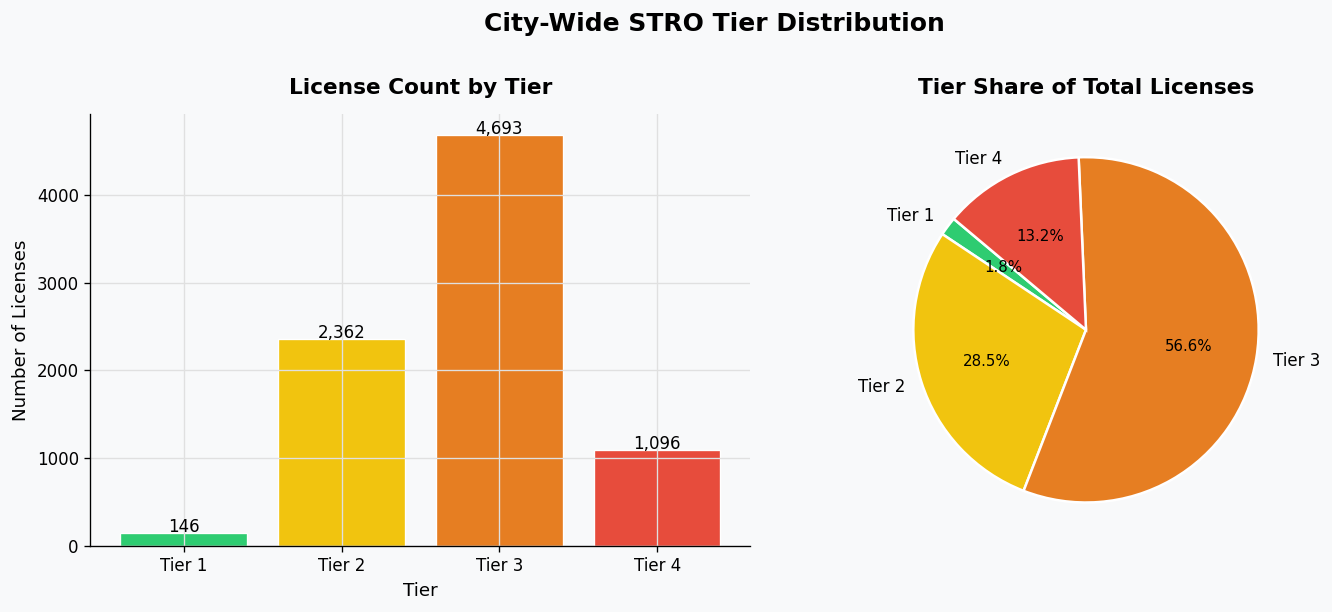

In [ ]:
# City-Wide Tier Distribution (Bar + Pie)
#       Baseline: what share of supply is high-intensity?
tier_counts = stro_df['tier'].value_counts().reindex(TIER_ORDER).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar
axes[0].bar(tier_counts.index, tier_counts.values,
            color=COLORS, edgecolor='white', linewidth=0.8)
axes[0].set_title("License Count by Tier", fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel("Tier")
axes[0].set_ylabel("Number of Licenses")
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 8, f"{int(v):,}", ha='center', fontsize=10)

# Pie
wedges, texts, autotexts = axes[1].pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title("Tier Share of Total Licenses", fontsize=13, fontweight='bold', pad=12)

fig.suptitle("City-Wide STRO Tier Distribution", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Interpretation: Tier 3 dominating at 4,647 licenses (nearly double Tier 2) tells you that the majority of San Diego's active STRO supply operates without any onsite residency requirement and at high annual rental frequency. This is not a city of occasional home-sharers — it is predominantly investor- or commercial-grade short-term rental activity. From a housing affordability standpoint, this means a large share of dwelling units have been effectively removed from the long-term rental or ownership market citywide.


Top 20 Neighborhoods by License Count

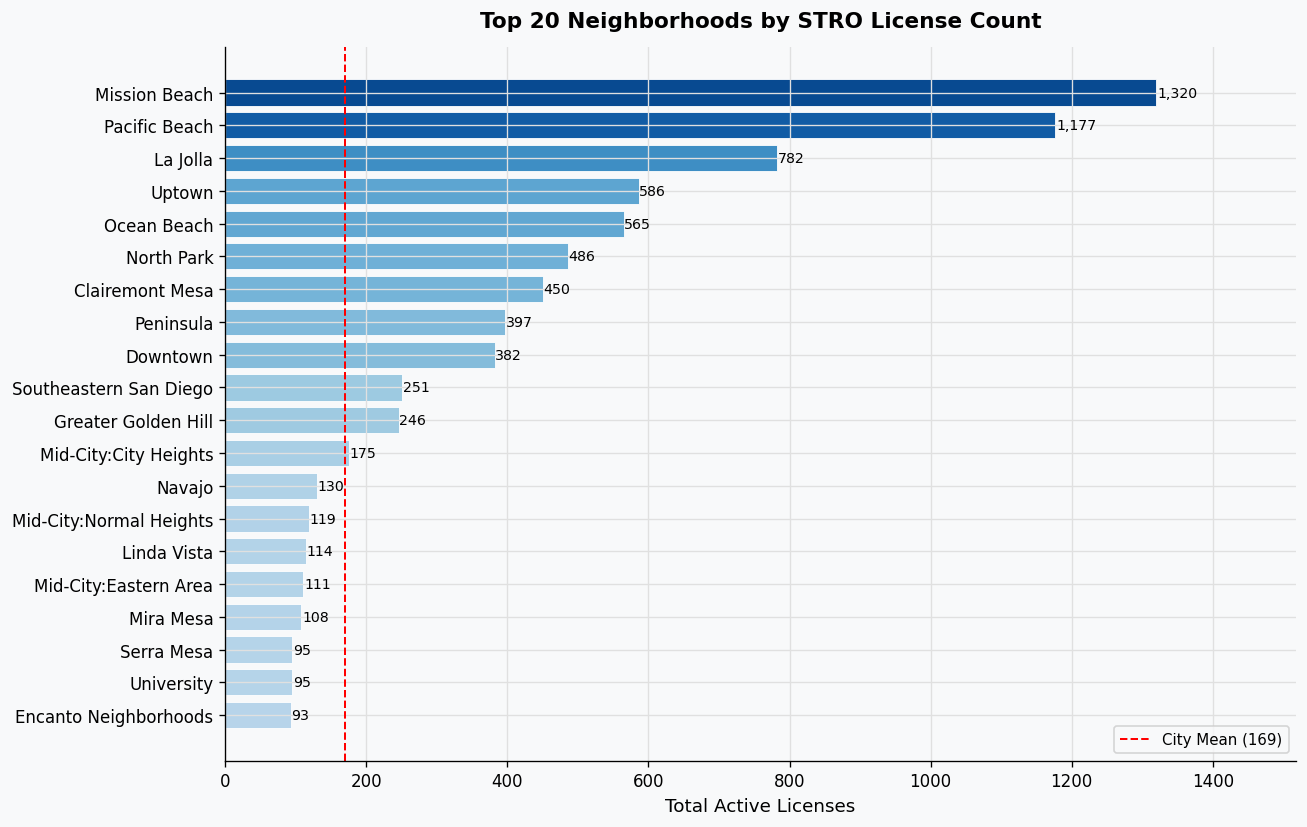

In [ ]:
# Top 20 Neighborhoods by License Count
#       Reveals where STRO activity is most spatially concentrated
top20 = nbhd.nlargest(20, 'total_licenses').sort_values('total_licenses')
city_mean = nbhd['total_licenses'].mean()

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top20['community_planning_area'],
    top20['total_licenses'],
    color=plt.cm.Blues(
        (top20['total_licenses'] - top20['total_licenses'].min()) /
        (top20['total_licenses'].max() - top20['total_licenses'].min()) * 0.6 + 0.3
    ),
    edgecolor='white', linewidth=0.5
)

ax.axvline(city_mean, color='red', linestyle='--', linewidth=1.2,
           label=f"City Mean ({city_mean:.0f})")

for bar, val in zip(bars, top20['total_licenses']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va='center', fontsize=8.5)

ax.set_xlabel("Total Active Licenses")
ax.set_title("Top 20 Neighborhoods by STRO License Count",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
ax.set_xlim(0, top20['total_licenses'].max() * 1.15)
plt.tight_layout()
plt.show()

Interpretation:
These three neighborhoods aren't simply busy — they represent a qualitatively different kind of pressure. Mission Beach being almost entirely Tier 4 is significant because Tier 4 is geographically exclusive to that planning area by design, meaning the city's own regulatory framework acknowledges its unique commercial intensity. Pacific Beach and La Jolla combining high volume with dominant Tier 3 share means they face the same commercial pressure without even the geographic containment that Mission Beach has. For your mismatch analysis, these are your Tier 1 hotspot candidates — neighborhoods where housing units are being absorbed into the short-term rental market at scale.


Stacked Tier Composition of Top 20 Neighborhoods

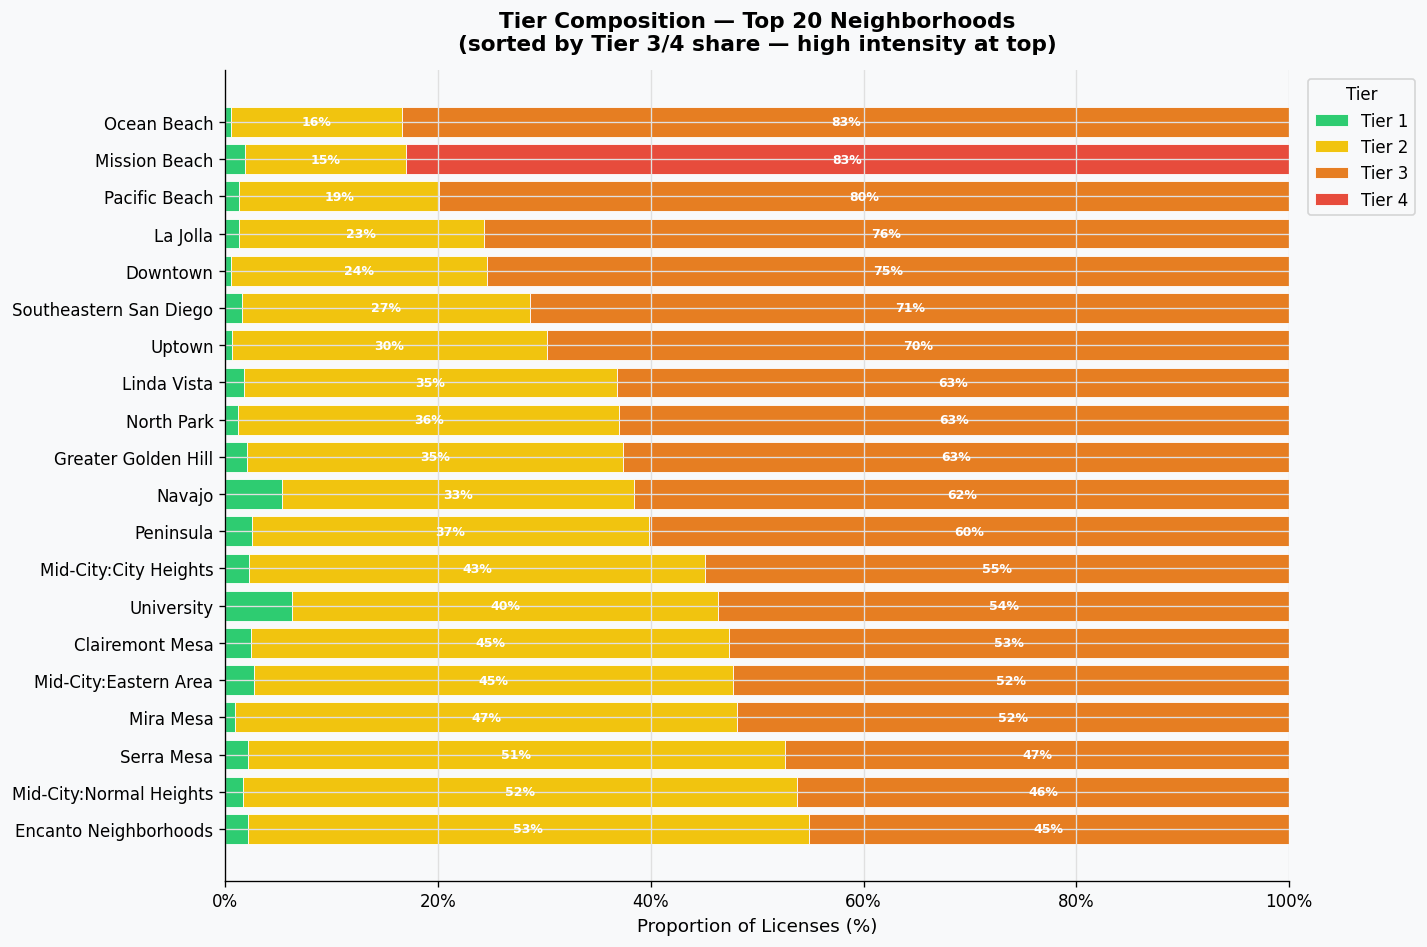

In [ ]:
# Stacked Tier Composition — Top 20 Neighborhoods
#       Core hotspot signal: which areas skew toward Tier 3/4?
top20_names = nbhd.nlargest(20, 'total_licenses')['community_planning_area'].tolist()

tier_by_nbhd = (
    stro_df[stro_df['community_planning_area'].isin(top20_names)]
    .groupby(['community_planning_area', 'tier'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=TIER_ORDER, fill_value=0)
)
tier_pct = tier_by_nbhd.div(tier_by_nbhd.sum(axis=1), axis=0) * 100
tier_pct = (tier_pct
            .assign(_sort=tier_pct['Tier 3'] + tier_pct['Tier 4'])
            .sort_values('_sort')
            .drop(columns='_sort'))

fig, ax = plt.subplots(figsize=(12, 8))
left = np.zeros(len(tier_pct))

for tier, color in zip(TIER_ORDER, COLORS):
    vals = tier_pct[tier].values
    ax.barh(tier_pct.index, vals, left=left, color=color,
            label=tier, edgecolor='white', linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 8:
            ax.text(l + v / 2, i, f"{v:.0f}%", ha='center', va='center',
                    fontsize=7.5, color='white', fontweight='bold')
    left += vals

ax.set_xlabel("Proportion of Licenses (%)")
ax.set_title("Tier Composition — Top 20 Neighborhoods\n"
             "(sorted by Tier 3/4 share — high intensity at top)",
             fontsize=13, fontweight='bold', pad=12)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Tier", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

Interpretation: Ocean beach is THEE hotspot. 83% Tier 3 composition is the highest intensity ratio in the dataset, even though its absolute volume is lower than Mission Beach or Pacific Beach. This means nearly every STRO license in Ocean Beach is operating at commercial scale. When you layer in affordability data, Ocean Beach could emerge as a particularly acute mismatch hotspot — high intensity relative to its size, which may be quietly suppressing long-term supply without attracting the same attention as the larger beach communities.

The pattern of Tier 2 being more prominent in the lower-ranked neighborhoods (further down your stacked bar chart) is meaningful. Tier 2 requires the host to live onsite for at least 275 days per year, so a higher Tier 2 share indicates the neighborhood's STRO activity is still largely owner-occupied and supplementary rather than commercial. These areas face less displacement pressure from short-term rentals, and are less likely to be mismatch hotspots on the supply side — though they may still have affordability issues from other causes.


Volume vs. High Intensity Share Scatter

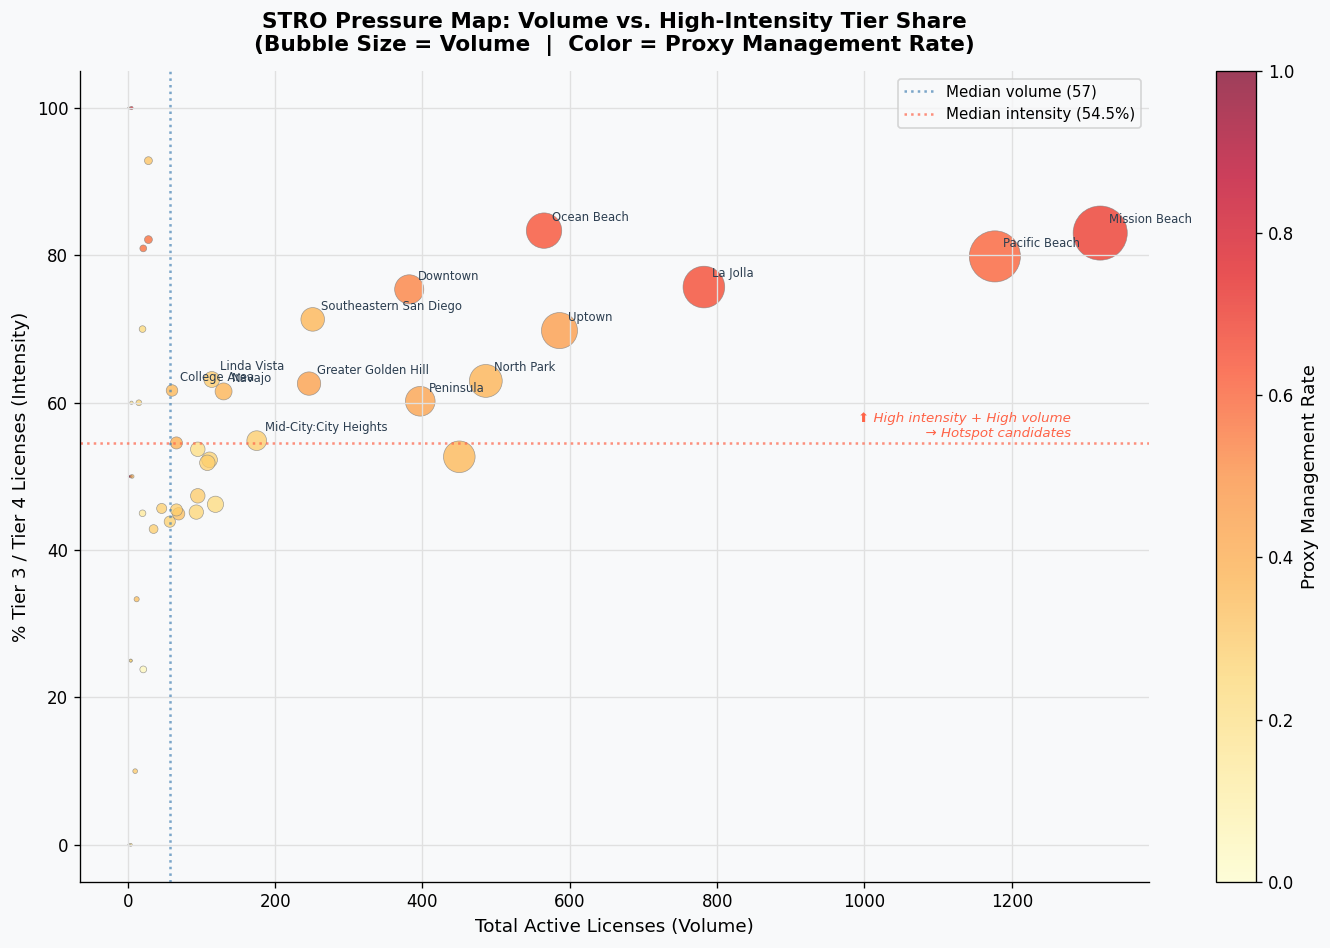

In [ ]:
# Volume vs. High-Intensity Share Scatter
#       Quadrant map — top-right = prime mismatch hotspot candidates
fig, ax = plt.subplots(figsize=(12, 8))

sc = ax.scatter(
    nbhd['total_licenses'],
    nbhd['pct_high_intensity'] * 100,
    c=nbhd['pct_proxy_managed'],
    cmap='YlOrRd',
    s=nbhd['total_licenses'] * 0.8,
    alpha=0.75,
    edgecolors='grey',
    linewidths=0.4
)
plt.colorbar(sc, ax=ax, label='Proxy Management Rate')

# Quadrant reference lines
med_vol = nbhd['total_licenses'].median()
med_int = nbhd['pct_high_intensity'].median() * 100
ax.axvline(med_vol, color='steelblue', linestyle=':', alpha=0.7,
           label=f'Median volume ({med_vol:.0f})')
ax.axhline(med_int, color='tomato', linestyle=':', alpha=0.7,
           label=f'Median intensity ({med_int:.1f}%)')

# Annotate top-right quadrant only (high volume AND high intensity)
hotspot_mask = (
    (nbhd['total_licenses'] > med_vol) &
    (nbhd['pct_high_intensity'] * 100 > med_int)
)
for _, row in nbhd[hotspot_mask].iterrows():
    ax.annotate(
        row['community_planning_area'],
        (row['total_licenses'], row['pct_high_intensity'] * 100),
        fontsize=7, ha='left', va='bottom',
        xytext=(5, 4), textcoords='offset points',
        color='#2c3e50'
    )

# Quadrant label
ax.text(nbhd['total_licenses'].max() * 0.97, med_int + 0.8,
        "⬆ High intensity + High volume\n  → Hotspot candidates",
        fontsize=8, color='tomato', ha='right', style='italic')

ax.set_xlabel("Total Active Licenses (Volume)", fontsize=11)
ax.set_ylabel("% Tier 3 / Tier 4 Licenses (Intensity)", fontsize=11)
ax.set_title("STRO Pressure Map: Volume vs. High-Intensity Tier Share\n"
             "(Bubble Size = Volume  |  Color = Proxy Management Rate)",
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Interpretation: The 13 neighborhoods below the median intensity line are your low-pressure baseline — relatively few licenses and low commercial intensity, suggesting STRO is not a significant force on housing supply there. The top-right quadrant — dominated by Mission Beach, Pacific Beach, and trailing closely by La Jolla and Ocean Beach — represents where both the volume and the commercial character of short-term rentals are highest simultaneously. These are the neighborhoods where, if your affordability data shows constrained supply or rising rents, you have the clearest evidence of a mismatch hotspot: STRO is actively competing with long-term residents for the same housing stock, at scale, with limited regulatory friction.

#### 4.3.7 Dataset Takeaways
The STRO dataset reveals that San Diego's short-term rental market is overwhelmingly commercial in character, with Tier 3 licenses, which require no onsite residency, accounting for the majority of active supply and dominating nearly every high-volume neighborhood. This commercialisation is spatially concentrated along the coastal corridor, where Mission Beach, Pacific Beach, Ocean Beach, and La Jolla collectively combine high license volumes with high-intensity tier compositions, suggesting these neighborhoods have lost a disproportionate share of their long-term housing stock to short-term rental use. These coastal communities therefore represent the strongest candidates for mismatch hotspots, where STRO-driven supply pressure is most likely to compound existing affordability constraints, a hypothesis that can be tested once affordability indicators are joined to this neighborhood-level data.

### 4.4 Accessory Dwelling Units (ADUs)



#### 4.4.1 Dataset Description

The ADU dataset contains project-level records related to accessory dwelling unit activity across jurisdictions in San Diego County. Each row represents a housing development or permit-related record and includes information such as jurisdiction, year, address, structure type, entitlement and permit indicators, affordability-related counts, and a point geometry field.

For the purposes of this project, ADUs are useful because they capture a form of **incremental housing supply** that may emerge differently across neighborhoods than large-scale affordable housing developments or traditional permitting pipelines. Even when ADUs are not formally income-restricted, they still represent additions to local housing stock and may help relieve pressure in neighborhoods where conventional new supply is limited.


#### 4.4.2 Prior Uses and Existing Analyses

https://opendata.sandag.org/stories/s/Annual-Progress-Report-Housing-Data-Explorer-2024/qh2c-a5j9/

The SANDAG Accessory Dwelling Unit Report 2024, is a public-facing analytical product built from the same underlying records. The report summarizes regional ADU permitting patterns and presents ADUs as an important component of housing production in San Diego County.

https://www.sdhc.org/uploadedFiles/Media_Center/Significant_Documents_Reports/SDHC-Housing-Production-Objectives-Report.pdf

The Terner Center has also published work specifically on San Diego’s ADU bonus program, describing the city’s experience as a case study in how local ADU policy can increase both missing-middle housing production and deed-restricted affordable units. That makes ADUs not only a descriptive supply measure but also a policy-relevant channel of housing growth.

#### 4.4.3 Data Collection

In [ ]:
adu_raw = pd.read_csv("data/HCD_ADUs_2024_20260225.csv")
print(adu_raw.shape)

(12848, 66)


#### 4.4.4 Cleaning and Preprocessing

In [ ]:
adu_df = adu_raw.copy()

adu_df.columns = (
    adu_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

adu_df.head()

,_id,jurisdiction,county,year,prior_apn,apn,street_address,project_name,jurs_tracking_id,structure_type,...,total_moderate_income_units_permitted,total_above_moderate_income_units_permitted,total_permitted_income_units,very_low_income_unit,low_income_unit,moderate_income_unit,above_moderate_income_unit,affordability,unit_year,point
0,558,SAN DIEGO COUNTY,San Diego,2021,NaN,2.384012e+09,1038 VEREDA CALLADA ADU,NaN,PDS2021-RESACC-000056,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.090564 33.081636)
1,1925,CHULA VISTA,San Diego,2024,NaN,6.191412e+09,1134 ALPINE AVENUE,NaN,BR23-0330,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2024,POINT (-117.0619139 32.61454169)
2,2081,CHULA VISTA,San Diego,2021,NaN,5.754331e+09,1143 HILLTOP DRIVE,NaN,BR20-0087,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.056031 32.615687)
3,2514,VISTA,San Diego,2021,169-080-69-00,1.690807e+09,1188 ACADEMY LANE #1,NaN,NaN,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2021,POINT (-117.251376 33.180839)
4,3405,IMPERIAL BEACH,San Diego,2022,NaN,6.330923e+09,1254 13TH ST UNIT: #02,ADU,BLDR-22-1049,Accessory Dwelling Unit,...,0,1,1,False,False,False,True,Above Moderate,2022,POINT (-117.106138 32.573857)


In [ ]:
adu_df.columns.tolist()

['_id',
 'jurisdiction',
 'county',
 'year',
 'prior_apn',
 'apn',
 'street_address',
 'project_name',
 'jurs_tracking_id',
 'structure_type',
 'tenure',
 'vlow_income_dr',
 'vlow_income_ndr',
 'low_income_dr',
 'low_income_ndr',
 'mod_income_dr',
 'mod_income_ndr',
 'above_mod_income',
 'ent_approve_dt1',
 'no_entitlements',
 'bp_vlow_income_dr',
 'bp_vlow_income_ndr',
 'bp_low_income_dr',
 'bp_low_income_ndr',
 'bp_mod_income_dr',
 'bp_mod_income_ndr',
 'bp_above_mod_income',
 'bp_issue_dt1',
 'no_building_permits',
 'co_vlow_income_dr',
 'co_vlow_income_ndr',
 'co_low_income_dr',
 'co_low_income_ndr',
 'co_mod_income_dr',
 'co_mod_income_ndr',
 'co_above_mod_income',
 'co_issue_dt1',
 'no_other_forms_of_readiness',
 'extr_low_income_units',
 'approve_sb35',
 'infill_units',
 'fin_assist_name',
 'dr_type',
 'no_fa_dr',
 'term_aff_dr',
 'dem_des_units',
 'dem_or_des_units',
 'dem_des_units_own_rent',
 'density_bonus_total',
 'density_bonus_number_other_incentives',
 'density_bonus_inc

In [ ]:
numeric_cols = [
    "year",
    "total_very_low_income_units_permitted",
    "total_low_income_units_permitted",
    "total_moderate_income_units_permitted",
    "total_above_moderate_income_units_permitted",
    "total_permitted_income_units"
]

for col in numeric_cols:
    if col in adu_df.columns:
        adu_df[col] = pd.to_numeric(adu_df[col], errors="coerce")

date_cols = ["ent_approve_dt1", "bp_issue_dt1", "co_issue_dt1", "unit_year"]
for col in date_cols:
    if col in adu_df.columns:
        adu_df[col] = pd.to_datetime(adu_df[col], errors="coerce")

adu_df[["jurisdiction", "county", "year", "structure_type", "affordability"]].head()

,jurisdiction,county,year,structure_type,affordability
0,SAN DIEGO COUNTY,San Diego,2021,Accessory Dwelling Unit,Above Moderate
1,CHULA VISTA,San Diego,2024,Accessory Dwelling Unit,Above Moderate
2,CHULA VISTA,San Diego,2021,Accessory Dwelling Unit,Above Moderate
3,VISTA,San Diego,2021,Accessory Dwelling Unit,Above Moderate
4,IMPERIAL BEACH,San Diego,2022,Accessory Dwelling Unit,Above Moderate


In [ ]:
# parse the Point column into geometry
adu_df["point"] = adu_df["point"].astype("string")
adu_df = adu_df.dropna(subset=["point"]).copy()

adu_df["geometry"] = adu_df["point"].apply(wkt.loads)

adu_gdf = gpd.GeoDataFrame(adu_df, geometry="geometry", crs="EPSG:4326")
adu_gdf.head()

,_id,jurisdiction,county,year,prior_apn,apn,street_address,project_name,jurs_tracking_id,structure_type,...,total_above_moderate_income_units_permitted,total_permitted_income_units,very_low_income_unit,low_income_unit,moderate_income_unit,above_moderate_income_unit,affordability,unit_year,point,geometry
0,558,SAN DIEGO COUNTY,San Diego,2021,NaN,2.384012e+09,1038 VEREDA CALLADA ADU,NaN,PDS2021-RESACC-000056,Accessory Dwelling Unit,...,1,1,False,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.090564 33.081636),POINT (-117.09056 33.08164)
1,1925,CHULA VISTA,San Diego,2024,NaN,6.191412e+09,1134 ALPINE AVENUE,NaN,BR23-0330,Accessory Dwelling Unit,...,1,1,False,False,False,True,Above Moderate,1970-01-01 00:00:00.000002024,POINT (-117.0619139 32.61454169),POINT (-117.06191 32.61454)
2,2081,CHULA VISTA,San Diego,2021,NaN,5.754331e+09,1143 HILLTOP DRIVE,NaN,BR20-0087,Accessory Dwelling Unit,...,1,1,False,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.056031 32.615687),POINT (-117.05603 32.61569)
3,2514,VISTA,San Diego,2021,169-080-69-00,1.690807e+09,1188 ACADEMY LANE #1,NaN,NaN,Accessory Dwelling Unit,...,1,1,False,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.251376 33.180839),POINT (-117.25138 33.18084)
4,3405,IMPERIAL BEACH,San Diego,2022,NaN,6.330923e+09,1254 13TH ST UNIT: #02,ADU,BLDR-22-1049,Accessory Dwelling Unit,...,1,1,False,False,False,True,Above Moderate,1970-01-01 00:00:00.000002022,POINT (-117.106138 32.573857),POINT (-117.10614 32.57386)


In [ ]:
for col in ["jurisdiction", "county", "structure_type", "affordability", "street_address"]:
    if col in adu_gdf.columns:
        adu_gdf[col] = adu_gdf[col].astype("string").str.strip()

if "county" in adu_gdf.columns:
    adu_gdf = adu_gdf[adu_gdf["county"].str.upper() == "SAN DIEGO"].copy()

adu_city_gdf = adu_gdf[adu_gdf["jurisdiction"].str.upper() == "SAN DIEGO"].copy()

print("Countywide ADU records:", len(adu_gdf))
print("City of San Diego ADU records:", len(adu_city_gdf))

Countywide ADU records: 12811
City of San Diego ADU records: 5931


In [ ]:
adu_gdf[[
    "jurisdiction", "year", "structure_type",
    "affordability", "total_permitted_income_units"
]].isna().mean().sort_values(ascending=False)

,0
jurisdiction,0.0
year,0.0
structure_type,0.0
affordability,0.0
total_permitted_income_units,0.0


#### 4.4.5 Neighborhood Aggregation


In [ ]:
adu_zip = spatial_join_points_to_zip(
    adu_gdf,
    zip_gdf=sd_zcta_named_gdf,
    zip_col="zip"
)
adu_zip.head()

,_id,jurisdiction,county,year,prior_apn,apn,street_address,project_name,jurs_tracking_id,structure_type,...,low_income_unit,moderate_income_unit,above_moderate_income_unit,affordability,unit_year,point,geometry,index_right,zip,community_name
0,558,SAN DIEGO COUNTY,San Diego,2021,NaN,2.384012e+09,1038 VEREDA CALLADA ADU,NaN,PDS2021-RESACC-000056,Accessory Dwelling Unit,...,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.090564 33.081636),POINT (-117.09056 33.08164),95,92029,None
1,1925,CHULA VISTA,San Diego,2024,NaN,6.191412e+09,1134 ALPINE AVENUE,NaN,BR23-0330,Accessory Dwelling Unit,...,False,False,True,Above Moderate,1970-01-01 00:00:00.000002024,POINT (-117.0619139 32.61454169),POINT (-117.06191 32.61454),27,91911,OTAY MESA-NESTOR
2,2081,CHULA VISTA,San Diego,2021,NaN,5.754331e+09,1143 HILLTOP DRIVE,NaN,BR20-0087,Accessory Dwelling Unit,...,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.056031 32.615687),POINT (-117.05603 32.61569),27,91911,OTAY MESA-NESTOR
3,2514,VISTA,San Diego,2021,169-080-69-00,1.690807e+09,1188 ACADEMY LANE #1,NaN,NaN,Accessory Dwelling Unit,...,False,False,True,Above Moderate,1970-01-01 00:00:00.000002021,POINT (-117.251376 33.180839),POINT (-117.25138 33.18084),7,92081,None
4,3405,IMPERIAL BEACH,San Diego,2022,NaN,6.330923e+09,1254 13TH ST UNIT: #02,ADU,BLDR-22-1049,Accessory Dwelling Unit,...,False,False,True,Above Moderate,1970-01-01 00:00:00.000002022,POINT (-117.106138 32.573857),POINT (-117.10614 32.57386),28,91932,OTAY MESA-NESTOR


In [ ]:
adu_zip_summary = (
    adu_zip.dropna(subset=["zip"])
    .groupby("zip")
    .agg(
        adu_projects=("_id", "count"),
        adu_total_permitted_units=("total_permitted_income_units", "sum")
    )
    .reset_index()
)

adu_zip_summary.head()

,zip,adu_projects,adu_total_permitted_units
0,91901,90,90
1,91902,124,124
2,91905,3,3
3,91906,4,4
4,91910,349,398


In [ ]:
if "affordability" in adu_zip.columns:
    adu_affordability = (
        adu_zip.dropna(subset=["zip"])
        .pivot_table(
            index="zip",
            columns="affordability",
            values="_id",
            aggfunc="count",
            fill_value=0
        )
        .reset_index()
    )

    adu_affordability.columns = [
        "zip" if c == "zip" else f"adu_affordability_{str(c).strip().lower().replace(' ', '_').replace('-', '_')}"
        for c in adu_affordability.columns
    ]

    adu_zip_summary = adu_zip_summary.merge(adu_affordability, on="zip", how="left")

adu_zip_summary.head()

,zip,adu_projects,adu_total_permitted_units,adu_affordability_above_moderate,adu_affordability_low,adu_affordability_moderate,adu_affordability_very_low
0,91901,90,90,14,30,35,11
1,91902,124,124,47,32,32,13
2,91905,3,3,0,1,0,2
3,91906,4,4,1,1,1,1
4,91910,349,398,343,4,2,0


In [ ]:
adu_year_summary = (
    adu_gdf.groupby("year")
    .agg(
        adu_projects=("_id", "count"),
        adu_total_permitted_units=("total_permitted_income_units", "sum")
    )
    .reset_index()
    .sort_values("year")
)

adu_year_summary.head()

,year,adu_projects,adu_total_permitted_units
0,2018,472,474
1,2019,1082,1105
2,2020,1132,1149
3,2021,1865,1980
4,2022,1850,2034


In [ ]:
adu_map_gdf = sd_zcta_named_gdf.merge(
    adu_zip_summary,
    on="zip",
    how="left"
)

num_cols = adu_map_gdf.select_dtypes(include=[np.number]).columns
adu_map_gdf[num_cols] = adu_map_gdf[num_cols].fillna(0)

adu_map_gdf.to_file("data/adu_aggregated_gdf.geojson", driver="GeoJSON")

adu_map_gdf.head()

,zip,community_name,overlap_area,geometry,adu_projects,adu_total_permitted_units,adu_affordability_above_moderate,adu_affordability_low,adu_affordability_moderate,adu_affordability_very_low
0,92140,None,0.000000e+00,"POLYGON ((-117.2094 32.74251, -117.20925 32.74...",0.0,0.0,0.0,0.0,0.0,0.0
1,92093,None,0.000000e+00,"POLYGON ((-117.24389 32.87956, -117.24388 32.8...",0.0,0.0,0.0,0.0,0.0,0.0
2,92161,None,0.000000e+00,"POLYGON ((-117.23426 32.87331, -117.23423 32.8...",0.0,0.0,0.0,0.0,0.0,0.0
3,92154,OTAY MESA-NESTOR,1.093848e+06,"POLYGON ((-117.11888 32.53954, -117.11886 32.5...",207.0,234.0,178.0,4.0,25.0,0.0
4,91942,NAVAJO,1.992777e+02,"POLYGON ((-117.05347 32.7572, -117.05344 32.75...",273.0,273.0,36.0,19.0,218.0,0.0



#### 4.4.6 Exploratory Data Analysis



In [ ]:
adu_zip_summary.sort_values("adu_projects", ascending=False).head(15)

,zip,adu_projects,adu_total_permitted_units,adu_affordability_above_moderate,adu_affordability_low,adu_affordability_moderate,adu_affordability_very_low
72,92115,804,912,756,3,45,0
30,92024,599,602,354,23,145,77
74,92117,529,585,480,0,48,1
63,92104,422,552,409,0,13,0
64,92105,416,481,404,4,7,1
4,91910,349,398,343,4,2,0
5,91911,332,343,332,0,0,0
73,92116,317,423,304,4,9,0
71,92114,316,387,301,3,12,0
69,92111,312,409,280,1,31,0


In [ ]:
adu_zip_summary.sort_values("adu_total_permitted_units", ascending=False).head(15)

,zip,adu_projects,adu_total_permitted_units,adu_affordability_above_moderate,adu_affordability_low,adu_affordability_moderate,adu_affordability_very_low
72,92115,804,912,756,3,45,0
30,92024,599,602,354,23,145,77
74,92117,529,585,480,0,48,1
63,92104,422,552,409,0,13,0
64,92105,416,481,404,4,7,1
73,92116,317,423,304,4,9,0
69,92111,312,409,280,1,31,0
70,92113,301,400,273,2,25,1
4,91910,349,398,343,4,2,0
71,92114,316,387,301,3,12,0


In [ ]:
if "affordability" in adu_gdf.columns:
    adu_gdf["affordability"].value_counts(dropna=False)

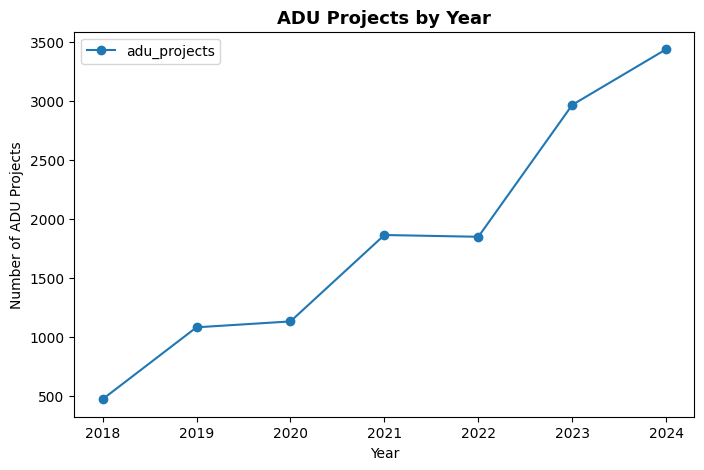

In [ ]:
ax = adu_year_summary.plot(
    x="year",
    y="adu_projects",
    marker="o",
    figsize=(8, 5)
)
ax.set_title("ADU Projects by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of ADU Projects")
plt.show()

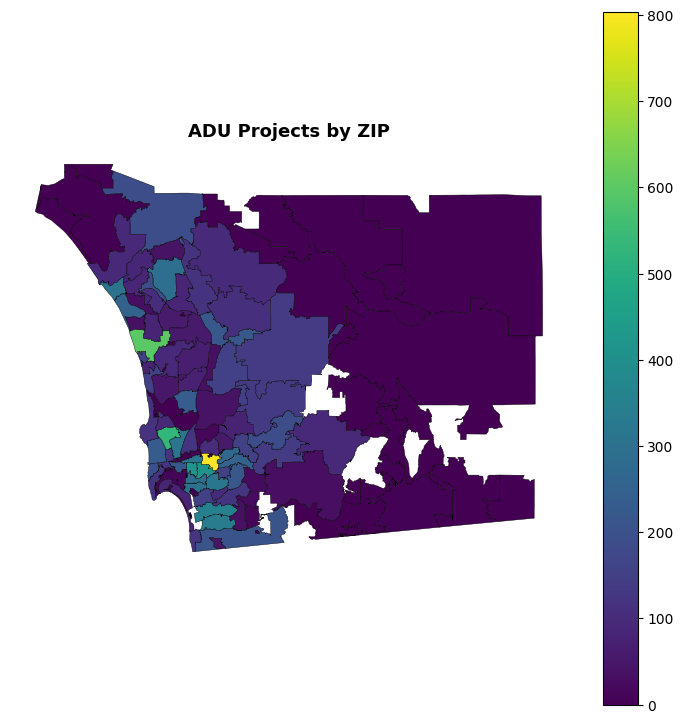

In [ ]:
plot_zip_choropleth(
    adu_map_gdf,
    column="adu_projects",
    title="ADU Projects by ZIP"
)

#### 4.4.7 Dataset Takeaways

Unlike the affordable housing inventory, which captures an existing baseline of affordable developments, the ADU dataset reflects a more dispersed and dynamic form of supply growth. This makes it especially relevant for identifying neighborhoods where some degree of housing expansion may be occurring outside of large formal affordable housing projects.

A limitation of this source is that ADU permits do not necessarily translate immediately into occupied housing units, and the affordability classifications in the dataset may not correspond to long-term affordability in the same way as formal income-restricted affordable housing. Even so, the dataset provides valuable evidence about where incremental housing production is strongest and weakest.

### 4.5 Affordable Housing Permits

#### 4.5.1 Dataset Description

The Affordable Housing Permits Dashboard contains records of affordable housing applications processed by the City of San Diego's Development Services Department. Each row showcases a record of a housing development project. This dataset is helpful because it captures formally income-restricted affordable housing units produced through the City's Inclusionary Affordable Housing Program.

| Column | Type | Description |
|---|---|---|
| ApprovalID | String | Unique permit identifier |
| Address | String | Street address of the project |
| ProjectID | String | Parent project identifier |
| ApprovalStatus | String | Current status of the permit approval |
| ProjectTitle | String | Name or description of the housing project |
| CensusBureauCategory | String | Building type per Census Bureau classification |
| ApprovalCreation | Date | Date the permit was submitted |
| ApprovalIssuance | Date | Date the permit was officially issued |
| AffordableUnits | Integer | Number of affordable units in the project |

#### 4.5.2 Prior Uses and Existing Analyses

The City of San Diego already uses this data in the Affordable Housing Permitting Dashboard. The dashboard is a public monitoring tool designed to track affordable housing permits across stages such as applications under review, permitted or entitled projects, and completed or constructed projects.

https://www.sandiego.gov/development-services/permits-inspections/dashboard

#### 4.5.3 Data Collection

In [ ]:
ahp_raw = pd.read_csv("data/Affordability_Dashboard.csv")
ahp_df = ahp_raw.copy()
ahp_df.head()

,ApprovalID,Address,ProjectID,ApprovalStatus,ProjectTitle,CensusBureauCategory,ApprovalCreation,ApprovalIssuance,ProjectURL,ApprovalURL,AffordableUnits
0,PMT-3149665,"4060 Euclid Av, San Diego, CA 92105",NaN,NaN,NaN,NaN,4/19/2022,NaN,NaN,https://aca-prod.accela.com/SANDIEGO/Cap/CapDe...,NaN
1,PMT-3155576,"5229 Rincon St, San Diego, CA",NaN,NaN,NaN,NaN,5/20/2022,NaN,NaN,https://aca-prod.accela.com/SANDIEGO/Cap/CapDe...,5.0
2,PMT-3159587,"2860 Webster Av, San Diego, CA 92113",NaN,NaN,NaN,NaN,6/13/2022,NaN,NaN,https://aca-prod.accela.com/SANDIEGO/Cap/CapDe...,3.0
3,PMT-3160779,"1902 1/3 69th St, San Diego, CA",NaN,NaN,NaN,NaN,6/20/2022,NaN,NaN,https://aca-prod.accela.com/SANDIEGO/Cap/CapDe...,1.0
4,PMT-3164600,"3014 Ulric Ct, San Diego, CA",NaN,NaN,NaN,NaN,7/12/2022,NaN,NaN,https://aca-prod.accela.com/SANDIEGO/Cap/CapDe...,1.0


#### 4.5.4 Cleaning and Processing

In [ ]:
print("\nColumn names:", ahp_df.columns.tolist())
print("\nData types:\n", ahp_df.dtypes)


Column names: ['ApprovalID', 'Address', 'ProjectID', 'ApprovalStatus', 'ProjectTitle', 'CensusBureauCategory', 'ApprovalCreation', 'ApprovalIssuance', 'ProjectURL', 'ApprovalURL', 'AffordableUnits']

Data types:
 ApprovalID               object
Address                  object
ProjectID                object
ApprovalStatus           object
ProjectTitle             object
CensusBureauCategory     object
ApprovalCreation         object
ApprovalIssuance         object
ProjectURL               object
ApprovalURL              object
AffordableUnits         float64
dtype: object


In [ ]:
ahp_df.columns = (
    ahp_df.columns
    .str.strip()
)

In [ ]:
ahp_df["ApprovalCreation"] = pd.to_datetime(ahp_df["ApprovalCreation"], errors="coerce")
ahp_df["ApprovalIssuance"] = pd.to_datetime(ahp_df["ApprovalIssuance"], errors="coerce")
ahp_df["Year"] = ahp_df["ApprovalCreation"].dt.year
ahp_df["AffordableUnits"] = pd.to_numeric(ahp_df["AffordableUnits"], errors="coerce")
ahp_df['DaysToIssuance'] = (ahp_df['ApprovalIssuance'] - ahp_df['ApprovalCreation']).dt.days
str_cols = ["ApprovalID", "Address", "ApprovalStatus", "ProjectTitle", "CensusBureauCategory"]


In [ ]:
for col in str_cols:
    ahp_df[col] = ahp_df[col].astype("string").str.strip()
ahp_df[col] = ahp_df[col].astype("string").str.strip().fillna("")
ahp_df = ahp_df.drop(columns=["ProjectURL", "ApprovalURL"])
ahp_df.head()

,ApprovalID,Address,ProjectID,ApprovalStatus,ProjectTitle,CensusBureauCategory,ApprovalCreation,ApprovalIssuance,AffordableUnits,Year,DaysToIssuance
0,PMT-3149665,"4060 Euclid Av, San Diego, CA 92105",NaN,<NA>,<NA>,,2022-04-19,NaT,NaN,2022,NaN
1,PMT-3155576,"5229 Rincon St, San Diego, CA",NaN,<NA>,<NA>,,2022-05-20,NaT,5.0,2022,NaN
2,PMT-3159587,"2860 Webster Av, San Diego, CA 92113",NaN,<NA>,<NA>,,2022-06-13,NaT,3.0,2022,NaN
3,PMT-3160779,"1902 1/3 69th St, San Diego, CA",NaN,<NA>,<NA>,,2022-06-20,NaT,1.0,2022,NaN
4,PMT-3164600,"3014 Ulric Ct, San Diego, CA",NaN,<NA>,<NA>,,2022-07-12,NaT,1.0,2022,NaN


In [ ]:
print("Missingness")
miss = ahp_df.isnull().sum()
miss_pct = 100 * miss / len(ahp_df)
miss_df = pd.DataFrame({"Missing N": miss, "Missing %": miss_pct.round(1)})
miss_df = miss_df[miss_df["Missing N"] > 0].sort_values("Missing %", ascending=False)
print(miss_df.to_string())
ahp_df['IsIssued'] = ahp_df['ApprovalIssuance'].notna().astype(int)
ahp_df['HasCategory'] = ahp_df['CensusBureauCategory'].notna().astype(int)
ahp_df['HasProjectID'] = ahp_df['ProjectID'].notna().astype(int)

Missingness
                  Missing N  Missing %
DaysToIssuance          278       27.9
ApprovalIssuance        278       27.9
ProjectTitle             80        8.0
ProjectID                80        8.0
ApprovalStatus           18        1.8
AffordableUnits           2        0.2


In [ ]:
ahp_df["zip"] = ahp_df["Address"].str.extract(r'(\d{5})$')
ahp_df['IsIssued'] = ahp_df['ApprovalIssuance'].notna().astype(int)
ahp_df['HasCategory'] = ahp_df['CensusBureauCategory'].notna().astype(int)
ahp_df['HasProjectID'] = ahp_df['ProjectID'].notna().astype(int)

In [ ]:
total_records = len(ahp_df)
total_affordable_units = ahp_df["AffordableUnits"].sum()
avg_unit_per_project = ahp_df["AffordableUnits"].mean()
print(f"\n  --- Approval Status Breakdown ---")
for status, count in ahp_df["ApprovalStatus"].value_counts(dropna=False).items():
    pct = count / total_records * 100
    print(f"  {str(status):<40}: {count:>5,}  ({pct:.1f}%)")
print(f"\n  --- Top 5 Census Bureau Categories ---")
for cat, count in ahp_df["CensusBureauCategory"].value_counts(dropna=False).head(5).items():
    pct = count / total_records * 100
    print(f"  {str(cat):<40}: {count:>5,}  ({pct:.1f}%)")
print(f"\n  --- Records by Year ---")
for year, count in ahp_df["ApprovalCreation"].dt.year.value_counts().sort_index().items():
    print(f"  {int(year):<40}: {count:>5,}")


  --- Approval Status Breakdown ---
  Completed                               :   224  (22.4%)
  Inspection Followup                     :   198  (19.8%)
  Closed                                  :   152  (15.2%)
  Issued                                  :   134  (13.4%)
  Cancelled Application Expired           :   106  (10.6%)
  Cancelled                               :    78  (7.8%)
  Opened                                  :    42  (4.2%)
  Created                                 :    40  (4.0%)
  <NA>                                    :    18  (1.8%)
  Approved Upon Final Payment             :     4  (0.4%)
  Pending Invoice Payment                 :     2  (0.2%)

  --- Top 5 Census Bureau Categories ---
  Five or More Family Apt                 :   390  (39.1%)
  Add/Alt Companion Unit/Acc Apt          :   260  (26.1%)
                                          :   116  (11.6%)
  Add/Alt 1 or 2 Fam, No Chg DU           :    50  (5.0%)
  Five or More Family Condo               :

#### 4.5.5 Neighborhood Aggregation

In [ ]:
# Group by ZIP to create our core features
ahp_zip_summary = (
    ahp_df.dropna(subset=["zip"])
    .groupby("zip")
    .agg(
        ahp_total_permits=("ApprovalID", "count"),
        ahp_affordable_units=("AffordableUnits", "sum"),
        ahp_avg_days_to_issue=("DaysToIssuance", "mean"),
        ahp_pct_issued=("IsIssued", "mean")
    )
    .reset_index()
)

print("\n--- Affordable Housing Permits Zip Summary ---")
print(ahp_zip_summary.describe())
print(f"\nUnique ZIPs in raw AHP data: {ahp_zip_summary['zip'].nunique()}")


--- Affordable Housing Permits Zip Summary ---
       ahp_total_permits  ahp_affordable_units  ahp_avg_days_to_issue  \
count          18.000000             18.000000              17.000000   
mean           16.555556            121.333333             508.085339   
std            12.682652            173.014790             135.158614   
min             2.000000              2.000000             279.500000   
25%             8.000000             25.500000             427.750000   
50%            13.000000             51.000000             497.666667   
75%            20.000000            123.000000             632.000000   
max            50.000000            550.000000             713.500000   

       ahp_pct_issued  
count       18.000000  
mean         0.679974  
std          0.284387  
min          0.000000  
25%          0.500000  
50%          0.732143  
75%          0.868333  
max          1.000000  

Unique ZIPs in raw AHP data: 18


In [ ]:
ahp_map_gdf = sd_zcta_named_gdf.merge(
    ahp_zip_summary,
    on="zip",
    how="left"
)

total_map_zips = len(ahp_map_gdf)
zips_with_data = ahp_map_gdf['ahp_total_permits'].notna().sum()
zips_missing = ahp_map_gdf['ahp_total_permits'].isna().sum()

print(f"Total ZIPs in San Diego map: {total_map_zips}")
print(f"ZIPs matching AHP records: {zips_with_data}")
print(f"ZIPs with NO AHP records (missing): {zips_missing}")

num_cols = ahp_map_gdf.select_dtypes(include=[np.number]).columns
ahp_map_gdf[num_cols] = ahp_map_gdf[num_cols].fillna(0)

ahp_map_gdf.to_file("data/ahp_aggregated_gdf.geojson", driver="GeoJSON")

display(ahp_map_gdf.head())

Total ZIPs in San Diego map: 116
ZIPs matching AHP records: 18
ZIPs with NO AHP records (missing): 98


,zip,community_name,overlap_area,geometry,ahp_total_permits,ahp_affordable_units,ahp_avg_days_to_issue,ahp_pct_issued
0,92140,None,0.000000e+00,"POLYGON ((-117.2094 32.74251, -117.20925 32.74...",0.0,0.0,0.000000,0.0
1,92093,None,0.000000e+00,"POLYGON ((-117.24389 32.87956, -117.24388 32.8...",0.0,0.0,0.000000,0.0
2,92161,None,0.000000e+00,"POLYGON ((-117.23426 32.87331, -117.23423 32.8...",0.0,0.0,0.000000,0.0
3,92154,OTAY MESA-NESTOR,1.093848e+06,"POLYGON ((-117.11888 32.53954, -117.11886 32.5...",34.0,316.0,345.235294,1.0
4,91942,NAVAJO,1.992777e+02,"POLYGON ((-117.05347 32.7572, -117.05344 32.75...",0.0,0.0,0.000000,0.0


#### 4.5.6 Exploratory Data Analysis

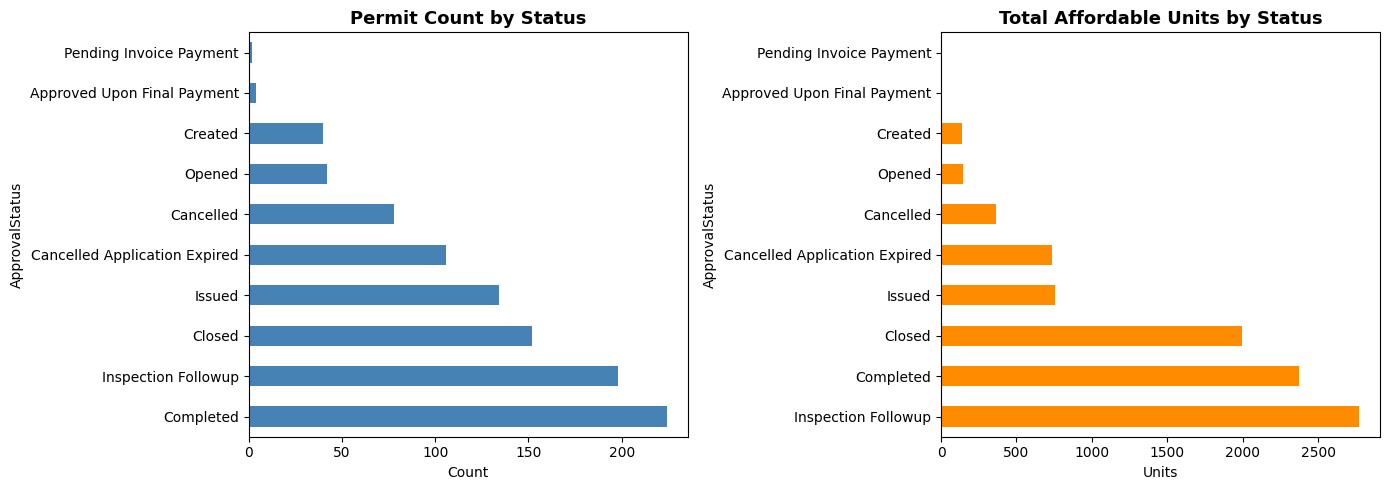

In [ ]:
status_units = ahp_df.groupby('ApprovalStatus')['AffordableUnits'].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ahp_df['ApprovalStatus'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Permit Count by Status")
axes[0].set_xlabel("Count")
status_units.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title("Total Affordable Units by Status")
axes[1].set_xlabel("Units")

plt.tight_layout()
plt.show()

#### 4.5.7 Dataset Takeaways
The Affordable Housing Permits dataset reveals that formal affordable housing production in San Diego is heavily skewed toward larger multifamily developments, with Five or More Family Apt accounting for nearly 40% of all permit records and Add/Alt Companion Unit categories making up another 26%. This suggests that affordable housing supply growth is driven primarily by large-scale projects rather than dispersed incremental additions.
Completed and Inspection Followup statuses together accounts for over 40% of records. While Completed permits lead in raw record count, Inspection Followup records actually deliver the highest number of affordable units, meaning the projects furthest along in the pipeline but not yet fully closed are carrying the most housing weight.

### 4.6 Annual Progress Report

#### 4.6.1 Dataset Description

The Annual Progress Report (APR) dataset contains project-level records of housing development applications submitted by local jurisdictions to the California Department of Housing and Community Development. Each row represents a single housing project or permit application and includes information such as jurisdiction, county, year, street address, parcel number, project name, unit category, tenure type, income-level breakdowns (Very Low, Low, Moderate, Above Moderate), proposed and approved unit counts, density bonus indicators, and application status.
The APR dataset is valuable because it captures the full spectrum of housing production activity across San Diego County jurisdictions.The income-level columns in particular allow for direct identification of deed-restricted affordable units at each AMI tier, allowing for stronger insights on supply of housing.

| Column | Type | Description |
|---|---|---|
| JURIS_NAME | String | Reporting jurisdiction |
| COUNTY | String | County the jurisdiction belongs to |
| YEAR | Integer | APR reporting year |
| APN | String | Assessor Parcel Number |
| ADDRESS | String | Street address of the project |
| JURS_TRACKING_ID | String | Jurisdiction's internal permit tracking ID |
| ALT_ID | String | Alternate tracking ID|
| UNIT_CAT | String | Housing unit category  |
| TENURE | String | Intended occupancy type (Renter or Owner) |
| APP_SUBMIT_DT | Date | Date the application was submitted |
| VLOW_INCOME_DR | Integer | Very-low income units, deed-restricted |
| VLOW_INCOME_NDR | Integer | Very-low income units, non-deed-restricted |
| LOW_INCOME_DR | Integer | Low income units, deed-restricted |
| LOW_INCOME_NDR | Integer | Low income units, non-deed-restricted |
| MOD_INCOME_DR | Integer | Moderate income units, deed-restricted |
| MOD_INCOME_NDR | Integer | Moderate income units, non-deed-restricted |
| ABOVE_MOD_INCOME | Integer | Above-moderate income units |
| TOT_PROPOSED_UNITS | Integer | Total units proposed in the application |
| TOT_APPROVED_UNITS | Integer | Total units approved |
| TOT_DISAPPROVED_UNITS | Integer | Total units disapproved |
| APP_SUBMITTED_SB35 | String | Whether SB 35 streamlined approval was invoked |
| DENSITY_BONUS_RECEIVED | String | Whether a density bonus was requested |
| DENSITY_BONUS_APPROVED | String | Whether a density bonus was granted |
| APPLICATION_STATUS | String | Permit status |
| PROJECT_TYPE | String | Project Type |
| NOTES | String | Project Notes |

#### 4.6.1 Prior Uses and Existing Analysis

The California Department of Housing and Community Development (HCD) uses Annual Progress Reports (APRs) as the official mechanism for tracking jurisdictions’ implementation of their housing elements. HCD’s APR dashboard states that each jurisdiction must prepare an APR reporting on progress toward housing goals, including all housing development applications, entitlements, building permits, and completions.

https://www.hcd.ca.gov/housing-open-data-tools/apr-dashboard

#### 4.6.3 Data Collection

In [ ]:
apr_raw = pd.read_csv("data/annualprogressrep.csv")
print(apr_raw.shape)
apr_raw.head()

(18244, 27)


,JURIS_NAME,CNTY_NAME,YEAR,PRIOR_APN,APN,STREET_ADDRESS,PROJECT_NAME,JURS_TRACKING_ID,UNIT_CAT,TENURE,...,ABOVE_MOD_INCOME,TOT_PROPOSED_UNITS,TOT_APPROVED_UNITS,TOT_DISAPPROVED_UNITS,APP_SUBMITTED_SB35,DENSITY_BONUS_RECEIVED,DENSITY_BONUS_APPROVED,APPLICATION_STATUS,PROJECT_TYPE,NOTES
0,SOLANA BEACH,San Diego,2023.0,NaN,298-121-26,504 S Nardo Ave,Nicholas,DRP22-025,SFD,Owner,...,1.0,1.0,1.0,0.0,NaN,No,No,Approved,Discretionary,NaN
1,SOLANA BEACH,San Diego,2023.0,NaN,263-061-14,446 Seabright Ln,Levitt,DRP23-003,SFD,Owner,...,1.0,1.0,1.0,0.0,NaN,No,No,Approved,Discretionary,NaN
2,SOLANA BEACH,San Diego,2023.0,NaN,263-331-26,150 N ACACIA AVE,ADU,B22-0740,ADU,Renter,...,0.0,1.0,1.0,0.0,NaN,No,No,Approved,Ministerial,NaN
3,SOLANA BEACH,San Diego,2023.0,NaN,2980510300,305 S SIERRA AVE,Gobar ADU,B23-0722,ADU,Renter,...,0.0,1.0,0.0,0.0,NaN,No,No,Pending,Ministerial,NaN
4,SOLANA BEACH,San Diego,2023.0,NaN,298-270-12,959 Highland Dr,Setinadi,DRP22-026,SFD,Owner,...,1.0,1.0,1.0,0.0,NaN,No,No,Approved,Discretionary,NaN


#### 4.6.4 Cleaning and Processing

In [ ]:
apr_df = apr_raw.copy()
apr_df.columns = (
    apr_df.columns
    .str.strip()
)
apr_df = apr_df[apr_df['CNTY_NAME'] == 'San Diego']
apr_df["APP_SUBMIT_DT"] = pd.to_datetime(apr_df["APP_SUBMIT_DT"], errors="coerce")
numeric_cols = [
    "VLOW_INCOME_DR", "VLOW_INCOME_NDR",
    "LOW_INCOME_DR", "LOW_INCOME_NDR",
    "MOD_INCOME_DR", "MOD_INCOME_NDR",
    "ABOVE_MOD_INCOME",
    "TOT_PROPOSED_UNITS", "TOT_APPROVED_UNITS", "TOT_DISAPPROVED_UNITS"
]
apr_df["YEAR"] = pd.to_numeric(apr_df["YEAR"], errors="coerce")
apr_df = apr_df.dropna(subset=["YEAR"])
apr_df["YEAR"] = apr_df["YEAR"].astype(int)
for col in numeric_cols:
    if col in apr_df.columns:
        apr_df[col] = pd.to_numeric(apr_df[col], errors="coerce")
str_cols = ["JURIS_NAME", "CNTY_NAME", "STREET_ADDRESS", "PROJECT_NAME",
            "UNIT_CAT", "TENURE", "APPLICATION_STATUS", "PROJECT_TYPE"]
for col in str_cols:
    if col in apr_df.columns:
        apr_df[col] = apr_df[col].str.strip()
apr_df["ZIP"] = apr_df["STREET_ADDRESS"].str.extract(r'(\d{5})')

print("San Diego County records:", len(apr_df))
print(apr_df.isna().mean().sort_values(ascending=False))

San Diego County records: 18244
PRIOR_APN                 0.963879
DENSITY_BONUS_APPROVED    0.911971
NOTES                     0.836001
ZIP                       0.720511
PROJECT_TYPE              0.611927
APP_SUBMITTED_SB35        0.381879
PROJECT_NAME              0.368834
DENSITY_BONUS_RECEIVED    0.277626
APPLICATION_STATUS        0.277626
JURS_TRACKING_ID          0.014964
STREET_ADDRESS            0.001699
APN                       0.000603
VLOW_INCOME_DR            0.000055
APP_SUBMIT_DT             0.000055
UNIT_CAT                  0.000000
YEAR                      0.000000
JURIS_NAME                0.000000
TENURE                    0.000000
CNTY_NAME                 0.000000
VLOW_INCOME_NDR           0.000000
TOT_APPROVED_UNITS        0.000000
TOT_PROPOSED_UNITS        0.000000
ABOVE_MOD_INCOME          0.000000
MOD_INCOME_NDR            0.000000
MOD_INCOME_DR             0.000000
LOW_INCOME_NDR            0.000000
LOW_INCOME_DR             0.000000
TOT_DISAPPROVED_UNITS  

In [ ]:
apr_df = apr_df.dropna(subset=["STREET_ADDRESS", "TOT_PROPOSED_UNITS"])
income_cols = [
    "VLOW_INCOME_DR", "VLOW_INCOME_NDR",
    "LOW_INCOME_DR", "LOW_INCOME_NDR",
    "MOD_INCOME_DR", "MOD_INCOME_NDR",
    "ABOVE_MOD_INCOME"
]
apr_df[income_cols] = apr_df[income_cols].fillna(0)
apr_df["APPLICATION_STATUS"] = apr_df["APPLICATION_STATUS"].fillna("Unknown")
apr_df["PROJECT_TYPE"]       = apr_df["PROJECT_TYPE"].fillna("Unknown")
apr_df["UNIT_CAT"]           = apr_df["UNIT_CAT"].fillna("Unknown")
apr_df["TENURE"]             = apr_df["TENURE"].fillna("Unknown")

In [ ]:
apr_df["TOTAL_AFFORDABLE_DR"] = (
    apr_df["VLOW_INCOME_DR"] +
    apr_df["LOW_INCOME_DR"] +
    apr_df["MOD_INCOME_DR"]
)
apr_df["TOTAL_AFFORDABLE_NDR"] = (
    apr_df["VLOW_INCOME_NDR"] +
    apr_df["LOW_INCOME_NDR"] +
    apr_df["MOD_INCOME_NDR"]
)


In [ ]:
total_records = len(apr_df)
total_proposed = apr_df["TOT_PROPOSED_UNITS"].sum()
total_approved = apr_df["TOT_APPROVED_UNITS"].sum()
total_affordable_dr = apr_df["TOTAL_AFFORDABLE_DR"].sum()
avg_units_per_project = apr_df["TOT_PROPOSED_UNITS"].mean()
print("DATASET SUMMARY")

print(f"  Total records                         : {total_records:>15,}")
print(f"  Total proposed units                  : {int(total_proposed):>15,}")
print(f"  Total approved units                  : {int(total_approved):>15,}")
print(f"  Total deed-restricted affordable units: {int(total_affordable_dr):>15,}")
print(f"  Avg proposed units per project        : {avg_units_per_project:>15.1f}")
print(f"\nApplication Status")
for status, count in apr_df["APPLICATION_STATUS"].value_counts(dropna=False).items():
    pct = count / total_records * 100
    print(f"  {str(status):<40}: {count:>5,}  ({pct:.1f}%)")
print(f"\nUnit Categories")
for cat, count in apr_df["UNIT_CAT"].value_counts(dropna=False).head(5).items():
    pct = count / total_records * 100
    print(f"  {str(cat):<40}: {count:>5,}  ({pct:.1f}%)")

print(f"\nTenure Statistics")
for tenure, count in apr_df["TENURE"].value_counts(dropna=False).head(2).items():
    pct = count / total_records * 100
    print(f"  {str(tenure):<40}: {count:>5,}  ({pct:.1f}%)")
print(f"\nIncome Tier Totals (Deed-Restricted)")
for col, label in [
    ("VLOW_INCOME_DR", "Very Low"),
    ("LOW_INCOME_DR",  "Low"),
    ("MOD_INCOME_DR",  "Moderate"),
    ("ABOVE_MOD_INCOME", "Above Moderate")
]:
    total = int(apr_df[col].sum())
    pct = total / total_proposed * 100
    print(f"  {label:<40}: {total:>5,}  ({pct:.1f}% of proposed)")


DATASET SUMMARY
  Total records                         :          18,213
  Total proposed units                  :         120,461
  Total approved units                  :          69,152
  Total deed-restricted affordable units:           8,056
  Avg proposed units per project        :             6.6

Application Status
  Approved                                : 9,213  (50.6%)
  Unknown                                 : 5,062  (27.8%)
  Pending                                 : 3,853  (21.2%)
  Withdrawn                               :    64  (0.4%)
  Disapproved                             :    21  (0.1%)

Unit Categories
  ADU                                     : 11,132  (61.1%)
  SFD                                     : 4,149  (22.8%)
  5+                                      : 1,200  (6.6%)
  2 to 4                                  :   979  (5.4%)
  SFA                                     :   683  (3.8%)

Tenure Statistics
  Renter                                  : 12,268  

#### 4.6.5 Neighborhood Aggregation

In [ ]:
apr_zip_summary = (
    apr_df.dropna(subset=["ZIP"])
    .groupby("ZIP")
    .agg(
        apr_total_projects=("JURIS_NAME", "count"),
        apr_total_proposed_units=("TOT_PROPOSED_UNITS", "sum"),
        apr_total_affordable_dr=("TOTAL_AFFORDABLE_DR", "sum"),
        apr_total_above_mod=("ABOVE_MOD_INCOME", "sum")
    )
    .reset_index()
)

apr_zip_summary = apr_zip_summary.rename(columns={"ZIP": "zip"})

print(apr_zip_summary.describe())
print(f"\nUnique ZIPs in raw APR data: {apr_zip_summary['zip'].nunique()}")

apr_map_gdf = sd_zcta_named_gdf.merge(
    apr_zip_summary,
    on="zip",
    how="left"
)

total_map_zips = len(apr_map_gdf)
zips_with_data = apr_map_gdf['apr_total_projects'].notna().sum()
zips_missing = apr_map_gdf['apr_total_projects'].isna().sum()

print(f"Total ZIPs in San Diego map: {total_map_zips}")
print(f"ZIPs matching APR records: {zips_with_data}")
print(f"ZIPs with NO APR records (missing): {zips_missing}")

num_cols = apr_map_gdf.select_dtypes(include=[np.number]).columns
apr_map_gdf[num_cols] = apr_map_gdf[num_cols].fillna(0)

apr_map_gdf.to_file("data/apr_aggregated_gdf.geojson", driver="GeoJSON")

       apr_total_projects  apr_total_proposed_units  apr_total_affordable_dr  \
count         1066.000000               1066.000000              1066.000000   
mean             4.783302                 24.135084                 1.476548   
std             20.971721                163.319280                15.232160   
min              1.000000                  1.000000                 0.000000   
25%              1.000000                  1.000000                 0.000000   
50%              1.000000                  1.000000                 0.000000   
75%              1.000000                  2.000000                 0.000000   
max            307.000000               3509.000000               329.000000   

       apr_total_above_mod  
count          1066.000000  
mean             21.620075  
std             153.173200  
min               0.000000  
25%               1.000000  
50%               1.000000  
75%               2.000000  
max            3225.000000  

Unique ZIPs in ra

#### 4.6.6 Exploratory Data Analysis

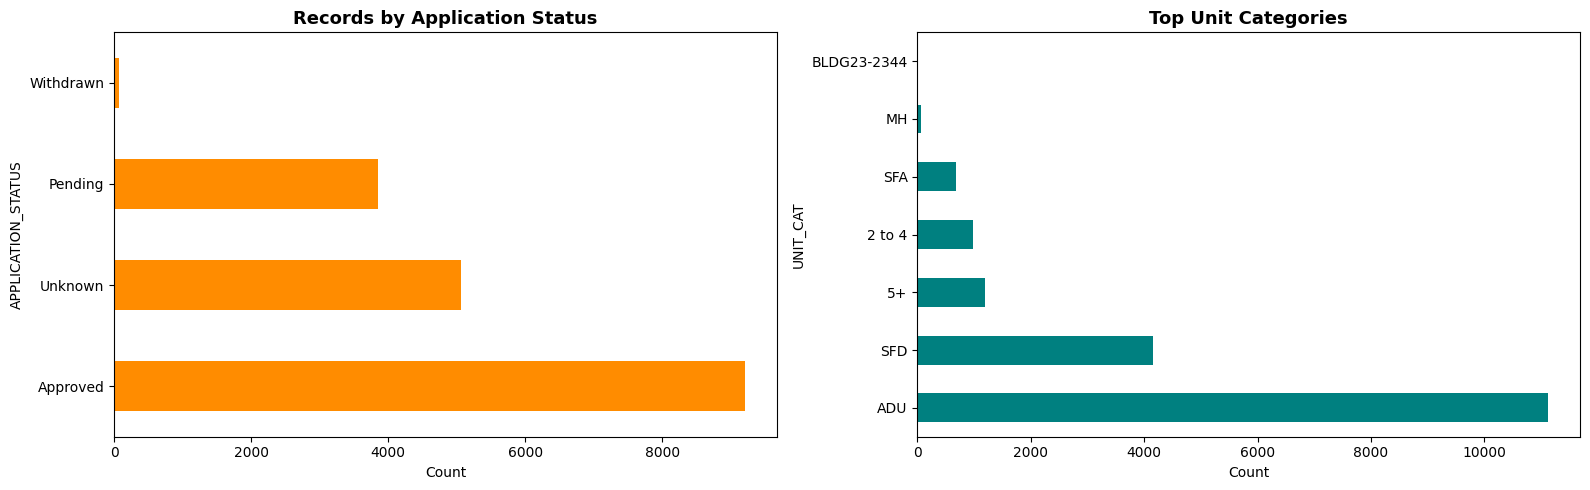

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

apr_df["APPLICATION_STATUS"].value_counts().head(4).plot(kind="barh", ax=axes[0], color="darkorange")
axes[0].set_title("Records by Application Status")
axes[0].set_xlabel("Count")

apr_df["UNIT_CAT"].value_counts().head(8).plot(kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Top Unit Categories")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

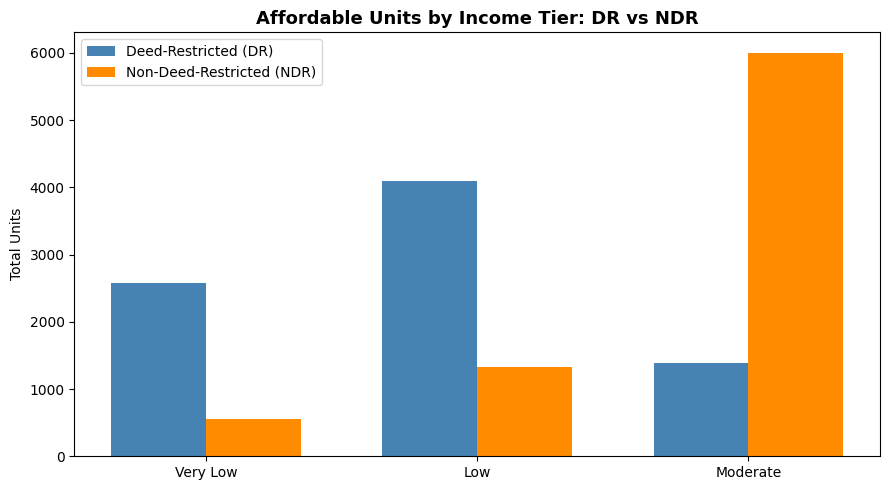

In [ ]:
tiers = ["Very Low", "Low", "Moderate"]
dr_vals  = [apr_df["VLOW_INCOME_DR"].sum(), apr_df["LOW_INCOME_DR"].sum(),  apr_df["MOD_INCOME_DR"].sum()]
ndr_vals = [apr_df["VLOW_INCOME_NDR"].sum(), apr_df["LOW_INCOME_NDR"].sum(), apr_df["MOD_INCOME_NDR"].sum()]

x = np.arange(len(tiers))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, dr_vals,  width, label="Deed-Restricted (DR)",     color="steelblue")
ax.bar(x + width/2, ndr_vals, width, label="Non-Deed-Restricted (NDR)", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(tiers)
ax.set_title("Affordable Units by Income Tier: DR vs NDR")
ax.set_ylabel("Total Units")
ax.legend()
plt.tight_layout()
plt.show()

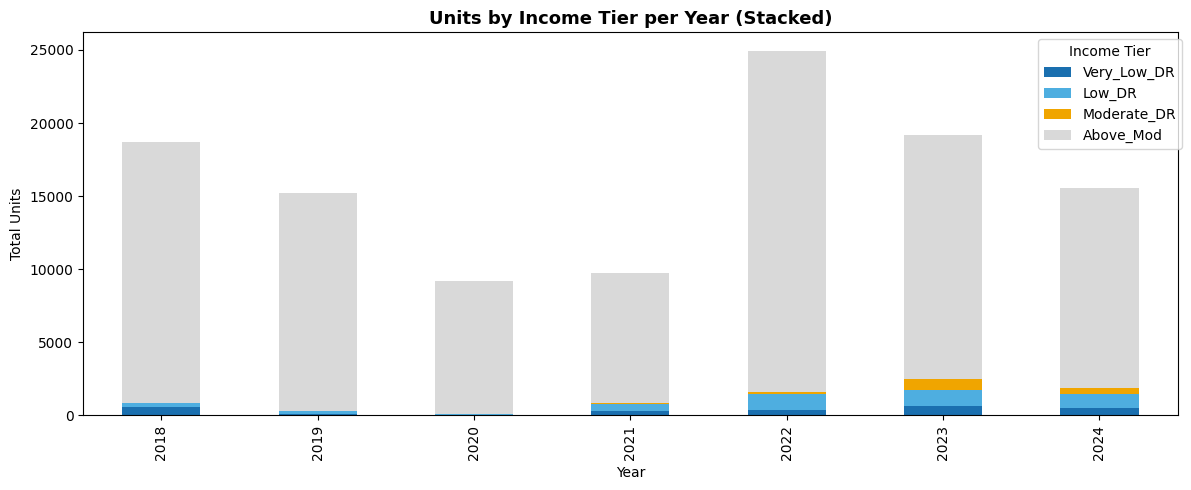

In [ ]:
yearly_tiers = apr_df.groupby("YEAR").agg(
    Very_Low_DR  = ("VLOW_INCOME_DR",  "sum"),
    Low_DR       = ("LOW_INCOME_DR",   "sum"),
    Moderate_DR  = ("MOD_INCOME_DR",   "sum"),
    Above_Mod    = ("ABOVE_MOD_INCOME","sum")
).reset_index()

yearly_tiers.set_index("YEAR")[[
    "Very_Low_DR", "Low_DR", "Moderate_DR", "Above_Mod"
]].plot(
    kind="bar", stacked=True, figsize=(12, 5),
    color=["#1a6faf", "#4eaee0", "#f0a500", "#d9d9d9"]
)
plt.title("Units by Income Tier per Year (Stacked)")
plt.xlabel("Year")
plt.ylabel("Total Units")
plt.legend(title="Income Tier", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

#### 4.6.7 Dataset Takeaways

Above Moderate units accounting for nearly 87% of all proposed units across the reporting period.

Deed-restricted affordable production is thin by comparison. Very Low, Low, and Moderate income DR units combined represent just 6.7% of total proposed units

ADUs dominate the unit category breakdown, comprising over 61% of all permit records
 Single-family detached units account for another 23%, meaning that together ADUs and SFDs represent over 84% of all records despite contributing minimally to deed-restricted affordable supply. The 5+ unit category, which is most likely to carry affordable components, accounts for only 6.6% of records.

## 5. Demand-Side Data Management

### 5.1 ACS Affordability Indicators (B25070, B25071)

#### 5.1.1 Dataset Description

ACS Table **B25070** reports renter households across bins of rent burden, where burden is defined as gross rent as a percentage of household income.

ACS Table **B25071** reports the median gross rent as a percentage of household income.

SOURCES:
- https://data.census.gov/table/ACSDT5Y2024.B25070
- https://data.census.gov/table/ACSDT5Y2024.B25071

- Program : American Community Survey (ACS)
- Universe: Renter-occupied housing units in San Diego County
- Year    : 2024 (5-Year Estimates, 2020-2024)
- Source  : U.S. Census Bureau



### Raw Columns (After API Fetch)

25 columns across 114 San Diego ZCTAs (prior to filtering and feature engineering).

| Column | Source | Description |
|---|---|---|
| `zip_code` | B25070 | 5-digit ZCTA identifier. Renamed to `zip` after cleaning. |
| `total` | B25070_001E | Total renter-occupied housing units in the ZCTA. Universe denominator for all share calculations. |
| `total_moe` | B25070_001M | 90% margin of error for total. |
| `lt_10pct` | B25070_002E | Units where gross rent is less than 10% of household income. |
| `lt_10pct_moe` | B25070_002M | 90% MOE for lt_10pct. |
| `pct_10_14` | B25070_003E | Units where gross rent is 10.0–14.9% of income. |
| `pct_10_14_moe` | B25070_003M | 90% MOE for pct_10_14. |
| `pct_15_19` | B25070_004E | Units where gross rent is 15.0–19.9% of income. |
| `pct_15_19_moe` | B25070_004M | 90% MOE for pct_15_19. |
| `pct_20_24` | B25070_005E | Units where gross rent is 20.0–24.9% of income. |
| `pct_20_24_moe` | B25070_005M | 90% MOE for pct_20_24. |
| `pct_25_29` | B25070_006E | Units where gross rent is 25.0–29.9% of income. Just below the HUD cost-burden threshold. |
| `pct_25_29_moe` | B25070_006M | 90% MOE for pct_25_29. |
| `pct_30_34` | B25070_007E | Units where gross rent is 30.0–34.9% of income. First cost-burdened bracket. |
| `pct_30_34_moe` | B25070_007M | 90% MOE for pct_30_34. |
| `pct_35_39` | B25070_008E | Units where gross rent is 35.0–39.9% of income. |
| `pct_35_39_moe` | B25070_008M | 90% MOE for pct_35_39. |
| `pct_40_49` | B25070_009E | Units where gross rent is 40.0–49.9% of income. |
| `pct_40_49_moe` | B25070_009M | 90% MOE for pct_40_49. |
| `pct_50_plus` | B25070_010E | Units where gross rent is 50.0% or more of income. Severely cost-burdened threshold. |
| `pct_50_plus_moe` | B25070_010M | 90% MOE for pct_50_plus. |
| `not_computed` | B25070_011E | Units where rent-to-income ratio could not be calculated (e.g. zero or negative income). Excluded from share calculations. |
| `not_computed_moe` | B25070_011M | 90% MOE for not_computed. |
| `median_rent_pct_income` | B25071_001E | Median gross rent as a percentage of household income. Single summary statistic per ZCTA. |
| `median_rent_pct_income_moe` | B25071_001M | 90% MOE for median_rent_pct_income. |

### Final Features Produced

| Column | Type | Description |
|---|---|---|
| `zip` | string | 5-digit ZIP code. Primary merge key. |
| `cost_burdened_share` | float64 | Share of renter households paying >= 30% of income on rent (HUD cost-burden threshold). Derived from B25070. |
| `median_rent_pct_income` | float64 | Median gross rent as a percentage of household income per ZIP. Derived from B25071. |
| `median_rel_moe` | float64 | Relative margin of error for the median estimate (MOE / estimate x 100). Used as a data reliability indicator. |

#### 5.1.2 Prior Uses and Existing Analyses

Prior uses of the 2024 verison of this dataset have not been used yet. However, considering the 2023 verison, the data was used in studies and reports on housing.

The California Housing Partnership used this ACS dataset in a San Diego County Housing Analysis report. In summary: San Diego County faces a severe affordable housing shortage, with 134,537 low-income renter households lacking access to an affordable home and renters needing to earn 47.67 dollars per hour (nearly 3x the local minimum wage) to afford the average 2,479 dollars monthly rent. The burden falls hardest on the lowest earners, with 81% of extremely low-income households spending more than half their income on housing. Compounding the crisis, state and federal funding for housing production dropped 13% year-over-year to $631 million, and only 9,226 beds exist to serve the county's homeless population.

SOURCE: https://calhousingpartnership.org/wp-content/uploads/2024/05/San-Diego_Housing_Report-1.pdf

This is one example of how this dataset was used in a similar topic.

#### 5.1.3 Data Collection

We extract ACS tables for San Diego County at the ZIP/ZCTA level, which becomes the main neighborhood-level affordability dataset used downstream in the project.

The ACS API does not support filtering ZCTAs by state/county through the `in=` parameter, so the ZIP-level pull is done for all ZCTAs and then filtered to San Diego ZIP prefixes.

In [ ]:
CENSUS_API = "https://api.census.gov/data"
ACS_YEAR = 2024 #2025-26 doesn't work
ACS_DATASET = "acs/acs5" # 5-year ACS
BASE = f"{CENSUS_API}/{ACS_YEAR}/{ACS_DATASET}"

In [122]:
def acs_group(group, geo):
    params = {"get": f"group({group})", **geo}
    data = requests.get(BASE, params=params, timeout=60)
    data.raise_for_status()
    rows = data.json()
    cols = rows[0]
    out = pd.DataFrame(rows[1:], columns=cols)
    return out

def coerce_estimates_only(df):
    out = df.copy()
    est_cols = [c for c in out.columns if c.endswith("E") and not c.endswith("EA")]
    for c in est_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    return out

def fetch_acs_zcta(variables, table_label):
    print(f"Fetching {table_label}...")

    var_items = list(variables.items())
    chunks = [dict(var_items[i:i+10]) for i in range(0, len(var_items), 10)]

    dfs = []
    for i, chunk in enumerate(chunks):
        var_str = ",".join(["NAME"] + list(chunk.keys()))
        url = f"{BASE}?get={var_str}&for=zip%20code%20tabulation%20area:*"

        r = requests.get(url, timeout=60)
        r.raise_for_status()

        data = r.json()
        df_chunk = pd.DataFrame(data[1:], columns=data[0])
        df_chunk = df_chunk.rename(columns=chunk)
        df_chunk = df_chunk.rename(columns={"zip code tabulation area": "zip"})
        df_chunk = df_chunk.drop(columns=["NAME", "state"], errors="ignore")

        num_cols = list(chunk.values())
        df_chunk[num_cols] = df_chunk[num_cols].apply(pd.to_numeric, errors="coerce")
        dfs.append(df_chunk)

        print(f"  Chunk {i+1}/{len(chunks)} done")

    df = dfs[0]
    for df_next in dfs[1:]:
        df = df.merge(df_next, on="zip", how="left")

    return df

def load_or_fetch_acs_group(group, geo, filename):
    filepath = f"data/{filename}"
    if os.path.exists(filepath):
        print(f"Loading cached {group} from {filepath}...")
        dtypes = {"state": "string", "county": "string", "tract": "string"}
        return pd.read_csv(filepath, dtype=dtypes)
    else:
        print(f"Fetching {group} from API...")
        df = acs_group(group, geo)
        df.to_csv(filepath, index=False)
        return df

def load_or_fetch_acs_zcta(variables, table_label, filename):
    filepath = f"data/{filename}"
    if os.path.exists(filepath):
        print(f"Loading cached {table_label} from {filepath}...")
        return pd.read_csv(filepath, dtype={"zip": "string"})
    else:
        df = fetch_acs_zcta(variables, table_label)
        df.to_csv(filepath, index=False)
        return df

In [123]:
geo_county = {"for": "county:073", "in": "state:06"}
b25070_county_raw = load_or_fetch_acs_group("B25070", geo_county, "b25070_county_raw.csv")
b25071_county_raw = load_or_fetch_acs_group("B25071", geo_county, "b25071_county_raw.csv")

b25070_county = coerce_estimates_only(b25070_county_raw)
b25071_county = coerce_estimates_only(b25071_county_raw)

geo_tract = {"for": "tract:*", "in": "state:06 county:073"}
b25070_tract_raw = load_or_fetch_acs_group("B25070", geo_tract, "b25070_tract_raw.csv")
b25071_tract_raw = load_or_fetch_acs_group("B25071", geo_tract, "b25071_tract_raw.csv")

b25070_tract = coerce_estimates_only(b25070_tract_raw)
b25071_tract = coerce_estimates_only(b25071_tract_raw)

Loading cached B25070 from data/b25070_county_raw.csv...
Loading cached B25071 from data/b25071_county_raw.csv...
Loading cached B25070 from data/b25070_tract_raw.csv...
Loading cached B25071 from data/b25071_tract_raw.csv...


#### 5.1.4 Cleaning and Preprocessing

At the ZIP/ZCTA level, we retain the full burden distribution from B25070, merge it with the B25071 median burden estimate, and then construct neighborhood-level affordability features. We also carry forward a small number of data-quality indicators, including the “not computed” share and the relative margin of error for the median estimate.

Because some ZCTAs correspond to military bases, universities, or sparsely populated areas with zero renter-occupied units, these observations are dropped before final feature construction.

In [124]:
# B25070 definitions
TOTAL = "B25070_001E"

# 30-34.9%, 35-39.9%, 40-49.9%, 50.0% or more
BURDEN_30P = ["B25070_006E", "B25070_007E", "B25070_008E", "B25070_009E"]

# 50.0% or more
SEVERE_50P = ["B25070_009E"]

# optional reference only
NOT_COMPUTED = "B25070_011E"

needed = [TOTAL, *BURDEN_30P, *SEVERE_50P]
missing = [c for c in needed if c not in b25070_county.columns]
print("Missing expected columns:", missing)

Missing expected columns: []


In [125]:
total = float(b25070_county.loc[0, TOTAL])
burden_30 = float(b25070_county.loc[0, BURDEN_30P].sum())
severe_50 = float(b25070_county.loc[0, SEVERE_50P].sum())

county_summary = pd.DataFrame([{
    "acs_year": ACS_YEAR,
    "total_renter_units": total,
    "cost_burdened_30p_units": burden_30,
    "severely_burdened_50p_units": severe_50,
    "cost_burdened_30p_share": burden_30 / total if total else np.nan,
    "severely_burdened_50p_share": severe_50 / total if total else np.nan,
    "median_rent_pct_income": float(b25071_county.loc[0, "B25071_001E"])
}])

county_summary

,acs_year,total_renter_units,cost_burdened_30p_units,severely_burdened_50p_units,cost_burdened_30p_share,severely_burdened_50p_share,median_rent_pct_income
0,2024,532140.0,205173.0,53392.0,0.385562,0.100334,33.9


In [127]:
B25070_VARS = {
    "B25070_001E": "total",
    "B25070_001M": "total_moe",
    "B25070_002E": "lt_10pct",
    "B25070_002M": "lt_10pct_moe",
    "B25070_003E": "pct_10_14",
    "B25070_003M": "pct_10_14_moe",
    "B25070_004E": "pct_15_19",
    "B25070_004M": "pct_15_19_moe",
    "B25070_005E": "pct_20_24",
    "B25070_005M": "pct_20_24_moe",
    "B25070_006E": "pct_25_29",
    "B25070_006M": "pct_25_29_moe",
    "B25070_007E": "pct_30_34",
    "B25070_007M": "pct_30_34_moe",
    "B25070_008E": "pct_35_39",
    "B25070_008M": "pct_35_39_moe",
    "B25070_009E": "pct_40_49",
    "B25070_009M": "pct_40_49_moe",
    "B25070_010E": "pct_50_plus",
    "B25070_010M": "pct_50_plus_moe",
    "B25070_011E": "not_computed",
    "B25070_011M": "not_computed_moe",
}

B25071_VARS = {
    "B25071_001E": "median_rent_pct_income",
    "B25071_001M": "median_rent_pct_income_moe",
}

df_b25070 = load_or_fetch_acs_zcta(B25070_VARS, "B25070 (rent burden distribution)", "b25070_zcta_raw.csv")
df_b25071 = load_or_fetch_acs_zcta(B25071_VARS, "B25071 (median rent-to-income)", "b25071_zcta_raw.csv")

rent_burden_zip_df = df_b25070.merge(df_b25071, on="zip", how="left")
rent_burden_zip_df["zip"] = rent_burden_zip_df["zip"].astype("string")

Loading cached B25070 (rent burden distribution) from data/b25070_zcta_raw.csv...
Loading cached B25071 (median rent-to-income) from data/b25071_zcta_raw.csv...


#### 5.1.5 Neighborhood Aggregation

In [128]:
# Build shares
b25070_tract["total"] = b25070_tract[TOTAL]
b25070_tract["burden_30p"] = b25070_tract[BURDEN_30P].sum(axis=1)
b25070_tract["severe_50p"] = b25070_tract[SEVERE_50P].sum(axis=1)

b25070_tract["burden_30p_share"] = b25070_tract["burden_30p"] / b25070_tract["total"]
b25070_tract["severe_50p_share"] = b25070_tract["severe_50p"] / b25070_tract["total"]

# Merge median rent % income
b25071_tract = b25071_tract.rename(columns={"B25071_001E": "median_rent_pct_income"})
acs_tract = b25070_tract.merge(
    b25071_tract[["state","county","tract", "median_rent_pct_income"]],
    on=["state","county","tract"],
    how="left"
)

acs_tract.head()

,Unnamed: 0,B25070_001E,B25070_001EA,B25070_001M,B25070_001MA,B25070_002E,B25070_002EA,B25070_002M,B25070_002MA,B25070_003E,...,NAME,state,county,tract,total,burden_30p,severe_50p,burden_30p_share,severe_50p_share,median_rent_pct_income
0,0,111,NaN,76,NaN,0,NaN,14,NaN,0,...,NaN,06,073,000100,111,17,0,0.153153,0.000000,23.1
1,1,646,NaN,108,NaN,8,NaN,11,NaN,16,...,NaN,06,073,000201,646,337,63,0.521672,0.097523,29.2
2,2,1237,NaN,262,NaN,0,NaN,14,NaN,270,...,NaN,06,073,000202,1237,491,101,0.396928,0.081649,26.5
3,3,957,NaN,188,NaN,49,NaN,46,NaN,107,...,NaN,06,073,000301,957,290,33,0.303030,0.034483,27.4
4,4,1317,NaN,209,NaN,0,NaN,14,NaN,102,...,NaN,06,073,000302,1317,450,141,0.341686,0.107062,35.6


In [129]:
# Filter to San Diego County ZIP-like prefixes
SD_ZIP_PREFIXES = ("919", "920", "921")
rent_burden_zip_df = (
    rent_burden_zip_df[rent_burden_zip_df["zip"].str.startswith(SD_ZIP_PREFIXES)]
    .reset_index(drop=True)
)

# Feature engineering with correct burden bins
burdened_cols = ["pct_30_34", "pct_35_39", "pct_40_49", "pct_50_plus"]

rent_burden_zip_df["cost_burdened_count"] = rent_burden_zip_df[burdened_cols].sum(axis=1)
rent_burden_zip_df["cost_burdened_share"] = rent_burden_zip_df["cost_burdened_count"] / rent_burden_zip_df["total"]
rent_burden_zip_df["severely_burdened_share"] = rent_burden_zip_df["pct_50_plus"] / rent_burden_zip_df["total"]

rent_burden_zip_df["not_computed_share"] = rent_burden_zip_df["not_computed"] / rent_burden_zip_df["total"]
rent_burden_zip_df["data_quality_flag"] = rent_burden_zip_df["not_computed_share"] > 0.10

rent_burden_zip_df["median_rent_pct_income"] = (
    rent_burden_zip_df["median_rent_pct_income"].replace(-666666666.0, np.nan)
)
rent_burden_zip_df["median_rel_moe"] = (
    rent_burden_zip_df["median_rent_pct_income_moe"] /
    rent_burden_zip_df["median_rent_pct_income"] * 100
)

# Drop zero-renter and suppressed-median ZIPs
rent_burden_zip_df = rent_burden_zip_df[
    (rent_burden_zip_df["total"] > 0)
].copy()

rent_burden_zip_features = rent_burden_zip_df[[
    "zip",
    "cost_burdened_share",
    "severely_burdened_share",
    "median_rent_pct_income",
    "median_rel_moe",
    "not_computed_share"
]].dropna().reset_index(drop=True)

print("Final ZIP-level affordability dataset shape:", rent_burden_zip_features.shape)
rent_burden_zip_features.head()

Final ZIP-level affordability dataset shape: (93, 6)


,zip,cost_burdened_share,severely_burdened_share,median_rent_pct_income,median_rel_moe,not_computed_share
0,91901,0.507808,0.260462,32.8,19.207317,0.091818
1,91902,0.536885,0.178962,33.2,31.024096,0.087432
2,91905,0.593220,0.000000,31.0,112.258065,0.033898
3,91906,0.469636,0.242915,42.2,70.142180,0.178138
4,91910,0.575871,0.317964,34.8,6.609195,0.035897


In [130]:
acs_map_gdf = sd_zcta_named_gdf.merge(
    rent_burden_zip_features,
    on="zip",
    how="left"
)

total_map_zips = len(acs_map_gdf)
zips_with_data = acs_map_gdf['cost_burdened_share'].notna().sum()
zips_missing = acs_map_gdf['cost_burdened_share'].isna().sum()

print(f"Total ZIPs in San Diego map: {total_map_zips}")
print(f"ZIPs matching ACS records: {zips_with_data}")
print(f"ZIPs missing ACS records (dropped zeros/rural): {zips_missing}")

acs_map_gdf.to_file("data/acs_affordability_aggregated_gdf.geojson", driver="GeoJSON")


Total ZIPs in San Diego map: 116
ZIPs matching ACS records: 93
ZIPs missing ACS records (dropped zeros/rural): 23


#### 5.1.6 Exploratory Data Analysis

In [131]:
acs_tract[[
    "burden_30p_share",
    "severe_50p_share",
    "median_rent_pct_income"
]].describe()

,burden_30p_share,severe_50p_share,median_rent_pct_income
count,732.000000,732.000000,7.370000e+02
mean,0.370726,0.096972,-9.045647e+06
std,0.145262,0.076853,7.717974e+07
min,0.000000,0.000000,-6.666667e+08
25%,0.283468,0.041020,2.830000e+01
50%,0.371288,0.085793,3.330000e+01
75%,0.461937,0.136003,3.860000e+01
max,1.000000,0.421053,5.100000e+01


In [132]:
# Top 10 tracts by severe burden
top_severe = (
    acs_tract.dropna(subset=["severe_50p_share"])
    .sort_values("severe_50p_share", ascending=False)
    .head(10)
)

top_severe[["NAME", "total", "severe_50p_share", "median_rent_pct_income"]]

,NAME,total,severe_50p_share,median_rent_pct_income
448,NaN,171,0.421053,40.1
659,NaN,161,0.397516,38.0
60,NaN,262,0.389313,41.9
451,NaN,561,0.377897,45.6
75,NaN,227,0.374449,48.1
362,NaN,201,0.368159,42.6
420,NaN,178,0.359551,40.9
299,NaN,194,0.355670,38.0
519,NaN,50,0.340000,41.8
69,NaN,175,0.325714,36.8


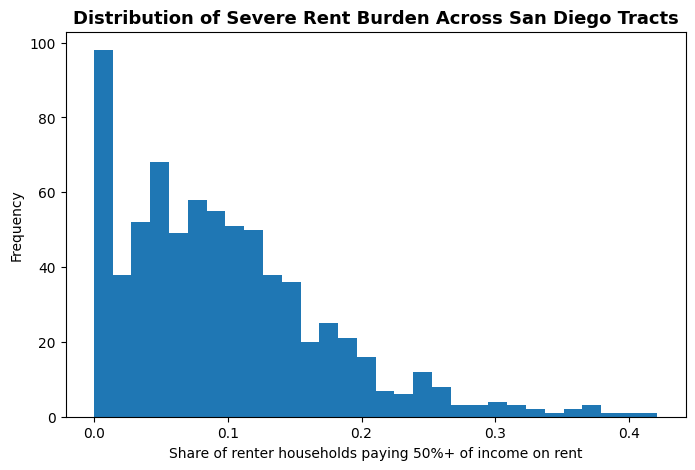

In [133]:
ax = acs_tract["severe_50p_share"].dropna().plot(
    kind="hist",
    bins=30,
    figsize=(8, 5)
)
ax.set_title("Distribution of Severe Rent Burden Across San Diego Tracts")
ax.set_xlabel("Share of renter households paying 50%+ of income on rent")
plt.show()

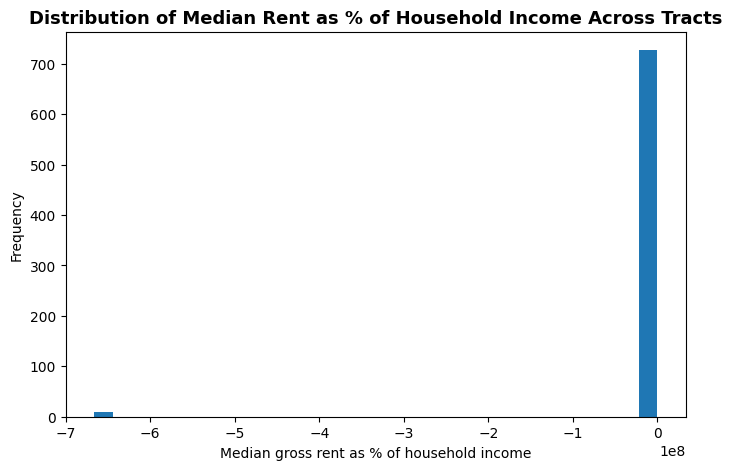

In [134]:
ax = acs_tract["median_rent_pct_income"].dropna().plot(
    kind="hist",
    bins=30,
    figsize=(8, 5)
)
ax.set_title("Distribution of Median Rent as % of Household Income Across Tracts")
ax.set_xlabel("Median gross rent as % of household income")
plt.show()

In [135]:
acs_tract["GEOID"] = acs_tract["state"] + acs_tract["county"] + acs_tract["tract"]

acs_tract_map_gdf = sd_tract_gdf.merge(
    acs_tract[["GEOID", "burden_30p_share", "severe_50p_share", "median_rent_pct_income"]],
    on="GEOID",
    how="left"
)

acs_tract_map_gdf.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,GEOIDFQ,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,burden_30p_share,severe_50p_share,median_rent_pct_income
0,06,073,008331,06073008331,1400000US06073008331,83.31,Census Tract 83.31,G5020,S,954207,0,+32.9426037,-117.2241058,"POLYGON ((-117.23082 32.94176, -117.23079 32.9...",0.521277,0.000000,28.2
1,06,073,008336,06073008336,1400000US06073008336,83.36,Census Tract 83.36,G5020,S,828562,0,+32.9678415,-117.1331584,"POLYGON ((-117.13793 32.96927, -117.13792 32.9...",0.340909,0.000000,23.8
2,06,073,008337,06073008337,1400000US06073008337,83.37,Census Tract 83.37,G5020,S,1572597,0,+32.9583797,-117.1358284,"POLYGON ((-117.14678 32.95497, -117.14657 32.9...",0.511401,0.022801,27.9
3,06,073,011601,06073011601,1400000US06073011601,116.01,Census Tract 116.01,G5020,S,733715,0,+32.6663314,-117.0964015,"POLYGON ((-117.10356 32.6672, -117.10314 32.66...",0.269655,0.087436,25.0
4,06,073,011602,06073011602,1400000US06073011602,116.02,Census Tract 116.02,G5020,S,1005857,13822,+32.6599903,-117.0941732,"POLYGON ((-117.10154 32.66202, -117.10133 32.6...",0.184211,0.025063,23.9


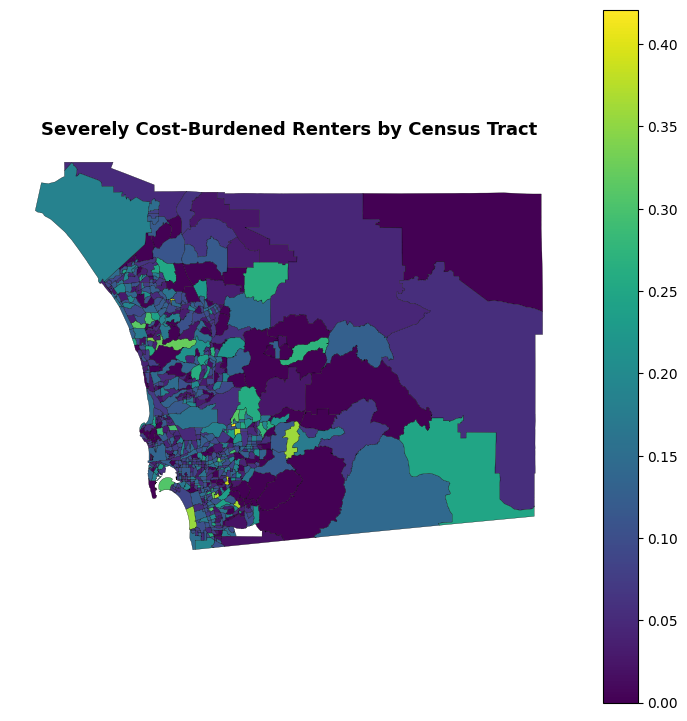

In [136]:
ax = acs_tract_map_gdf.to_crs("EPSG:3857").plot(
    column="severe_50p_share",
    figsize=(9, 9),
    legend=True,
    edgecolor="black",
    linewidth=0.2
)
ax.set_title("Severely Cost-Burdened Renters by Census Tract")
ax.set_axis_off()
plt.show()

Distribution of the 3 Chosen Features

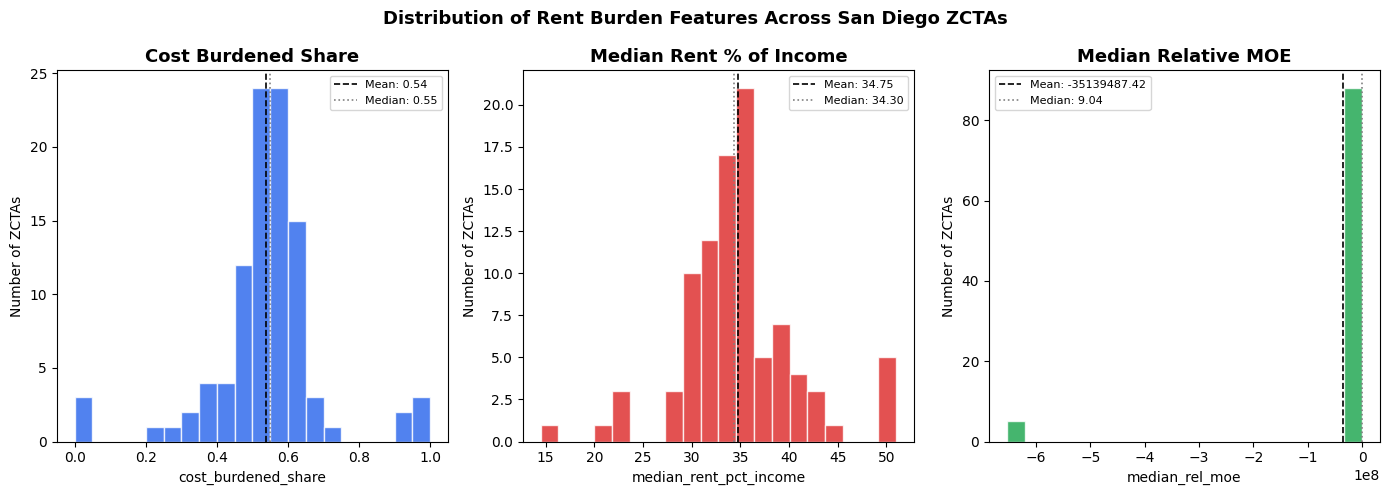

In [141]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Distribution of Rent Burden Features Across San Diego ZCTAs",
             fontweight="bold", fontsize=13)

features = ["cost_burdened_share", "median_rent_pct_income", "median_rel_moe"]
titles = ["Cost Burdened Share", "Median Rent % of Income", "Median Relative MOE"]
colors = ["#2563eb", "#dc2626", "#16a34a"]

for ax, feat, title, color in zip(axes, features, titles, colors):
    data = rent_burden_zip_df[feat].dropna()
    ax.hist(data, bins=20, color=color, alpha=0.8, edgecolor="white")
    ax.axvline(data.mean(), color="black", linestyle="--", linewidth=1.2, label=f"Mean: {data.mean():.2f}")
    ax.axvline(data.median(), color="gray", linestyle=":", linewidth=1.2, label=f"Median: {data.median():.2f}")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Number of ZCTAs")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

The Most & Least Burden Zip Codes

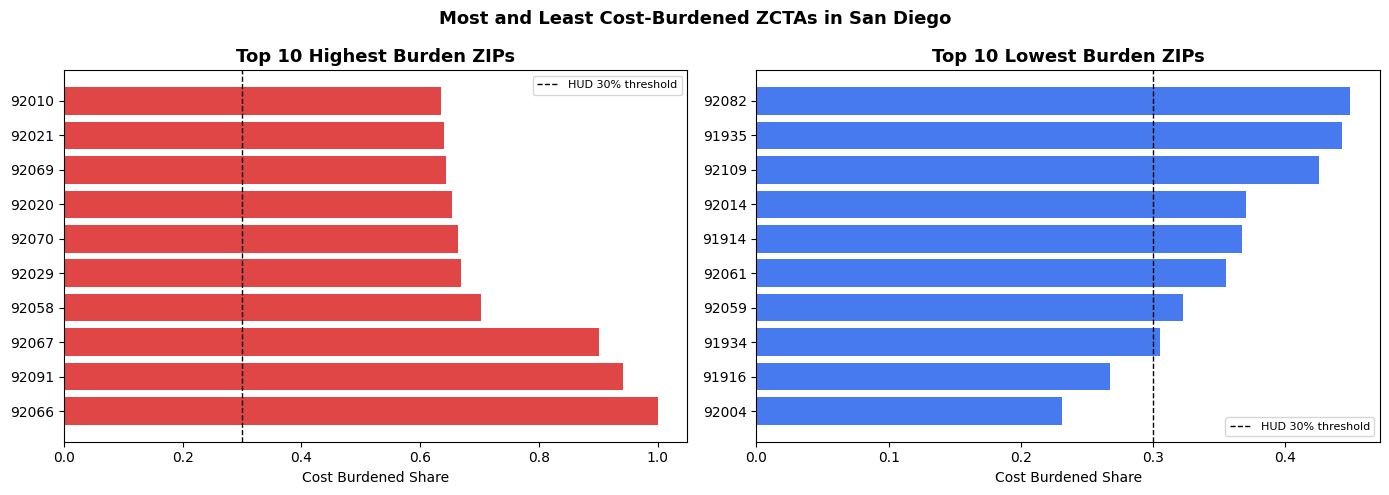


🔴 Highest Cost-Burdened ZIPs:
  zip  cost_burdened_share  median_rent_pct_income
92066             1.000000                    51.0
92091             0.941489                    51.0
92067             0.901163                    33.5
92058             0.703141                    44.9
92029             0.669044                    34.6
92070             0.663265                    36.0
92020             0.654429                    39.5
92069             0.644211                    38.4
92021             0.640083                    42.6
92010             0.634888                    39.4

🔵 Lowest Cost-Burdened ZIPs:
  zip  cost_burdened_share  median_rent_pct_income
92004             0.230916                    14.5
91916             0.267176                    30.0
91934             0.305344                    42.4
92059             0.322917                    22.9
92061             0.355263                    20.5
91914             0.366982                    22.0
92014             0.3

In [142]:
# Top 10 / Bottom 10 ZIPs by cost burden
top10 = rent_burden_zip_features.nlargest(10, "cost_burdened_share")[["zip", "cost_burdened_share", "median_rent_pct_income"]]
bot10 = rent_burden_zip_features.nsmallest(10, "cost_burdened_share")[["zip", "cost_burdened_share", "median_rent_pct_income"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Most and Least Cost-Burdened ZCTAs in San Diego", fontweight="bold", fontsize=13)

axes[0].barh(top10["zip"].astype(str), top10["cost_burdened_share"], color="#dc2626", alpha=0.85)
axes[0].set_title("Top 10 Highest Burden ZIPs", fontweight="bold")
axes[0].set_xlabel("Cost Burdened Share")
axes[0].axvline(0.3, color="black", linestyle="--", linewidth=1, label="HUD 30% threshold")
axes[0].legend(fontsize=8)

axes[1].barh(bot10["zip"].astype(str), bot10["cost_burdened_share"], color="#2563eb", alpha=0.85)
axes[1].set_title("Top 10 Lowest Burden ZIPs", fontweight="bold")
axes[1].set_xlabel("Cost Burdened Share")
axes[1].axvline(0.3, color="black", linestyle="--", linewidth=1, label="HUD 30% threshold")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\n🔴 Highest Cost-Burdened ZIPs:")
print(top10.to_string(index=False))
print("\n🔵 Lowest Cost-Burdened ZIPs:")
print(bot10.to_string(index=False))

#### 5.1.7 Dataset Takeaways

The tract-level EDA shows that affordability pressure is not evenly distributed across San Diego County. Some tracts exhibit especially high levels of severe rent burden, while others have substantially lower burden.

Across 93 San Diego ZCTAs, rent burden is the norm rather than the exception,
with the majority of neighborhoods exceeding the HUD 30% cost-burden threshold.
The most severely burdened ZIP is 92066 (Ranchita) with 100% of renters
cost-burdened and a median rent-to-income ratio of 51%, followed closely by
92091 (Rancho Santa Fe) at 94%. On the other end, 92004 (Borrego Springs)
and 91914 (Eastlake/Chula Vista) show the lowest burden shares at 23% and 37%
respectively, with median ratios as low as 14.5% to 22%, reflecting more
income-proportionate rental markets. These three features (cost burdened share,
median rent-to-income ratio, and relative MOE) form a compact and reliable
signal of neighborhood-level affordability pressure for the index.

### 5.2 Population Data

**Assigned to: Dylan Craver**

**Source:** SANDAG 2010 Census — Population by Sex by ZIP Code
(`https://opendata.sandag.org/Census/2010-Census-Population-by-Sex-by-ZIP-Code/g4gy-f4e8/about_data`)

Population data provides the foundational denominator for the affordability mismatch analysis.
Without knowing how many people live in each ZIP, raw counts of cost-burdened households,
permits, and STRO licenses are not comparable across neighborhoods of different sizes.
This section loads, cleans, and explores the SANDAG ZIP-level population dataset,
producing `pop_total`, `pop_male`, `pop_female`, `sex_ratio`, and `pop_density_per_km2`
at the ZIP level for use in the unified neighborhood dataset (Section 6).

#### 5.2.1 Dataset Description

**Source:** SANDAG Open Data Portal — 2010 Census Population by Sex by ZIP Code
- Dataset ID: `g4gy-f4e8`
- API endpoint: `https://opendata.sandag.org/resource/g4gy-f4e8.json`
- Geographic unit: **ZIP code** — joins directly to `sd_zcta_gdf` with no crosswalk needed
- Structure: long format — one row per ZIP × year × sex category
- Key columns: `zip`, `yr_id` (year), `name` (sex: Male / Female / Total), `population`

**Key derived variables:**
- `pop_total` — total population per ZIP
- `pop_male` / `pop_female` — sex breakdown per ZIP
- `sex_ratio` — male-to-female ratio (derived)
- `pop_density_per_km2` — population per km² (derived using ZCTA polygon area)

#### 5.2.2 Prior Uses and Existing Analyses

SANDAG is the official Regional Census Data Center for San Diego County and maintains
a complete inventory of 2010 Census data for the region. This dataset is used by SANDAG
internally for Regional Housing Needs Assessment (RHNA) allocations, infrastructure
planning, and equity analyses. The SD County Equity Report uses the same ZIP-level
population denominators to normalize service access and burden metrics — the same
normalization approach we apply in Section 6 when constructing the mismatch index.

#### 5.2.3 Data Collection

In [ ]:
# ── SANDAG 2010 Census: Population by Sex by ZIP ──────────────────────────────
# Source: https://opendata.sandag.org/Census/2010-Census-Population-by-Sex-by-ZIP-Code/g4gy-f4e8

SANDAG_POP_URL = "https://opendata.sandag.org/resource/g4gy-f4e8.json"

resp = requests.get(SANDAG_POP_URL, params={"$limit": 50000})
resp.raise_for_status()
sandag_pop_raw = pd.DataFrame(resp.json())

print(f"Shape: {sandag_pop_raw.shape}")
print(f"Columns: {sandag_pop_raw.columns.tolist()}")
print(f"Unique yr_id values: {sorted(sandag_pop_raw['yr_id'].unique())}")
print(f"Unique sex categories: {sandag_pop_raw['sex'].unique()}")
sandag_pop_raw.head(10)

Shape: (226, 4)
Columns: ['zip', 'yr_id', 'sex', 'population']
Unique yr_id values: ['2010']
Unique sex categories: ['Female' 'Male']


,zip,yr_id,sex,population
0,91901,2010,Female,8473
1,91901,2010,Male,8611
2,91902,2010,Female,8860
3,91902,2010,Male,8145
4,91905,2010,Female,1000
5,91905,2010,Male,669
6,91906,2010,Female,2834
7,91906,2010,Male,2931
8,91910,2010,Female,39139
9,91910,2010,Male,37014


#### 5.2.4 Cleaning and Preprocessing

In [ ]:
# ── Standardize types and column names ───────────────────────────────────────
sandag_pop = sandag_pop_raw.copy()
sandag_pop.columns = sandag_pop.columns.str.strip().str.lower()

sandag_pop["population"] = pd.to_numeric(sandag_pop["population"], errors="coerce")
sandag_pop["yr_id"]      = pd.to_numeric(sandag_pop["yr_id"],      errors="coerce")
sandag_pop["zip"]        = sandag_pop["zip"].astype("string").str.zfill(5)
sandag_pop["sex"]        = sandag_pop["sex"].astype("string").str.strip().str.title()

print("Missing values:")
print(sandag_pop.isnull().sum())
print(f"\nYear range: {sandag_pop['yr_id'].min()} – {sandag_pop['yr_id'].max()}")
print(f"Unique ZIPs: {sandag_pop['zip'].nunique()}")
sandag_pop.head(10)

Missing values:
zip           0
yr_id         0
sex           0
population    0
dtype: int64

Year range: 2010 – 2010
Unique ZIPs: 113


,zip,yr_id,sex,population
0,91901,2010,Female,8473
1,91901,2010,Male,8611
2,91902,2010,Female,8860
3,91902,2010,Male,8145
4,91905,2010,Female,1000
5,91905,2010,Male,669
6,91906,2010,Female,2834
7,91906,2010,Male,2931
8,91910,2010,Female,39139
9,91910,2010,Male,37014


In [ ]:
# ── Filter to 2010 and pivot sex → columns ────────────────────────────────────
pop_2010 = sandag_pop[sandag_pop["yr_id"] == 2010].copy()
print(f"2010 rows: {len(pop_2010)}  |  unique ZIPs: {pop_2010['zip'].nunique()}")

# Pivot: each row = one ZIP, columns = Male / Female / Total
pop_pivot = (
    pop_2010
    .pivot_table(index="zip", columns="sex", values="population", aggfunc="sum")
    .reset_index()
)
pop_pivot.columns.name = None

# Normalize column names
pop_pivot.columns = [
    "zip"        if c == "zip"
    else "pop_male"   if "male"   in c.lower() and "female" not in c.lower()
    else "pop_female" if "female" in c.lower()
    else "pop_total"  if "total"  in c.lower()
    else c.lower().replace(" ", "_")
    for c in pop_pivot.columns
]

# Derive pop_total if not present
if "pop_total" not in pop_pivot.columns:
    pop_pivot["pop_total"] = pop_pivot.get("pop_male", 0) + pop_pivot.get("pop_female", 0)
    print("pop_total derived from male + female")

# Drop zero/null population ZIPs
before = len(pop_pivot)
pop_pivot = pop_pivot[pop_pivot["pop_total"] > 0].dropna(subset=["pop_total"]).copy()
print(f"Dropped {before - len(pop_pivot)} zero/null ZIPs")
print(f"Clean shape: {pop_pivot.shape}")
pop_pivot.head()

2010 rows: 226  |  unique ZIPs: 113
pop_total derived from male + female
Dropped 2 zero/null ZIPs
Clean shape: (111, 4)


,zip,pop_female,pop_male,pop_total
0,91901,8473,8611,17084
1,91902,8860,8145,17005
2,91905,1000,669,1669
3,91906,2834,2931,5765
4,91910,39139,37014,76153


In [ ]:
# ── Derive sex ratio ──────────────────────────────────────────────────────────
pop_pivot["sex_ratio"] = pop_pivot["pop_male"] / pop_pivot["pop_female"]

print("Duplicates:", pop_pivot.duplicated(subset="zip").sum())
print("\nMissing values:")
print(pop_pivot.isnull().sum())
pop_pivot.describe().round(1)

Duplicates: 0

Missing values:
zip           0
pop_female    0
pop_male      0
pop_total     0
sex_ratio     0
dtype: int64


,pop_female,pop_male,pop_total,sex_ratio
count,111.0,111.0,111.0,111.0
mean,13888.6,13997.1,27885.7,2.2
std,11159.8,10928.4,21999.7,11.5
min,2.0,0.0,2.0,0.0
25%,2011.0,3169.0,5059.5,0.9
50%,13116.0,13332.0,26343.0,1.0
75%,22639.5,23025.0,46062.0,1.0
max,42678.0,41229.0,83249.0,121.7


#### 5.2.5 Neighborhood Aggregation

The SANDAG dataset is already at ZIP level — no spatial join is needed.
We filter to San Diego County ZIPs using `sd_zcta_gdf` and derive
`pop_density_per_km2` using ZCTA polygon areas.

In [ ]:
# ── Filter to SD County ZIPs and compute density ──────────────────────────────
sd_zips = sd_zcta_named_gdf["zip"].astype("string").unique()
pop_zip = pop_pivot[pop_pivot["zip"].isin(sd_zips)].copy()

print(f"ZIPs in SANDAG data:            {len(pop_pivot)}")
print(f"ZIPs matched to SD County:      {len(pop_zip)}")
print(f"ZIPs outside county (dropped):  {len(pop_pivot) - len(pop_zip)}")

# Compute ZIP area from ZCTA geometry
zcta_area = sd_zcta_named_gdf[["zip", "geometry"]].copy()
zcta_area["zip"] = zcta_area["zip"].astype("string")
zcta_area["zip_area_km2"] = zcta_area.to_crs("EPSG:3857").geometry.area / 1e6

pop_zip = pop_zip.merge(zcta_area[["zip", "zip_area_km2"]], on="zip", how="left")
pop_zip["pop_density_per_km2"] = pop_zip["pop_total"] / pop_zip["zip_area_km2"]

print(f"\nFinal pop_zip shape: {pop_zip.shape}")
print(f"Columns: {pop_zip.columns.tolist()}")
pop_zip.sort_values("pop_total", ascending=False).head(10)

ZIPs in SANDAG data:            111
ZIPs matched to SD County:      110
ZIPs outside county (dropped):  1

Final pop_zip shape: (110, 7)
Columns: ['zip', 'pop_female', 'pop_male', 'pop_total', 'sex_ratio', 'zip_area_km2', 'pop_density_per_km2']


,zip,pop_female,pop_male,pop_total,sex_ratio,zip_area_km2,pop_density_per_km2
5,91911,42678,40571,83249,0.950630,46.902805,1774.925844
105,92154,38004,41229,79233,1.084859,189.972916,417.075243
4,91910,39139,37014,76153,0.945706,52.230251,1458.024781
93,92126,34512,38525,73037,1.116278,42.697081,1710.585316
74,92105,35576,34694,70270,0.975208,21.204505,3313.918395
82,92114,33352,32081,65433,0.961891,30.404272,2152.098877
35,92021,33434,31793,65227,0.950918,103.793740,628.429037
22,91977,30355,28809,59164,0.949069,38.307473,1544.450620
34,92020,29663,28744,58407,0.969019,40.857687,1429.522937
83,92115,27847,28847,56694,1.035911,22.658816,2502.072436


#### 5.2.6 Exploratory Data Analysis

In [ ]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("=== ZIP-level population summary ===")
pop_zip[["pop_total", "pop_male", "pop_female",
         "sex_ratio", "pop_density_per_km2"]].describe().round(2)

=== ZIP-level population summary ===


,pop_total,pop_male,pop_female,sex_ratio,pop_density_per_km2
count,110.00,110.00,110.00,110.00,110.00
mean,28135.89,14122.92,14012.97,2.21,919.79
std,21941.22,10897.38,11133.34,11.51,925.10
min,2.00,0.00,2.00,0.00,0.05
25%,5953.75,3517.50,2063.50,0.95,105.35
50%,26636.00,13438.50,13285.50,0.98,701.32
75%,46192.00,23039.00,22982.25,1.03,1450.90
max,83249.00,41229.00,42678.00,121.68,4226.32


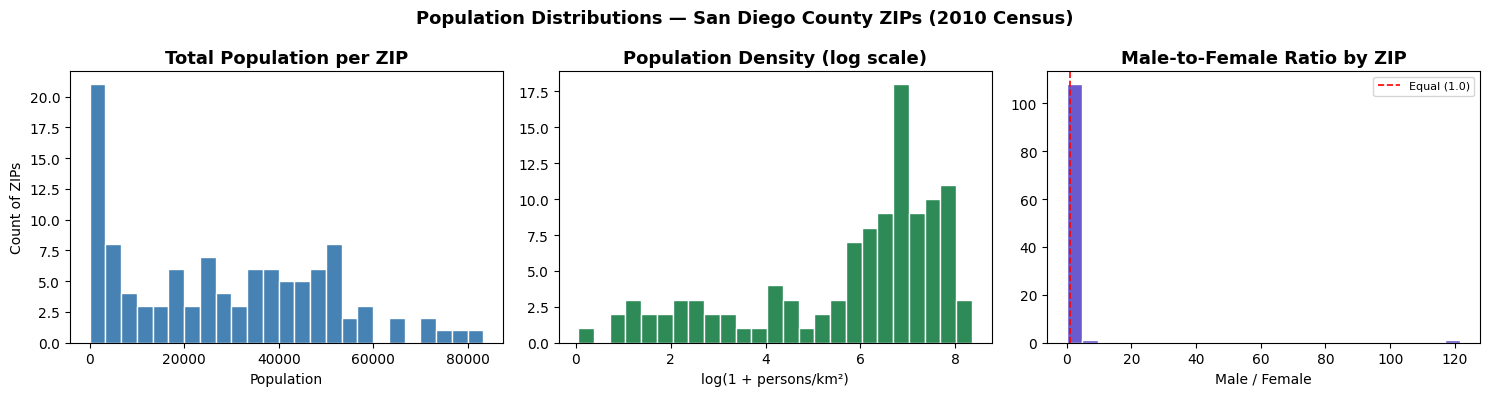

In [ ]:
# ── Distribution histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(pop_zip["pop_total"].dropna(), bins=25,
             color="steelblue", edgecolor="white")
axes[0].set_title("Total Population per ZIP")
axes[0].set_xlabel("Population")
axes[0].set_ylabel("Count of ZIPs")

axes[1].hist(np.log1p(pop_zip["pop_density_per_km2"].dropna()), bins=25,
             color="seagreen", edgecolor="white")
axes[1].set_title("Population Density (log scale)")
axes[1].set_xlabel("log(1 + persons/km²)")

axes[2].hist(pop_zip["sex_ratio"].dropna(), bins=25,
             color="slateblue", edgecolor="white")
axes[2].axvline(1.0, color="red", linestyle="--", linewidth=1.2, label="Equal (1.0)")
axes[2].set_title("Male-to-Female Ratio by ZIP")
axes[2].set_xlabel("Male / Female")
axes[2].legend(fontsize=8)

plt.suptitle("Population Distributions — San Diego County ZIPs (2010 Census)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

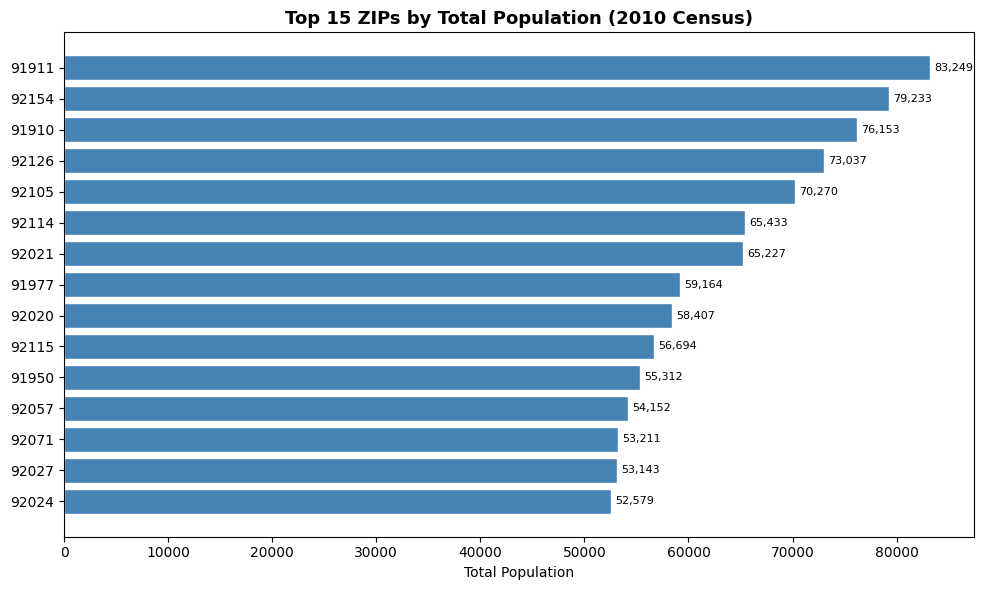

In [ ]:
# ── Top 15 ZIPs by total population ──────────────────────────────────────────
top15 = pop_zip.sort_values("pop_total", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top15["zip"], top15["pop_total"],
               color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=8)
ax.set_xlabel("Total Population")
ax.set_title("Top 15 ZIPs by Total Population (2010 Census)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

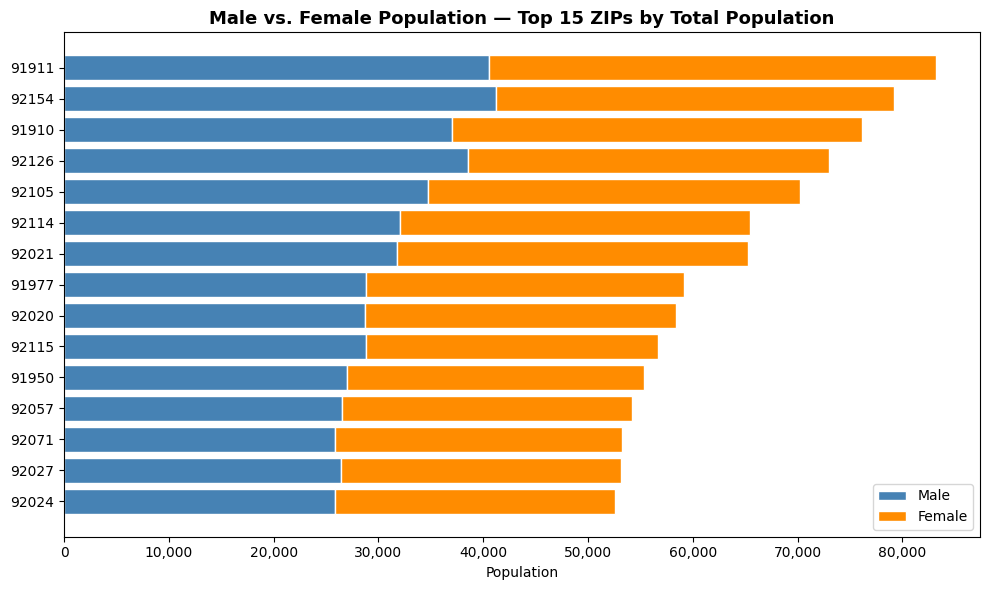

In [ ]:
# ── Stacked male/female bar — top 15 ZIPs ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top15["zip"], top15["pop_male"],
        color="steelblue", edgecolor="white", label="Male")
ax.barh(top15["zip"], top15["pop_female"],
        left=top15["pop_male"],
        color="darkorange", edgecolor="white", label="Female")

ax.set_xlabel("Population")
ax.set_title("Male vs. Female Population — Top 15 ZIPs by Total Population")
ax.invert_yaxis()
ax.legend()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{int(x):,}")
)
plt.tight_layout()
plt.show()

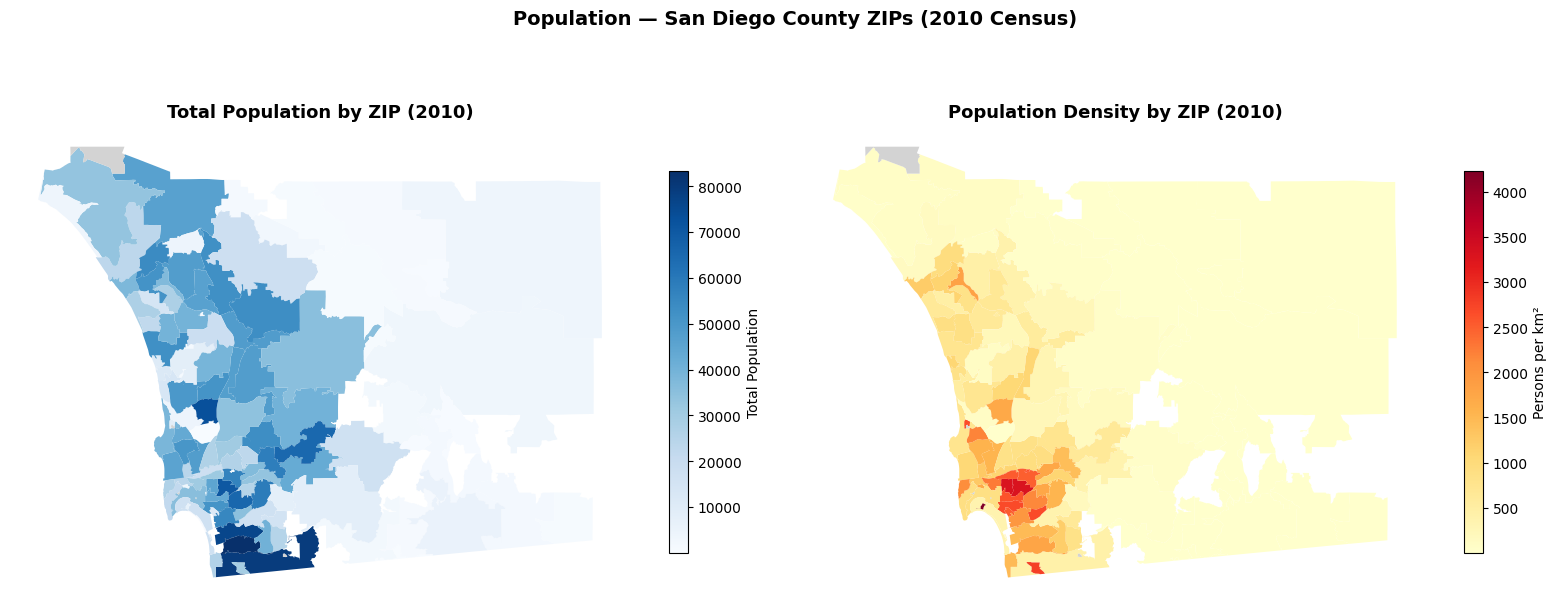

In [ ]:
# ── Choropleth maps: total population + density ───────────────────────────────
pop_zip_gdf = sd_zcta_named_gdf.merge(pop_zip, on="zip", how="left")

pop_zip_gdf.to_file("data/pop_zip_gdf.geojson", driver="GeoJSON")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

pop_zip_gdf.to_crs("EPSG:3857").plot(
    ax=axes[0], column="pop_total", cmap="Blues", legend=True,
    legend_kwds={"label": "Total Population", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
axes[0].set_title("Total Population by ZIP (2010)")
axes[0].set_axis_off()

pop_zip_gdf.to_crs("EPSG:3857").plot(
    ax=axes[1], column="pop_density_per_km2", cmap="YlOrRd", legend=True,
    legend_kwds={"label": "Persons per km²", "shrink": 0.6},
    missing_kwds={"color": "lightgrey", "label": "No data"}
)
axes[1].set_title("Population Density by ZIP (2010)")
axes[1].set_axis_off()

plt.suptitle("Population — San Diego County ZIPs (2010 Census)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ── Save output ───────────────────────────────────────────────────────────────
pop_zip.to_csv("pop_zip_sandiego.csv", index=False)

print("Saved: pop_zip_sandiego.csv")
print(f"Shape: {pop_zip.shape}")
print(f"Columns: {pop_zip.columns.tolist()}")

Saved: pop_zip_sandiego.csv
Shape: (110, 7)
Columns: ['zip', 'pop_female', 'pop_male', 'pop_total', 'sex_ratio', 'zip_area_km2', 'pop_density_per_km2']


#### 5.2.7 Dataset Takeaways

- **ZIP-level data joins cleanly.** The SANDAG dataset is already structured at the ZIP
  level, matching `sd_zcta_gdf` directly with no spatial crosswalk needed.

- **Population is unevenly distributed.** A small number of ZIPs account for a
  disproportionate share of the county's total population. The most populous ZIPs tend
  to be urban/inland (Chula Vista, El Cajon, East San Diego) rather than coastal.

- **Density varies dramatically.** Downtown and mid-city ZIPs show very high
  `pop_density_per_km2`, while rural/eastern ZIPs are extremely sparse. This variable
  will serve as a key normalizer and control in Section 6 and 9.

- **Sex ratio is close to 1.0 in most ZIPs.** Outliers likely reflect institutional
  populations (military bases, universities, correctional facilities) — these are real
  population features and are retained, not removed.

- **Key variable for downstream use:** `pop_total` is the primary denominator used
  in Section 6 to normalize permit counts, STRO license counts, and burden counts
  into per-capita rates for the mismatch index.

## 6. Unified Neighborhood Dataset

Now that we have our datasets and selected features, we can combine the datasets to make one unified neighborhood dataset.

In [ ]:
## creating the unified dataset
unified_nbhd_df = permit_zip_slim.copy()

# Left join rent burden features (93 zips → should cover most of permit's 84)
unified_nbhd_df = unified_nbhd_df.merge(rent_burden_zip_features, on="zip", how="left")

# Left join STRO features (only 33 zips — left join preserves all 84, fills NaN elsewhere)
unified_nbhd_df = unified_nbhd_df.merge(stro_zip_slim, on="zip", how="left")

print(f"Final shape: {unified_nbhd_df.shape}")
print(f"\nNull counts:\n{unified_nbhd_df.isnull().sum()}")
unified_nbhd_df.head()

Final shape: (65, 10)

Null counts:
zip                            0
avg_days_to_issue              0
log_permit_total_count         0
log_permit_total_valuation     0
low_activity_zip               0
cost_burdened_share            2
median_rent_pct_income         2
median_rel_moe                 2
stro_pct_high_intensity       32
log_stro_total_licenses       32
dtype: int64


,zip,avg_days_to_issue,log_permit_total_count,log_permit_total_valuation,low_activity_zip,cost_burdened_share,median_rent_pct_income,median_rel_moe,stro_pct_high_intensity,log_stro_total_licenses
0,91901,1.000000,1.098612,0.0,0,0.507808,32.8,19.207317,NaN,NaN
1,91910,4.000000,0.693147,0.0,1,0.575871,34.8,6.609195,NaN,NaN
2,91911,7.200000,2.197225,0.0,0,0.624467,37.1,5.660377,NaN,NaN
3,91913,4.000000,1.609438,0.0,0,0.610844,34.6,12.716763,NaN,NaN
4,91932,3.142857,2.197225,0.0,0,0.572364,33.8,5.029586,NaN,NaN


In [ ]:
unified_nbhd_df["has_stro"] = unified_nbhd_df["log_stro_total_licenses"].notna().astype(int)
unified_nbhd_df[["stro_pct_high_intensity", "log_stro_total_licenses"]] = \
    unified_nbhd_df[["stro_pct_high_intensity", "log_stro_total_licenses"]].fillna(0)

unified_nbhd_df.head()

,zip,avg_days_to_issue,log_permit_total_count,log_permit_total_valuation,low_activity_zip,cost_burdened_share,median_rent_pct_income,median_rel_moe,stro_pct_high_intensity,log_stro_total_licenses,has_stro
0,91901,1.000000,1.098612,0.0,0,0.507808,32.8,19.207317,0.0,0.0,0
1,91910,4.000000,0.693147,0.0,1,0.575871,34.8,6.609195,0.0,0.0,0
2,91911,7.200000,2.197225,0.0,0,0.624467,37.1,5.660377,0.0,0.0,0
3,91913,4.000000,1.609438,0.0,0,0.610844,34.6,12.716763,0.0,0.0,0
4,91932,3.142857,2.197225,0.0,0,0.572364,33.8,5.029586,0.0,0.0,0


In [ ]:
# check nulls to see if need missing imputation
unified_nbhd_df.isnull().sum()

,0
zip,0
avg_days_to_issue,0
log_permit_total_count,0
log_permit_total_valuation,0
low_activity_zip,0
cost_burdened_share,2
median_rent_pct_income,2
median_rel_moe,2
stro_pct_high_intensity,0
log_stro_total_licenses,0


Take note that rent burden columns have quite a bit of nulls, let's see how we can fix these nulls.

In [ ]:
# Which zips are missing rent burden data?
missing_rent = unified_nbhd_df[unified_nbhd_df["cost_burdened_share"].isnull()]["zip"].tolist()
print(f"{len(missing_rent)} zips missing rent burden data:")
print(missing_rent)

# Are they the low-activity zips?
print("\nLow activity breakdown:")
print(unified_nbhd_df[unified_nbhd_df["zip"].isin(missing_rent)]["low_activity_zip"].value_counts())

2 zips missing rent burden data:
['92093', '92132']

Low activity breakdown:
low_activity_zip
0    1
1    1
Name: count, dtype: int64


These zip codes are the UCSD zipcode and the naval base, which do not show up in the census. We shall impute them with the median.

In [ ]:
unified_nbhd_df["rent_data_missing"] = unified_nbhd_df["cost_burdened_share"].isnull().astype(int)

for col in ["cost_burdened_share", "median_rent_pct_income", "median_rel_moe"]:
    unified_nbhd_df[col] = unified_nbhd_df[col].fillna(unified_nbhd_df[col].median())

unified_nbhd_df.head()

,zip,avg_days_to_issue,log_permit_total_count,log_permit_total_valuation,low_activity_zip,cost_burdened_share,median_rent_pct_income,median_rel_moe,stro_pct_high_intensity,log_stro_total_licenses,has_stro,rent_data_missing
0,91901,1.000000,1.098612,0.0,0,0.507808,32.8,19.207317,0.0,0.0,0,0
1,91910,4.000000,0.693147,0.0,1,0.575871,34.8,6.609195,0.0,0.0,0,0
2,91911,7.200000,2.197225,0.0,0,0.624467,37.1,5.660377,0.0,0.0,0,0
3,91913,4.000000,1.609438,0.0,0,0.610844,34.6,12.716763,0.0,0.0,0,0
4,91932,3.142857,2.197225,0.0,0,0.572364,33.8,5.029586,0.0,0.0,0,0


## 7. Feature Engineering

Now that we have merged our features, we must take a look at how they interact with each other.

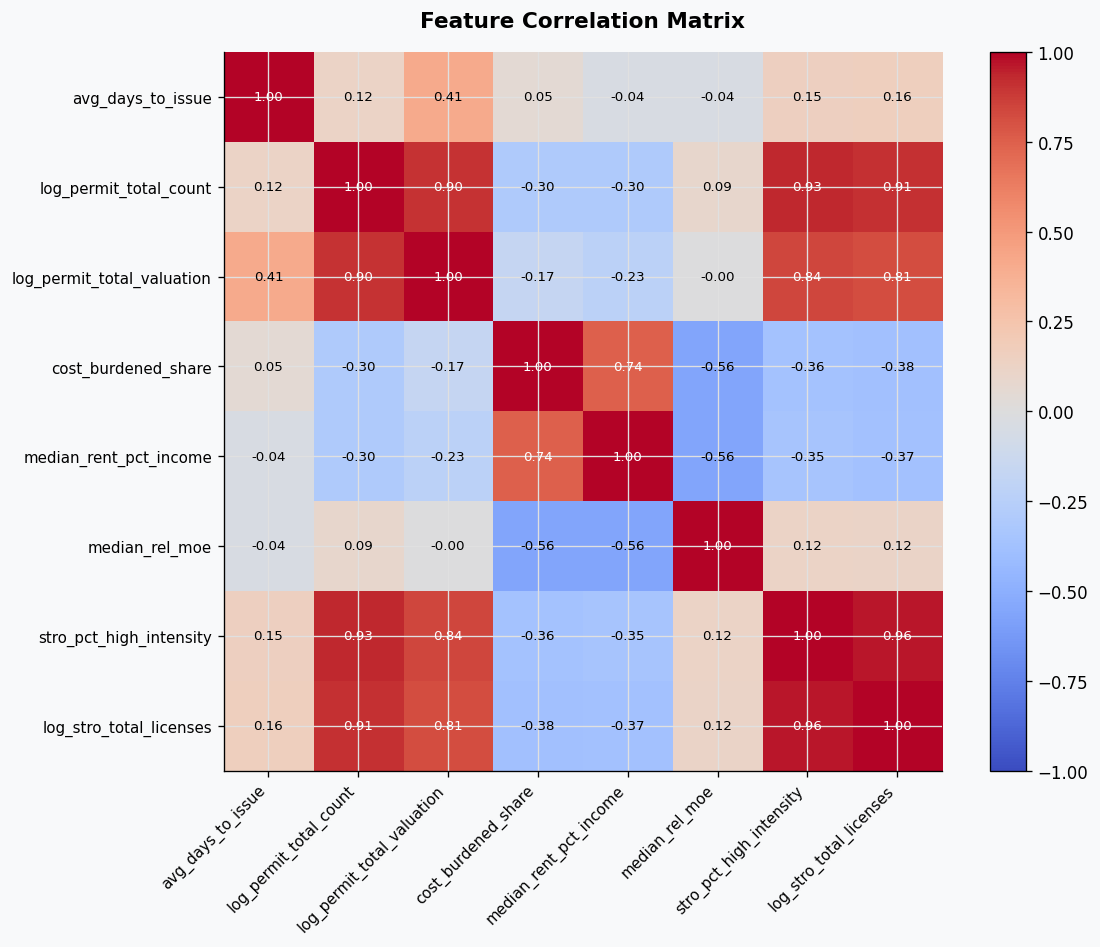

In [ ]:
corr_cols = [
    "avg_days_to_issue",
    "log_permit_total_count",
    "log_permit_total_valuation",
    "cost_burdened_share",
    "median_rent_pct_income",
    "median_rel_moe",
    "stro_pct_high_intensity",
    "log_stro_total_licenses",
]

corr_matrix = unified_nbhd_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Axis labels
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)

# Annotate each cell
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=color)

plt.colorbar(im, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

As we can see, there are quite a few with high correlation, it implies multicollinearity. To solve  this issue, we shall drop some of the features that may seem irrelevant.

Prior to index construction, we examined pairwise correlations among candidate features to identify redundancy. Two features were dropped due to multicollinearity: log_stro_total_licenses (r=0.961 with stro_pct_high_intensity) and log_permit_total_valuation (r=0.900 with log_permit_total_count). We also noted that stro_pct_high_intensity and log_permit_total_count were themselves moderately correlated (r=0.934), suggesting both partly reflect underlying neighborhood activity levels rather than fully independent signals. median_rel_moe was additionally removed as its negative correlation with burden measures appeared to reflect small-sample statistical noise rather than a substantive relationship. The five features retained for index construction were cost_burdened_share and median_rent_pct_income as need-side indicators, log_permit_total_count as a supply relief signal, avg_days_to_issue as a pipeline bottleneck measure, and stro_pct_high_intensity as a proxy for housing stock diversion into short-term rental use.

Adjusting The Dataset Based on Correlation Analysis

In [ ]:
unified_nbhd_df = unified_nbhd_df.drop(columns=[
    "log_stro_total_licenses",
    "log_permit_total_valuation",
    "median_rel_moe",
])

print(f"Remaining columns: {unified_nbhd_df.columns.tolist()}")
print(f"Shape: {unified_nbhd_df.shape}")

Remaining columns: ['zip', 'avg_days_to_issue', 'log_permit_total_count', 'low_activity_zip', 'cost_burdened_share', 'median_rent_pct_income', 'stro_pct_high_intensity', 'has_stro', 'rent_data_missing']
Shape: (65, 9)


In [ ]:
# fixing stro log transform (-1) outliers
# log transform STRO share to reduce skew / zero clustering
unified_nbhd_df["stro_log"] = np.log1p(unified_nbhd_df["stro_pct_high_intensity"])

Analyzing Features for Affordability Pressures

In [ ]:
# Affordability Pressure Index

pressure_cols = [
    c for c in unified_nbhd_df.columns
    if ("burden" in c) or ("rent_pct" in c)
]

for col in pressure_cols:
    unified_nbhd_df[f"{col}_z"] = (
        unified_nbhd_df[col] - unified_nbhd_df[col].mean()
    ) / unified_nbhd_df[col].std()

z_cols = [f"{c}_z" for c in pressure_cols]

unified_nbhd_df["affordability_pressure_index"] = unified_nbhd_df[z_cols].mean(axis=1)

unified_nbhd_df[["zip", "affordability_pressure_index"]].head()



,zip,affordability_pressure_index
0,91901,-0.465936
1,91910,0.190985
2,91911,0.774296
3,91913,0.367649
4,91932,0.039595


Interpretation of Affordability Pressure Index -->
Higher value = stronger rent stress

Affordable Supply

In [ ]:
# Affordable Supply Index

affordable_cols = [
    c for c in unified_nbhd_df.columns
    if ("affordable" in c and "log" in c)
]

for col in affordable_cols:
    unified_nbhd_df[f"{col}_z"] = (
        unified_nbhd_df[col] - unified_nbhd_df[col].mean()
    ) / unified_nbhd_df[col].std()

z_cols = [f"{c}_z" for c in affordable_cols]

unified_nbhd_df["affordable_supply_index"] = unified_nbhd_df[z_cols].sum(axis=1)

unified_nbhd_df[["zip","affordable_supply_index"]].head()


,zip,affordable_supply_index
0,91901,0.0
1,91910,0.0
2,91911,0.0
3,91913,0.0
4,91932,0.0


Interpretation of Affordable Supply Index --> higher value = more affordability- supporting housing supply

Future Supply: Can Relieve Pressure Later

In [ ]:
# Future Housing Supply

future_cols = [
    c for c in unified_nbhd_df.columns
    if ("pipeline" in c) or ("permit" in c) or ("adu" in c)
]

for col in future_cols:
    unified_nbhd_df[f"{col}_z"] = (
        unified_nbhd_df[col] - unified_nbhd_df[col].mean()
    ) / unified_nbhd_df[col].std()

z_cols = [f"{c}_z" for c in future_cols]

unified_nbhd_df["future_supply_index"] = unified_nbhd_df[z_cols].sum(axis=1)

unified_nbhd_df[["zip","future_supply_index"]].head()

,zip,future_supply_index
0,91901,-2.250263
1,91910,-2.471796
2,91911,-1.650019
3,91913,-1.971166
4,91932,-1.650019


Interpretation of Future Housing Supply --> Higher value = more housing incoming

Diversion / Competing Supply: Housing being removed from long-term market.

In [ ]:
# Diversion / Competing Supply
# Housing Diversion Index

col = "stro_log"

unified_nbhd_df["diversion_index"] = (
    unified_nbhd_df[col] - unified_nbhd_df[col].mean()
) / unified_nbhd_df[col].std()

Interpretation of Housing Diversion Index --> higher value = more housing diverted to short-term rentals.

Affordability Mismatch Index

Mismatch = Demand pressure
           - Affordable supply
           - Future supply
           + Diversion

In [ ]:
# Affordability Mismatch Index

unified_nbhd_df["affordability_mismatch_index"] = (
      unified_nbhd_df["affordability_pressure_index"]
    - unified_nbhd_df["affordable_supply_index"]
    - unified_nbhd_df["future_supply_index"]
    + unified_nbhd_df["diversion_index"]
)

unified_nbhd_df[[
    "zip",
    "affordability_pressure_index",
    "affordable_supply_index",
    "future_supply_index",
    "diversion_index",
    "affordability_mismatch_index"
]].head()

,zip,affordability_pressure_index,affordable_supply_index,future_supply_index,diversion_index,affordability_mismatch_index
0,91901,-0.465936,0.0,-2.250263,-0.974084,0.810243
1,91910,0.190985,0.0,-2.471796,-0.974084,1.688697
2,91911,0.774296,0.0,-1.650019,-0.974084,1.450231
3,91913,0.367649,0.0,-1.971166,-0.974084,1.364731
4,91932,0.039595,0.0,-1.650019,-0.974084,0.715531


Let's Get a Visual of all these Indexes

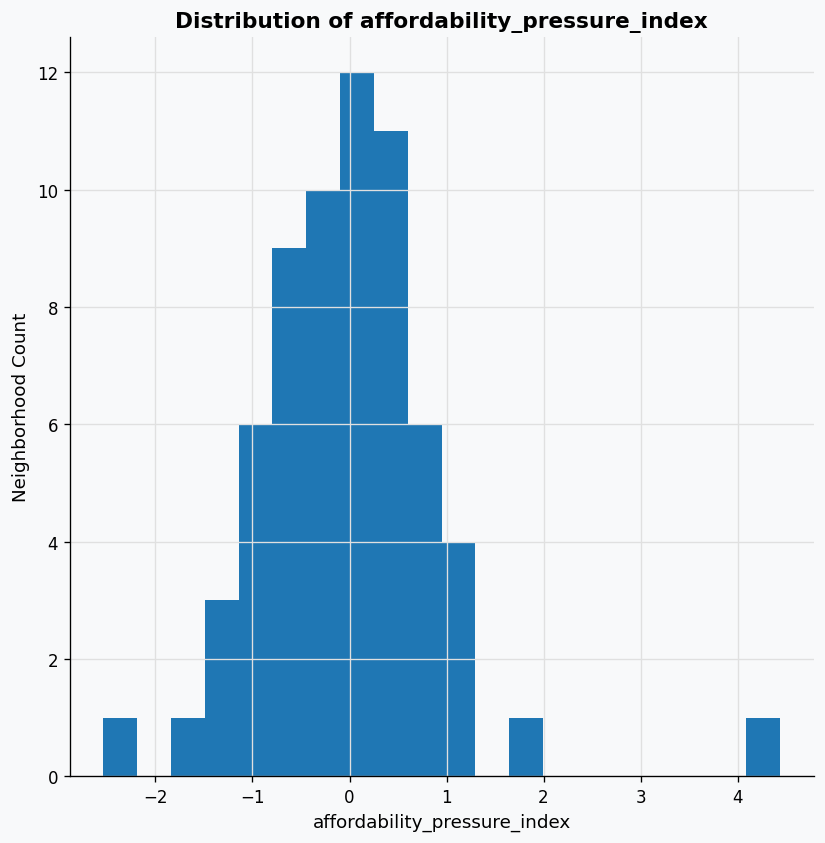

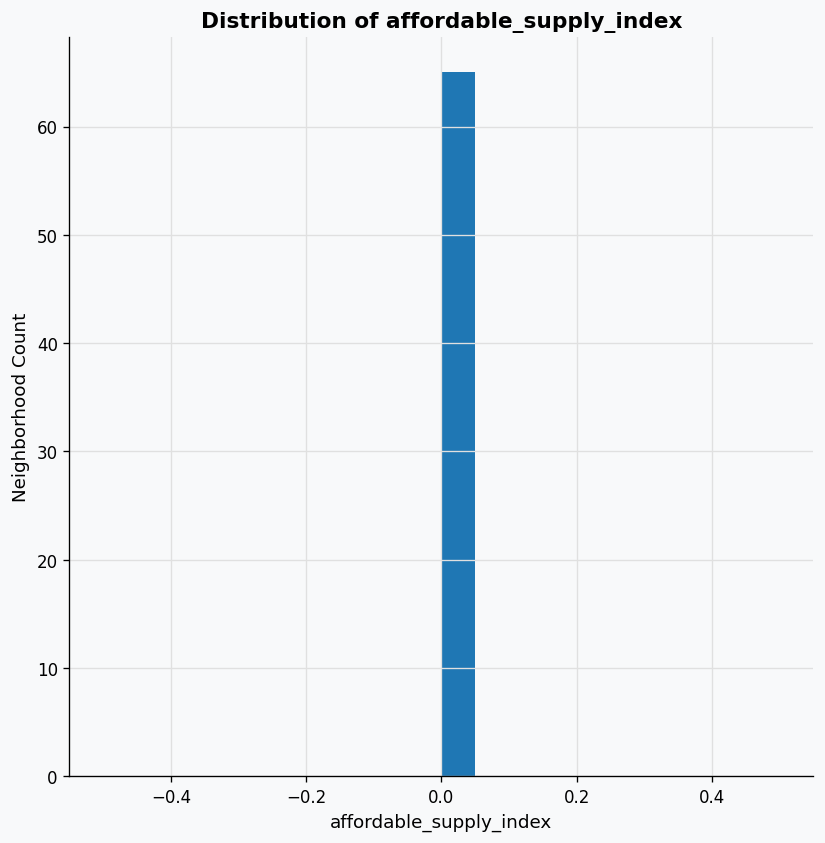

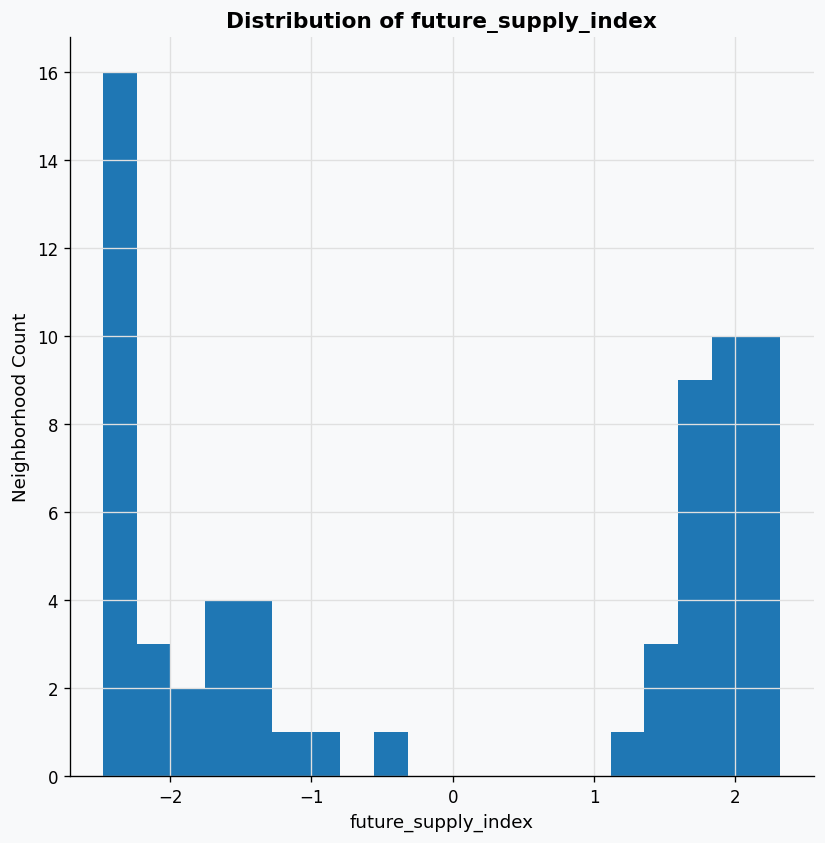

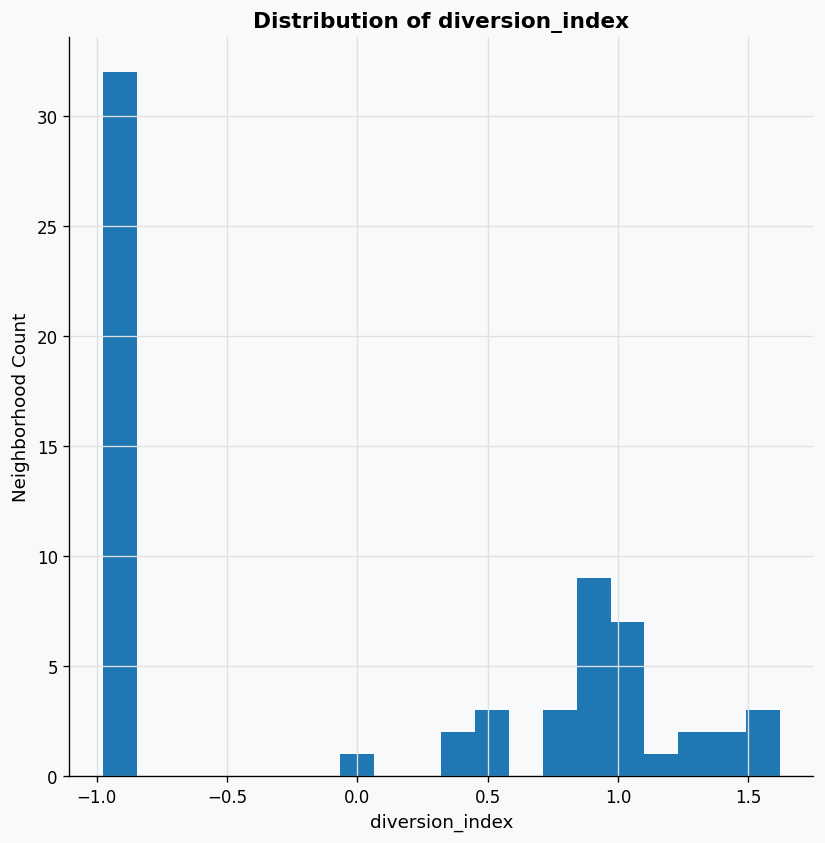

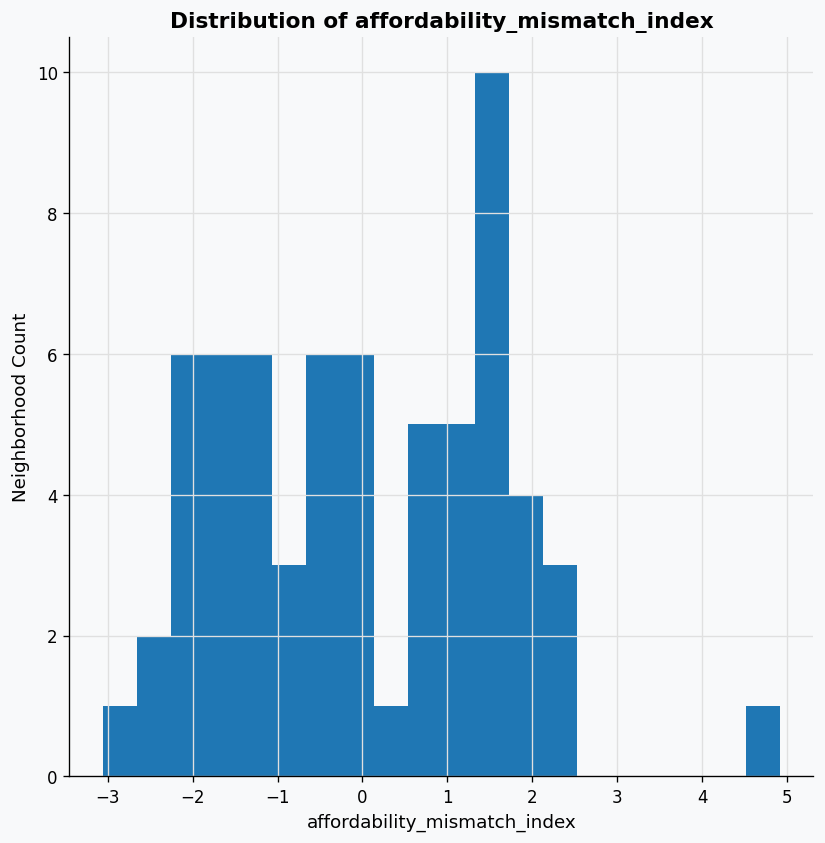

In [ ]:
index_cols = [
    "affordability_pressure_index",
    "affordable_supply_index",
    "future_supply_index",
    "diversion_index",
    "affordability_mismatch_index"
]

for col in index_cols:
    plt.figure()
    unified_nbhd_df[col].hist(bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Neighborhood Count")
    plt.show()

## 8. Exploratory Spatial Analysis

In [ ]:
# Ranking/mismatch hotspots

In [ ]:
# testing choropleth maps
map_df = sd_zcta_gdf.merge(unified_nbhd_df, on="zip", how="left")

map_df.to_crs("EPSG:3857").plot(
    column="cost_burdened_share",
    cmap="Reds",
    legend=True,
    figsize=(8,8),
    edgecolor="black",
    linewidth=0.2
)

NameError: name 'sd_zcta_gdf' is not defined

## 9. Modeling

#### Affordability Burden Explained

The **Affordability Pressure Index** measures the level of rent stress in each neighborhood. Higher values indicate that households are spending a larger share of their income on rent, reflecting stronger financial pressure from housing costs.

By examining this index, we can identify neighborhoods that are most vulnerable to rent burden, as well as those where rental costs are relatively manageable. Mapping or visualizing this index helps highlight geographic patterns, showing areas where affordability challenges are concentrated across the region.


In [ ]:
# Affordability Burden Explained

#### Affordability Mismatch Score Explained

The **Affordability Mismatch Index** captures the gap between housing demand pressures and the available or incoming affordable supply, while also accounting for housing being diverted to short-term rentals.

Higher values indicate neighborhoods where demand for affordable housing outpaces the supply, signaling areas of potential housing stress. This index helps pinpoint locations where interventions, like increasing affordable units or regulating short-term rentals, could be most needed to improve housing accessibility.

In [ ]:
# Explain Affordability Mismatch Score

####  The Model

Now that we have created different indexes that are representative of our datasets from supply and demand, we can create a model that uses these indexes to explain variations in affordability pressure across neighborhoods. This allows us to quantify how factors like existing affordable supply, incoming housing, and housing diverted to short-term rentals contribute to overall rent stress.

In [ ]:
# creating the model based on the indexes
y = unified_nbhd_df["affordability_pressure_index"]

X = unified_nbhd_df[
[
    "affordable_supply_index",
    "future_supply_index",
    "diversion_index",
    "avg_days_to_issue"
]
]

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                                 OLS Regression Results                                 
Dep. Variable:     affordability_pressure_index   R-squared:                       0.162
Model:                                      OLS   Adj. R-squared:                  0.121
Method:                           Least Squares   F-statistic:                     3.923
Date:                          Sun, 15 Mar 2026   Prob (F-statistic):             0.0126
Time:                                  21:00:38   Log-Likelihood:                -81.552
No. Observations:                            65   AIC:                             171.1
Df Residuals:                                61   BIC:                             179.8
Df Model:                                     3                                         
Covariance Type:                      nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
------------------

## 10. Results and Interpretations

Now that we have run our model and gots results, let's see what that means in relation to answering our main research focus.

#### Where is Need Highest?
These are neighborhoods with the highest affordability pressure.

In [ ]:
# Where is need highest?
top_pressure = unified_nbhd_df.nlargest(5, "affordability_pressure_index")[["zip", "affordability_pressure_index"]]

print("Top 5 Neighborhoods by Affordability Pressure:")
print(top_pressure.to_string(index=False))


Top 5 Neighborhoods by Affordability Pressure:
  zip  affordability_pressure_index
92091                      4.434878
92067                      1.907579
92020                      1.262619
92071                      1.134926
92025                      1.002986


#### Where is Supply the Weakest and Strongest?
These are neighborhoods with low and high affordable supply index.

In [ ]:
# Where is supply weakest/strongest?
weakest_supply = unified_nbhd_df.nsmallest(5, "affordable_supply_index")[["zip", "affordable_supply_index"]]
strongest_supply = unified_nbhd_df.nlargest(5, "affordable_supply_index")[["zip", "affordable_supply_index"]]

print("\nTop 5 Weakest Supply Neighborhoods:")
print(weakest_supply.to_string(index=False))

print("\nTop 5 Strongest Supply Neighborhoods:")
print(strongest_supply.to_string(index=False))


Top 5 Weakest Supply Neighborhoods:
  zip  affordable_supply_index
91901                      0.0
91910                      0.0
91911                      0.0
91913                      0.0
91932                      0.0

Top 5 Strongest Supply Neighborhoods:
  zip  affordable_supply_index
91901                      0.0
91910                      0.0
91911                      0.0
91913                      0.0
91932                      0.0


#### Where is the Affordability Mismatch Most Severe?
These are neighborhoods with the highest affordability mismatch index score.

In [ ]:
# Where is mismatch most severe?
most_severe_mismatch = unified_nbhd_df.nlargest(5, "affordability_mismatch_index")[["zip", "affordability_mismatch_index"]]

print("\nTop 5 Most Severe Mismatch Neighborhoods:")
print(most_severe_mismatch.to_string(index=False))



Top 5 Most Severe Mismatch Neighborhoods:
  zip  affordability_mismatch_index
92091                      4.909901
92025                      2.279165
92029                      2.202969
92020                      2.160087
92118                      2.000494


#### How does Diversion Impact Housing?

The Diversion Index measures the extent to which housing is being removed from the long-term rental market, for example due to short-term rentals or other competing uses.

A higher Diversion Index indicates that a larger share of housing is diverted away from traditional rental availability. This can exacerbate affordability pressures even in neighborhoods that otherwise have sufficient supply, because fewer units are available for long-term residents.

By comparing the Diversion Index alongside the Affordable Supply Index and the Affordability Pressure Index, we can identify areas where housing stress may be higher than expected due to diversion, highlighting neighborhoods where interventions to preserve long-term housing may be especially critical.

In [ ]:
# Top 10 ZIPs by Diversion Index
top_diversion = unified_nbhd_df.nlargest(10, "diversion_index")[["zip", "diversion_index"]]

print("Top 10 Neighborhoods with Highest Housing Diversion:")
print(top_diversion.to_string(index=False))


Top 10 Neighborhoods with Highest Housing Diversion:
  zip  diversion_index
92109         1.620256
92107         1.540586
92101         1.537942
92037         1.472792
92113         1.362847
92102         1.305356
92103         1.252951
92120         1.124021
92110         1.086795
92173         1.071132


#### Interpretation

